# Imports and Loading of DataSet

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Regression/feature selection
from sklearn.linear_model import LinearRegression, LassoCV, LogisticRegressionCV
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.feature_selection import SelectFromModel

# Discriminant analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set(style="whitegrid", context="notebook")

In [2]:
# load dataset
data = pd.read_csv('group_23.csv')

# Analysis of Data -  Exploratory Data Analysis (EDA)

Inicialmente, vemos os dados no geral. Verificamos a existência de 49 features e 3000 entradas de dados. Nenhuma feature tem um datatype inválido. Data types inválidos incluem espaços vazios, ou um valor NaN (not a number), que indica a falta de informação nessa entrada. Porém, o focus_factor aparece na tabela com valores numéricos e está identificado como object, o que indica que pode ter algum caracter inválido, o que é um problema a resolver.

In [3]:
# overview da estrutura básica

print(f"Shape: {data.shape}")
print(f"Número de samples: {data.shape[0]}")
print(f"Número de features: {data.shape[1]}")

Shape: (3000, 49)
Número de samples: 3000
Número de features: 49


In [4]:
# verificar nomes e data types -- não há datatypes inválidos
print(data.dtypes)

duration_1                       float64
duration_2                       float64
duration_3                       float64
duration_4                       float64
duration_5                       float64
loudness_level                   float64
popularity_level                 float64
tempo_class                      float64
time_signature                   float64
key_mode                         float64
artist_song_count                float64
album_freq                       float64
movement_index                   float64
intensity_level                  float64
verbal_density                   float64
purity_score                     float64
positivity_index                 float64
activity_rate                    float64
loudness_intensity               float64
happy_dance                      float64
acoustics_instrumental           float64
artists_avg_popularity           float64
tempo_vs_genre                   float64
energy_rank_pct                  float64
loud_energy_rati

In [5]:
# ver os dados

data.head()

,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,...,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_class,target_regression
0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.0,0.221824,0.485996,...,0.0,0.0,0.097514,-2.438714,0.774256,1,-0.039187,0.789,class_69,-1.131539
1,0.0,0.0,1.0,0.0,0.0,3.0,1.0,1.0,0.221824,0.739248,...,0.0,0.0,-0.939303,-0.615927,0.118441,1,-1.612293,0.860,class_69,-1.490205
2,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.0,0.221824,0.485996,...,0.0,0.0,-1.071032,-1.345330,0.449030,1,0.243165,0.855,class_69,-1.266039
3,0.0,0.0,1.0,0.0,0.0,3.0,1.0,1.0,0.221824,0.176466,...,0.0,0.0,1.395353,0.337410,0.308189,1,0.485181,0.905,class_69,-1.176373
4,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.0,0.221824,0.485996,...,0.0,0.0,-1.071032,0.961367,0.870235,1,0.335362,0.855,class_69,-1.400539


In [6]:
# ver as possibilidades de target_class

data['target_class'].unique()

array(['class_69', 'class_97', 'class_102'], dtype=object)

In [7]:
# Set pandas to display ALL columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(data.sample(15))

      duration_1  duration_2  duration_3  duration_4  duration_5  \
1801         0.0         1.0         0.0         0.0         0.0   
1190         0.0         1.0         0.0         0.0         0.0   
1817         1.0         0.0         0.0         0.0         0.0   
251          0.0         0.0         1.0         0.0         0.0   
2505         0.0         1.0         0.0         0.0         0.0   
1117         0.0         1.0         0.0         0.0         0.0   
1411         0.0         0.0         1.0         0.0         0.0   
2113         0.0         0.0         1.0         0.0         0.0   
408          0.0         0.0         0.0         1.0         0.0   
2579         0.0         0.0         1.0         0.0         0.0   
2254         0.0         0.0         0.0         1.0         0.0   
52           0.0         0.0         0.0         1.0         0.0   
644          0.0         0.0         0.0         1.0         0.0   
1763         0.0         1.0         0.0        

Verificamos que as features categóricas são:

- duration_1 ... duration_5: Different measurements or transformations of the item’s dura
tion;
-  loudness_level: A classification of the track’s overall loudness;
-  popularity_level: Discretized level of popularity;
- tempo_class: A classification of the song’s tempo (beats per minute);
-   explicit: Binary flag indicating explicit language;
-   mode_indicator: Binary indicator of mode (major/minor type);
-   time_signature_class_boolean: Simplified binary version of time signature;
-    is_instrumental: Binary indicator of instrumental items;
-     is_dance_hit: Binary indicator of dance-oriented items;
-  echo_constant: Measure of the presence and intensity of echo;
-   target_class: Categorical class label (class_1, class_2, ..., Class_N);

sendo as restantes numéricas.

## Preparação do Dataset

Primeiro, identificamos as classes target, ou seja, o que queremos prever.

In [8]:
# Targets per assignment
TARGET_CLASS = "target_class"
TARGET_REG = "target_regression"

# Basic checks
assert TARGET_CLASS in data.columns and TARGET_REG in data.columns, "Target columns not found in dataset"

In [9]:
features = [col for col in data.columns if col not in [TARGET_CLASS, TARGET_REG]]

# Identify numeric feature columns only (exclude targets)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_reg = [c for c in numeric_cols if c != TARGET_REG]  # keep numeric predictors for regression

# For classification we will also use numeric feature set; target_class is categorical already
feature_cols_cls = [c for c in numeric_cols if c not in [TARGET_REG]]

print("\nNumeric feature count (reg):", len(feature_cols_reg))
print("Numeric feature count (cls):", len(feature_cols_cls))


Numeric feature count (reg): 46
Numeric feature count (cls): 46


In [10]:
# vemos que focus factor aparece como object, mas tem valores numéricos - converter de string para numero

data['focus_factor'] = (
    data['focus_factor']
    .astype(str)
    .str.replace(',', '.')  # substituir virgulas por pontos
    .astype(float)           # converter para float
)

# verificar que está correto
print(f"New dtype: {data['focus_factor'].dtype}")

New dtype: float64


## Análise de Valores em Falta e Duplicados

Verificamos que não existem valores em falta no dataset, nem valores duplicados

In [11]:
# análise de valores em falta

missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_summary = pd.DataFrame({'Contagem de valores em falta': missing_data, 'Percentagem de valores em falta': missing_percent})

print(missing_summary[missing_summary['Contagem de valores em falta'] > 0])

Empty DataFrame
Columns: [Contagem de valores em falta, Percentagem de valores em falta]
Index: []


In [12]:
# verificar se existem linhas duplicadas -- duplicates afetam negativamente a análise ao inflacionar padrões
print(f"Número de linhas duplicadas: {data.duplicated().sum()}")

Número de linhas duplicadas: 0


## Divisão do Dataset

Criamos 3 o dataframes: um com as features categóricas e outro com features numéricas, e outro com todas as features, menos os targets, e one hot encoding em valores categoricos

In [13]:
# análise de features numericas e categoricas separadamente
categorical_features = ['duration_1', 'duration_2', 'duration_3', 'duration_4', 'duration_5', 'loudness_level', 'popularity_level', 'tempo_class', 'explicit', 'mode_indicator', 'time_signature_class_boolean', 'is_instrumental', 'is_dance_hit', 'echo_constant']

numerical_features = [col for col in data.columns if col not in categorical_features and col not in ['target_class', 'target_regression']]
numerical_cols = data[numerical_features]
categorical_cols = data[categorical_features]  # DataFrame with categorical columns

features = data.copy()
features.drop(['target_class', 'target_regression'], axis=1, inplace=True)
features = pd.get_dummies(features, columns=categorical_features, dtype=int)
features.head()

,time_signature,key_mode,artist_song_count,album_freq,movement_index,intensity_level,verbal_density,purity_score,positivity_index,activity_rate,loudness_intensity,happy_dance,acoustics_instrumental,artists_avg_popularity,tempo_vs_genre,energy_rank_pct,loud_energy_ratio,mood_pca,mood_cluster,acoustic_valence_mood_cluster,signal_strength,focus_factor,ambient_level,key_sin,key_cos,duration_log,duration_log_z,loudness_yeo,temp_zscore,resonance_factor,timbre_index,distorted_movement,signal_power,duration_1_0.0,duration_1_1.0,duration_2_0.0,duration_2_1.0,duration_3_0.0,duration_3_1.0,duration_4_0.0,duration_4_1.0,duration_5_0.0,duration_5_1.0,loudness_level_0.0,loudness_level_1.0,loudness_level_2.0,loudness_level_3.0,loudness_level_4.0,popularity_level_0.0,popularity_level_1.0,popularity_level_2.0,popularity_level_3.0,popularity_level_4.0,tempo_class_0.0,tempo_class_1.0,tempo_class_2.0,tempo_class_3.0,explicit_0.0,explicit_1.0,mode_indicator_0.0,mode_indicator_1.0,time_signature_class_boolean_0.0,time_signature_class_boolean_1.0,is_instrumental_0.0,is_instrumental_1.0,is_dance_hit_0.0,is_dance_hit_1.0,echo_constant_1
0,0.221824,0.485996,-0.431042,7.282470,1.591541,1.085223,1.535459,-0.938608,0.373888,0.097515,1.126787,0.964869,-0.306317,0.249351,0.183396,0.520973,-0.009359,0.830179,-0.775793,0.066512,0.789,0.000024,0.0322,-5.000000e-01,-0.866025,1.396298,-0.440540,1.552137,0.097514,-2.438714,0.774256,-0.039187,0.789,1,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,1,1,0,1,0,1
1,0.221824,0.739248,-0.382954,1.487703,0.980738,1.114849,-0.238833,-0.616222,0.701744,-0.939307,1.089298,0.975564,-0.306317,0.098055,-0.900578,0.906692,-0.009396,1.062305,-1.109797,0.066512,0.860,0.000002,0.0574,-8.660254e-01,-0.500000,1.439938,-0.289911,1.630066,-0.939303,-0.615927,0.118441,-1.612293,0.860,1,0,1,0,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,1,0,1
2,0.221824,0.485996,1.203955,3.959000,1.412910,0.901501,-0.276664,-0.709750,0.381602,-1.071036,0.609583,0.883728,-0.306250,-1.411880,-1.038298,0.874223,-0.009404,0.925894,-1.109797,0.066512,0.855,0.000167,0.1080,-5.000000e-01,-0.866025,1.436976,-0.300135,1.124743,-1.071032,-1.345330,0.449030,0.243165,0.855,1,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,1,1,0,1,0,1
3,0.221824,0.176466,-0.527218,1.530311,1.176656,0.992368,0.665337,-0.616222,1.480885,1.395359,0.730225,1.874170,-0.306313,-1.374172,1.540265,1.165909,-0.009423,1.695991,0.894228,0.725614,0.905,0.000007,0.6560,1.224647e-16,-1.000000,1.610324,0.298206,1.325239,1.395353,0.337410,0.308189,0.485181,0.905,1,0,1,0,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,1,0,1
4,0.221824,0.485996,1.203955,3.106829,1.412910,0.901501,-0.276664,-0.709750,0.381602,-1.071036,0.609583,0.883728,-0.306250,-1.411880,-1.038298,0.874223,-0.009404,0.925894,-1.109797,0.066512,0.855,0.000167,0.1080,-5.000000e-01,-0.866025,1.436976,-0.300135,1.124743,-1.071032,0.961367,0.870235,0.335362,0.855,1,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,1,1,0,1,0,1


# Sumário das features numéricas

Obtemos os valores da média, desvio padrão, valor mínimo, valor máximo e quartis para todas as features numéricas. Isto permite-nos ter uma ideia dos ajustes que temos de fazer.

- time_signature: os percentis têm a mesma distribuição. os valores mínimo e máximo são bastante distantes um do outro. isto indica que devem haver alguns, ainda que poucos, outliers.
- key_mode: a média está próxima de zero e o desvio padrão próximo de 1. É uma variável que já está standardized.
- artist_song_count: a média inferior à mediana e o máximo muito superior a Q3 indica uma right skewness; a maioria dos valores são baixos, com alguns muito altos.
- album_freq: o valor máximo é muito maior do que o mínimo, indicando outliers. a média muito superior à mediana indica um right skew.
- movement_index: variabilidade moderada. a maioria dos valores são positivos.
- intensity_level: a maioria dos valores são positivos, com Q1 = 0.173 A Q3 = 0.792. o valor mínimo está muito abaixo do Q1, podendo indicar um low outlier.
- verbal_density: a maioria dos valores são negativos, com Q1 a Q3 negativos. O valor máximo está muito acima de Q3, indicando um high outlier.
- purity_score: ligeiramente left skewed
- positivity_index: a maioria dos valores são positivos, com Q1 = 0.427. A mediana superior à média indica um left sew
- activity_rate: Alta variabilidade (std=1.08), a média e a mediana variam
- loudness_intensity: a maioria dos valores rondam o zero mas temos um outlier muito baixo (min=-3.796)
- happy_dance: q1 positivo, maioria dos valores são positivos, média e mediana aproximadamente iguais
- acoustics_instrumental: Q1,12 e Q3 quase constante com um outlier extremo(max=4.298)
- artists_avg_popularity: a maioria dos valores são negativos (Q1=-1.214, Q3=0.124); right-skewed (max muito acima de q3), alguns high outliers
- tempo_vs_genre: Média próxima de 0, desvio padrão > 1; valores dispersos em torno de zero
- energy_rank_pct: Os valores variam de negativos a positivos; variabilidade moderada
- loud_energy_ratio: Quase constante (Q1=Q2=Q3=-0,009), com um pequeno valor discrepante elevado (máximo=-0,002)
- mood_pca: A maioria dos valores é positiva (Q1=0,551); valor discrepante extremamente baixo (mínimo=-2,766 muito abaixo de Q1)
- mood_cluster: A maioria dos valores é negativa (Q1=-1,110, Q2=-0,776); os valores variam de negativos a positivos
- acoustic_valence_mood_cluster: Os valores variam de negativos a positivos; variabilidade moderada
- signal_strength: Baixa variabilidade (desvio padrão = 0,151); todos os valores são positivos e estão num intervalo estreito (0,019 a 0,997)
- focus_factor: A maioria dos valores está próxima de zero (Q1=Q2=0,000), com um valor discrepante extremamente elevado (máximo=0,941)
- ambient_level: Baixa variabilidade (desvio padrão = 0,197); todos os valores são positivos numa range estreito
- key_sin: Distribuição simétrica (mínimo = -1, máximo = 1); mediana = 0
- key_cos: Distribuição simétrica
- duration_log: Baixa variabilidade (desvio padrão = 0,203)
- duration_log_z: Média próxima de 0, desvio padrão próximo de 1 (provavelmente padronizado); valor discrepante extremamente elevado (máximo = 6,061, muito acima do Q3 = 0,663)
- loudness_yeo: Valor discrepante extremamente baixo (mínimo = -2,977, muito abaixo de Q1 = -0,030)
- temp_zscore: Média próxima de 0, desvio padrão próximo de 1 (provavelmente padronizado); valores dispersos em torno de zero
- resonance_factor: Média próxima de 0, desvio padrão próximo de 1 (provavelmente padronizado); valores dispersos em torno de zero
- timbre_index: Baixa variabilidade
- distorted_movement: Os valores distribuem-se em torno de zero
- signal_power: 

In [124]:
# numerical
print("Sumário das features numéricas - quantidade, média, dispersão, intervalo de valores, distribuição e outliers")
numerical_summary = numerical_cols.describe()
print(numerical_summary)
print("\n")

Sumário das features numéricas - quantidade, média, dispersão, intervalo de valores, distribuição e outliers
       time_signature     key_mode  artist_song_count   album_freq  \
count     3000.000000  3000.000000        3000.000000  3000.000000   
mean         0.154791     0.007190          -0.026180     0.528896   
std          0.485819     1.001145           0.845489     1.590215   
min         -6.712656    -1.511882          -0.575306    -0.514901   
25%          0.221824    -0.920961          -0.503174    -0.472292   
50%          0.221824     0.176466          -0.334865    -0.344467   
75%          0.221824     0.767388           0.097928     0.976400   
max          2.533318     1.611562           4.257551     7.751164   

       movement_index  intensity_level  verbal_density  purity_score  \
count     3000.000000      3000.000000     3000.000000   3000.000000   
mean         0.518288         0.411550       -0.102081     -0.169978   
std          0.783160         0.540654      

### Análise de Skewness e Kurtosis

A skewness mede skewness mede a assimetria da distribuição (-0.5 a 0.5 - distribuição normal | -1 a -0.5 ou 0.5 a 1 : moderadamente skewed | -1 ou maior do que 1: altamente skewed | positvo - pico tende para a esquerda | negativo - pico tende para a direita)
, enquanto a kurtosis descreve a distribuição dos dados à volta da média (positivo - mais outliers | negativo - menos outliers)

-Skewness e Kurtosis muito altos: loud_energy_ratio, acoustics_instrumental, time_signature, focus_factor
-Skewness alto: verbal_density, artist_song_count, ambient_level, album_freq
-Skewness moderado: intensity_level, movement_index, positivity_index

-Bons valores, prontos a usar: key_mode, resonance_factor, target_regression, key_cos, key_sin

Os restantes valores necessitam de ajustes

In [125]:
# skewness and kurtosis

skewness = numerical_cols.skew()
kurtosis = numerical_cols.kurtosis()

additional_stats = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})
print(additional_stats)

                                Skewness    Kurtosis
time_signature                 -7.885085   89.608380
key_mode                       -0.095833   -1.269686
artist_song_count               2.925218    9.701253
album_freq                      1.912720    3.780198
movement_index                 -0.654822    0.074812
intensity_level                -1.490323    4.678333
verbal_density                  2.786757    9.872430
purity_score                    0.759016   -0.633160
positivity_index               -0.844261    0.005495
activity_rate                   0.642758   -0.881502
loudness_intensity             -0.682305    0.646267
happy_dance                    -0.377273   -0.585925
acoustics_instrumental         15.733571  293.648564
artists_avg_popularity          0.190533    0.484636
tempo_vs_genre                  0.686670   -0.733710
energy_rank_pct                -0.323010   -0.645130
loud_energy_ratio              23.791377  938.851443
mood_pca                       -0.937935    0.

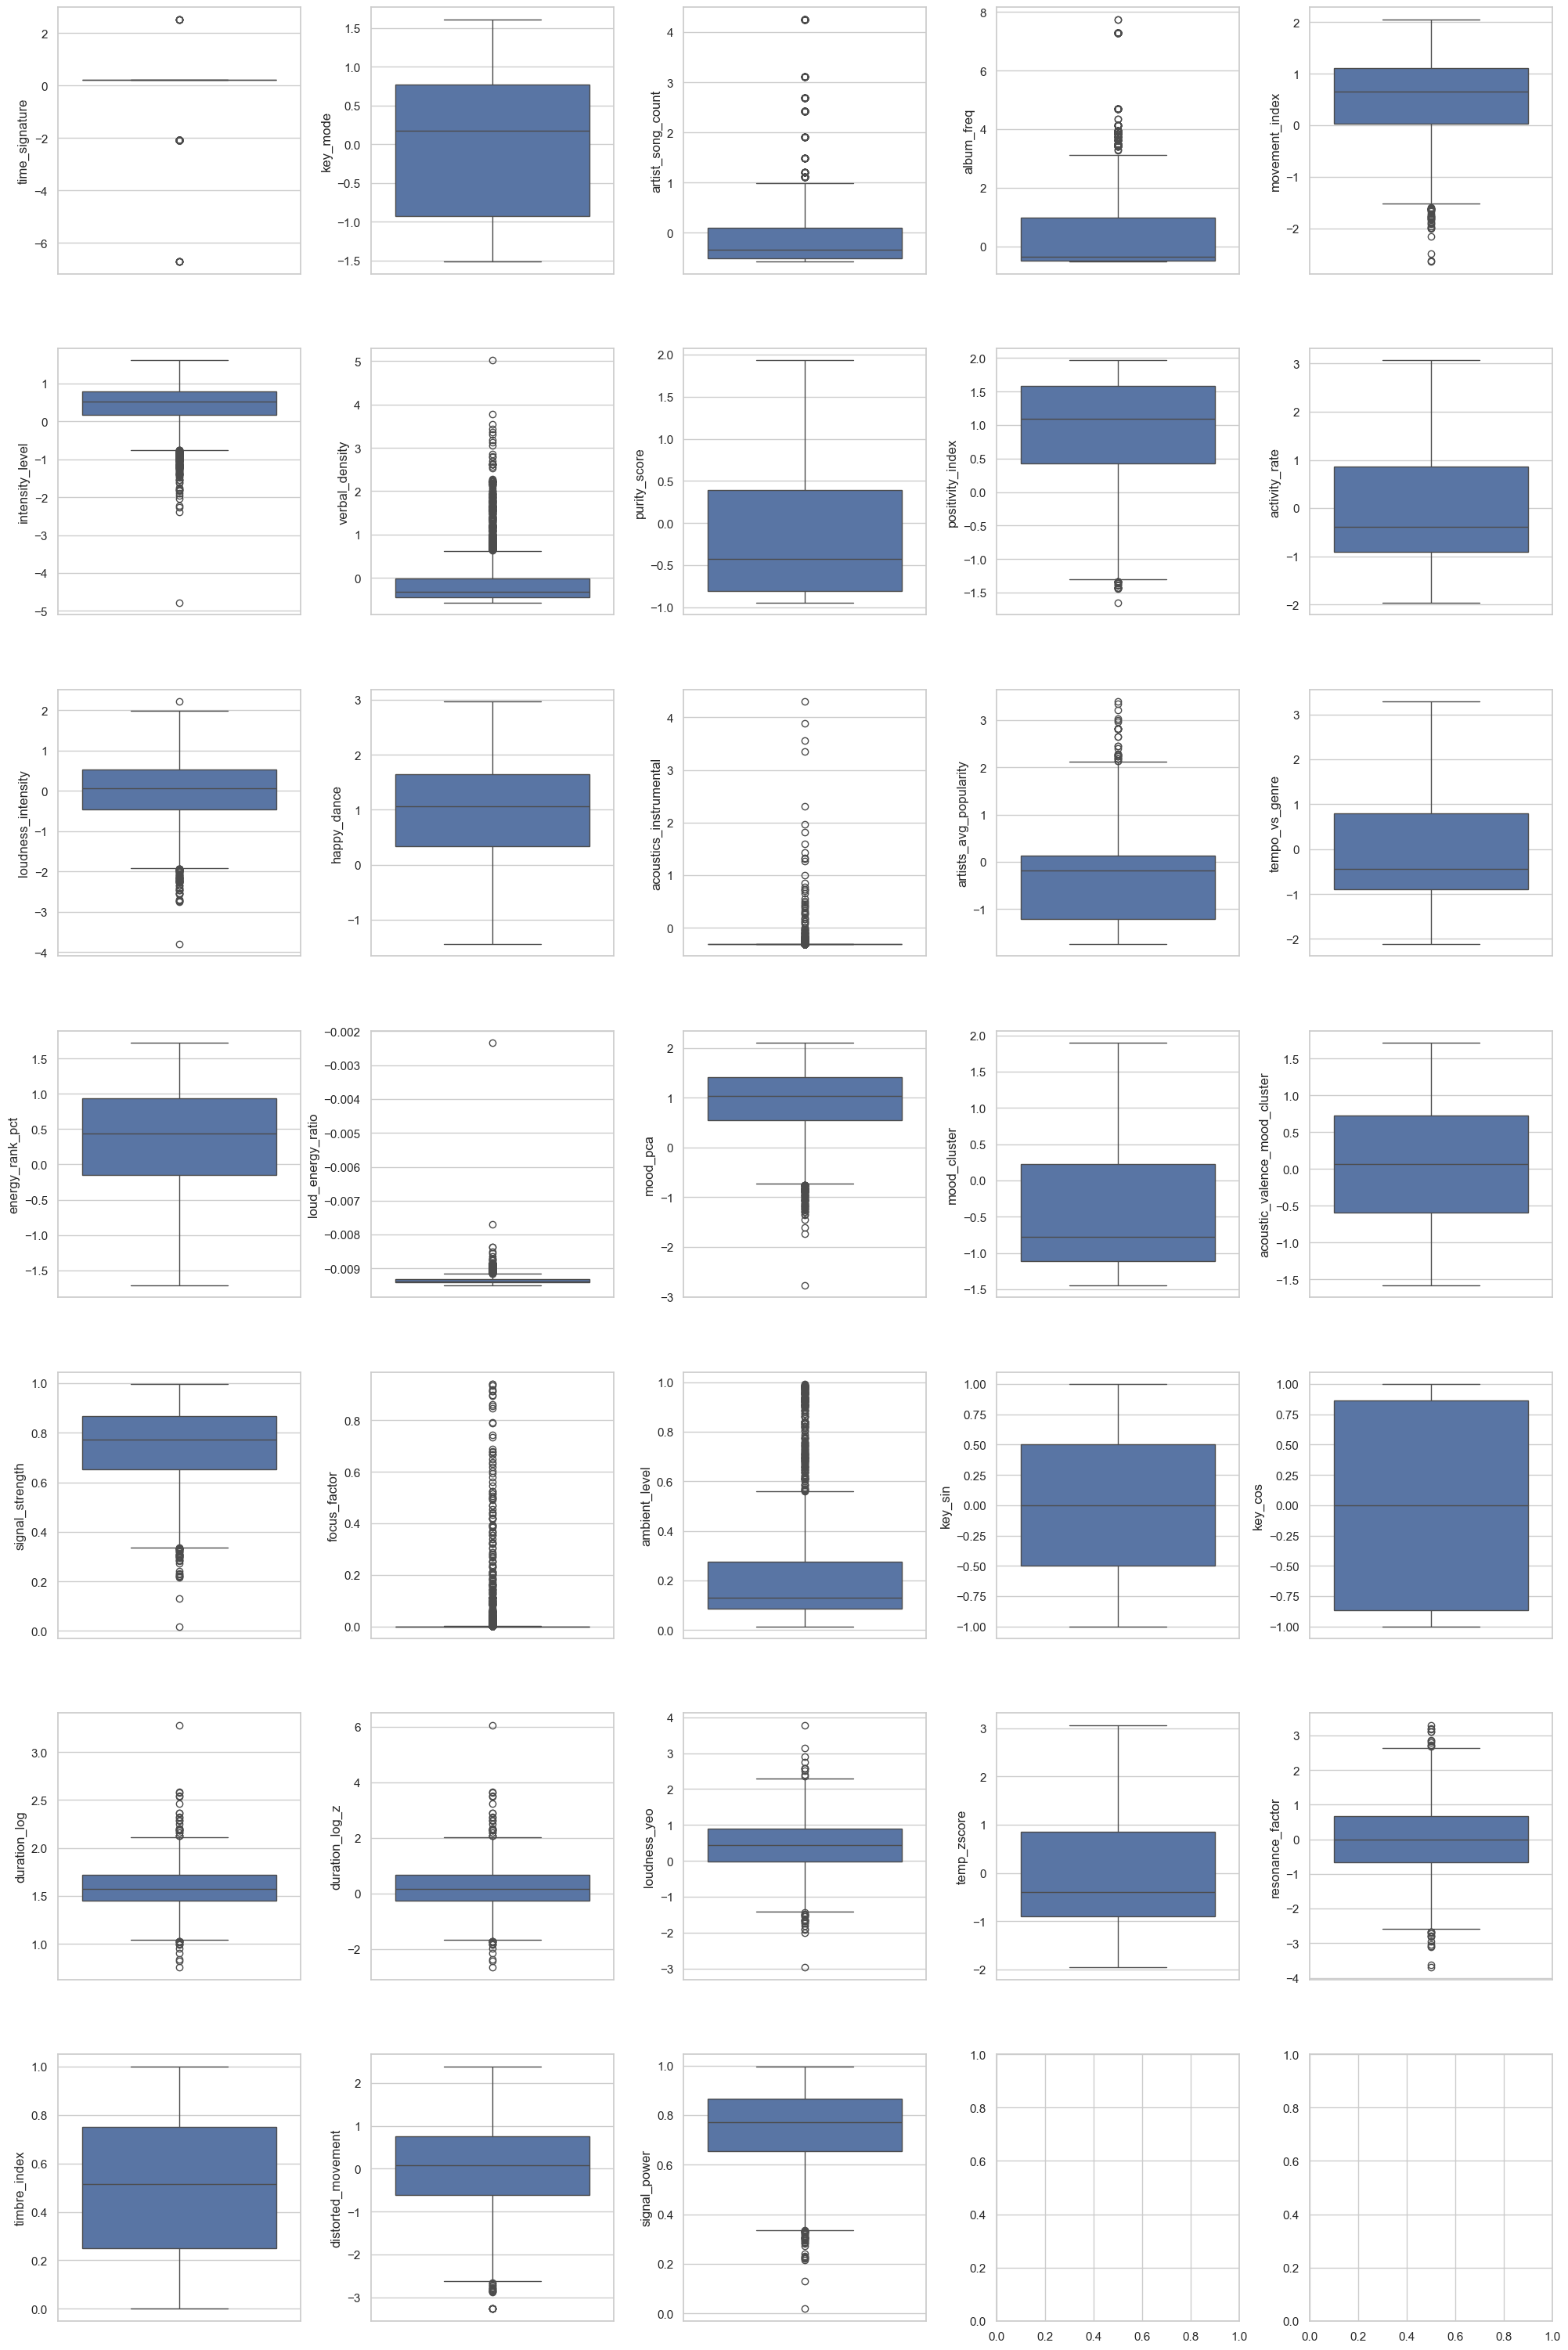

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
# to calculate the grid size based on number of features
import math

# VISUALIZING OUTLIERS

fig, axs = plt.subplots(ncols=5, nrows=7, figsize=(20, 30))
index = 0
axs = axs.flatten()
for k,v in numerical_cols.items():
    sns.boxplot(y=k, data=data, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=5.0)

In [127]:
# checking outlier percentage in every column

for k in numerical_cols:
        v = numerical_cols[k]  # Get the column data from your DataFrame
        q1 = v.quantile(0.25)
        q3 = v.quantile(0.75)
        irq = q3 - q1
        v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
        perc = np.shape(v_col)[0] * 100.0 / np.shape(data)[0]
        print("Column %s outliers = %.2f%%" % (k, perc))

Column time_signature outliers = 100.00%
Column key_mode outliers = 0.00%
Column artist_song_count outliers = 7.10%
Column album_freq outliers = 8.23%
Column movement_index outliers = 1.07%
Column intensity_level outliers = 4.17%
Column verbal_density outliers = 8.93%
Column purity_score outliers = 0.00%
Column positivity_index outliers = 0.63%
Column activity_rate outliers = 0.00%
Column loudness_intensity outliers = 1.93%
Column happy_dance outliers = 0.00%
Column acoustics_instrumental outliers = 20.47%
Column artists_avg_popularity outliers = 0.97%
Column tempo_vs_genre outliers = 0.00%
Column energy_rank_pct outliers = 0.00%
Column loud_energy_ratio outliers = 5.27%
Column mood_pca outliers = 2.47%
Column mood_cluster outliers = 0.00%
Column acoustic_valence_mood_cluster outliers = 0.00%
Column signal_strength outliers = 1.23%
Column focus_factor outliers = 20.50%
Column ambient_level outliers = 6.77%
Column key_sin outliers = 0.00%
Column key_cos outliers = 0.00%
Column duration_

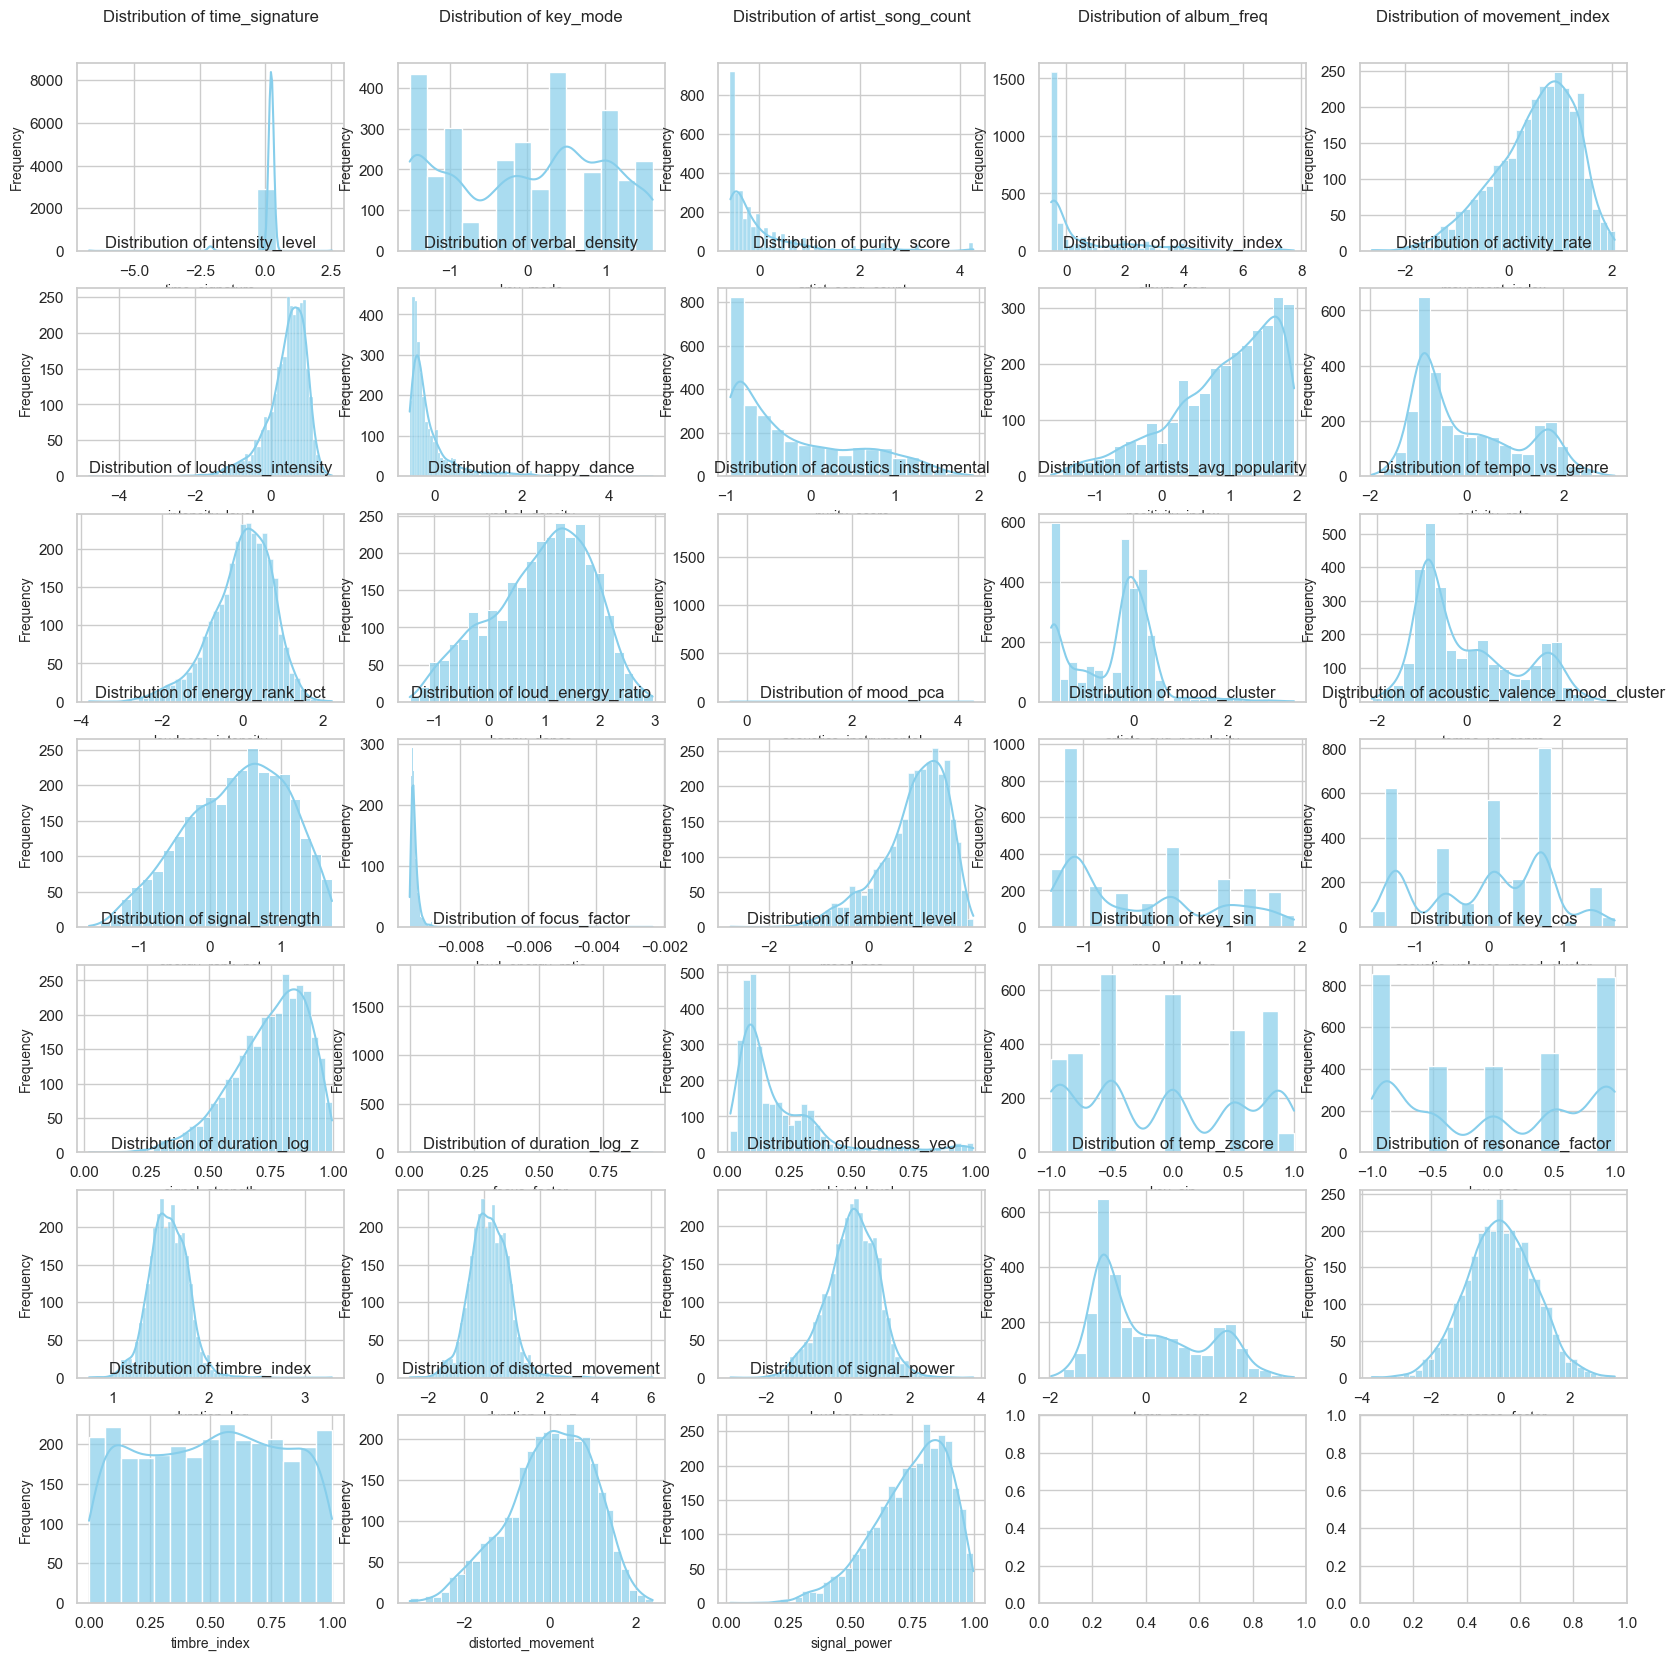

In [128]:
# distribution

fig, axs = plt.subplots(ncols=5, nrows=7, figsize=(20, 20))
axs = axs.flatten()

for index, feature in enumerate(numerical_cols):
    # Create histogram with density curve
    sns.histplot(numerical_cols[feature], ax=axs[index], kde=True, alpha=0.7, color='skyblue')
    axs[index].set_title(f'Distribution of {feature}', fontsize=12, pad=30)
    axs[index].set_xlabel(feature, fontsize=10)
    axs[index].set_ylabel('Frequency', fontsize=10)

### Tratamento de Outliers

In [129]:
def remove_outliers_iqr(df, features):
    outlier_mask = pd.Series([False] * len(df))
    
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        feature_outliers = (df[feature] < lower) | (df[feature] > upper)
        outlier_mask = outlier_mask | feature_outliers
    
    print(f"Removing {outlier_mask.sum()} rows ({outlier_mask.mean()*100:.1f}% of data)")
    return df[~outlier_mask].reset_index(drop=True)

# This ACTUALLY reduces outliers to 0% (by removing them)
data_clean = remove_outliers_iqr(numerical_cols, numerical_features)

Removing 1585 rows (52.8% of data)


Vamos verificar se este procedimento corrigiu a presença de outliers:

In [130]:
# checking outlier percentage in every column

for k in data_clean:
        v = numerical_cols[k]  # Get the column data from your DataFrame
        q1 = v.quantile(0.25)
        q3 = v.quantile(0.75)
        irq = q3 - q1
        v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
        perc = np.shape(v_col)[0] * 100.0 / np.shape(data)[0]
        print("Column %s outliers = %.2f%%" % (k, perc))

Column time_signature outliers = 100.00%
Column key_mode outliers = 0.00%
Column artist_song_count outliers = 7.10%
Column album_freq outliers = 8.23%
Column movement_index outliers = 1.07%
Column intensity_level outliers = 4.17%
Column verbal_density outliers = 8.93%
Column purity_score outliers = 0.00%
Column positivity_index outliers = 0.63%
Column activity_rate outliers = 0.00%
Column loudness_intensity outliers = 1.93%
Column happy_dance outliers = 0.00%
Column acoustics_instrumental outliers = 20.47%
Column artists_avg_popularity outliers = 0.97%
Column tempo_vs_genre outliers = 0.00%
Column energy_rank_pct outliers = 0.00%
Column loud_energy_ratio outliers = 5.27%
Column mood_pca outliers = 2.47%
Column mood_cluster outliers = 0.00%
Column acoustic_valence_mood_cluster outliers = 0.00%
Column signal_strength outliers = 1.23%
Column focus_factor outliers = 20.50%
Column ambient_level outliers = 6.77%
Column key_sin outliers = 0.00%
Column key_cos outliers = 0.00%
Column duration_

In [131]:
# sumário das características categóricas

print("\n=== CATEGORICAL FEATURES SUMMARY ===")

# looking at each categorical feature one by one
for col in categorical_cols:
    print(f"\n--- Analyzing: {col} ---")
    
    # Count how many different categories exist
    num_categories = categorical_cols[col].nunique()
    print(f"This feature has {num_categories} different categories")
    
    # Show the most common categories and how often they appear
    print("Most common values and their counts:")
    value_counts = categorical_cols[col].value_counts()
    print(value_counts.head())  # Show top 5 most frequent
    
    # Also show percentages to understand distribution
    print("As percentages:")
    percentages = categorical_cols[col].value_counts(normalize=True) * 100
    print(percentages.head().round(2))


=== CATEGORICAL FEATURES SUMMARY ===

--- Analyzing: duration_1 ---
This feature has 2 different categories
Most common values and their counts:
duration_1
0.0    2715
1.0     285
Name: count, dtype: int64
As percentages:
duration_1
0.0    90.5
1.0     9.5
Name: proportion, dtype: float64

--- Analyzing: duration_2 ---
This feature has 2 different categories
Most common values and their counts:
duration_2
0.0    2007
1.0     993
Name: count, dtype: int64
As percentages:
duration_2
0.0    66.9
1.0    33.1
Name: proportion, dtype: float64

--- Analyzing: duration_3 ---
This feature has 2 different categories
Most common values and their counts:
duration_3
0.0    2000
1.0    1000
Name: count, dtype: int64
As percentages:
duration_3
0.0    66.67
1.0    33.33
Name: proportion, dtype: float64

--- Analyzing: duration_4 ---
This feature has 2 different categories
Most common values and their counts:
duration_4
0.0    2303
1.0     697
Name: count, dtype: int64
As percentages:
duration_4
0.0  

In [132]:
print("As categorias estão perfeitamente balanceadas, o que indica que o modelo não será biased")

As categorias estão perfeitamente balanceadas, o que indica que o modelo não será biased



Visualizing: duration_1


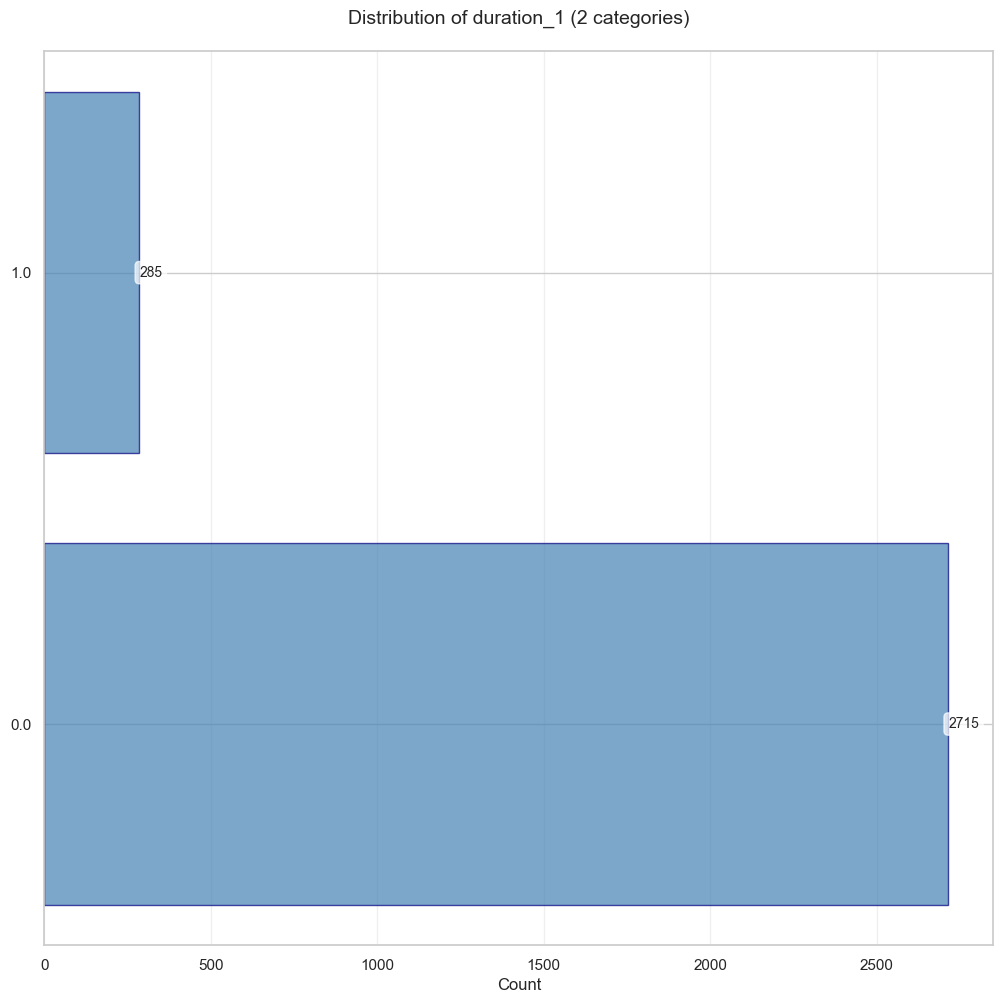

Categories: 2
Most common: '0.0' (2715 times)
Least common: '1.0' (285 times)
--------------------------------------------------

Visualizing: duration_2


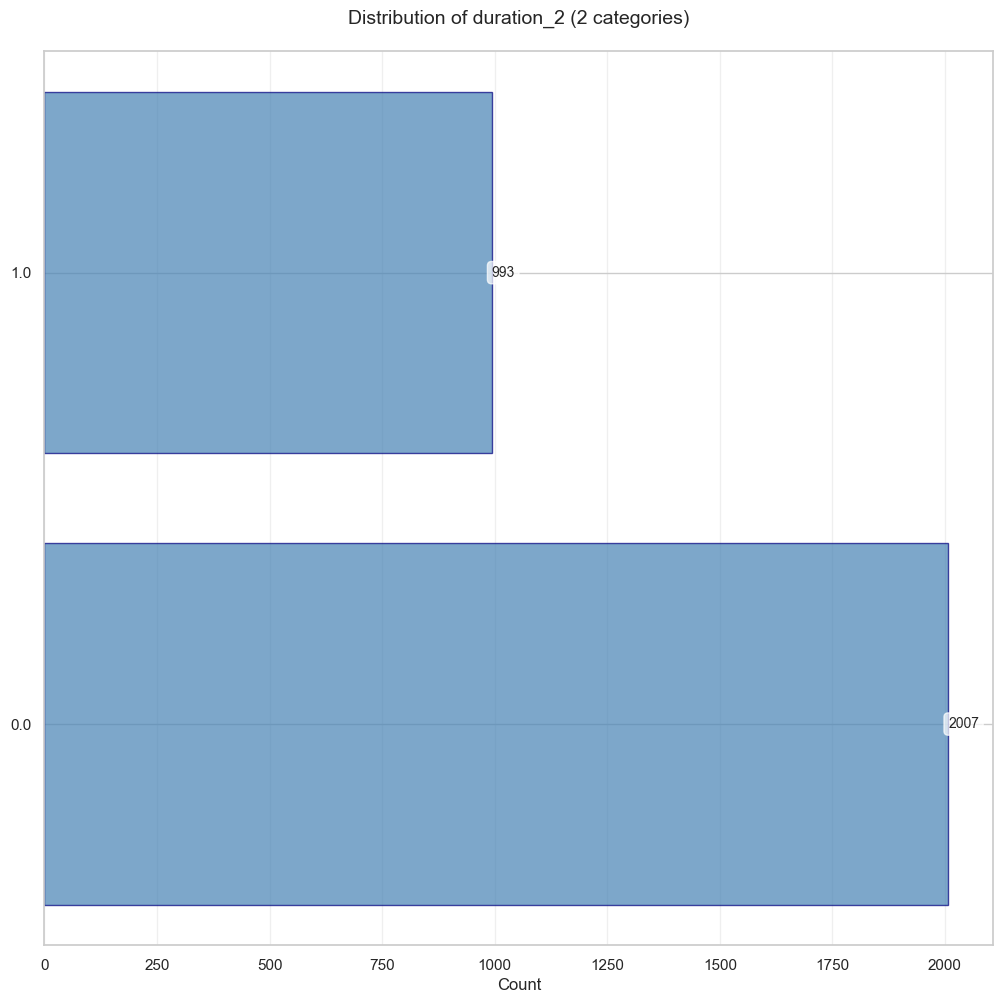

Categories: 2
Most common: '0.0' (2007 times)
Least common: '1.0' (993 times)
--------------------------------------------------

Visualizing: duration_3


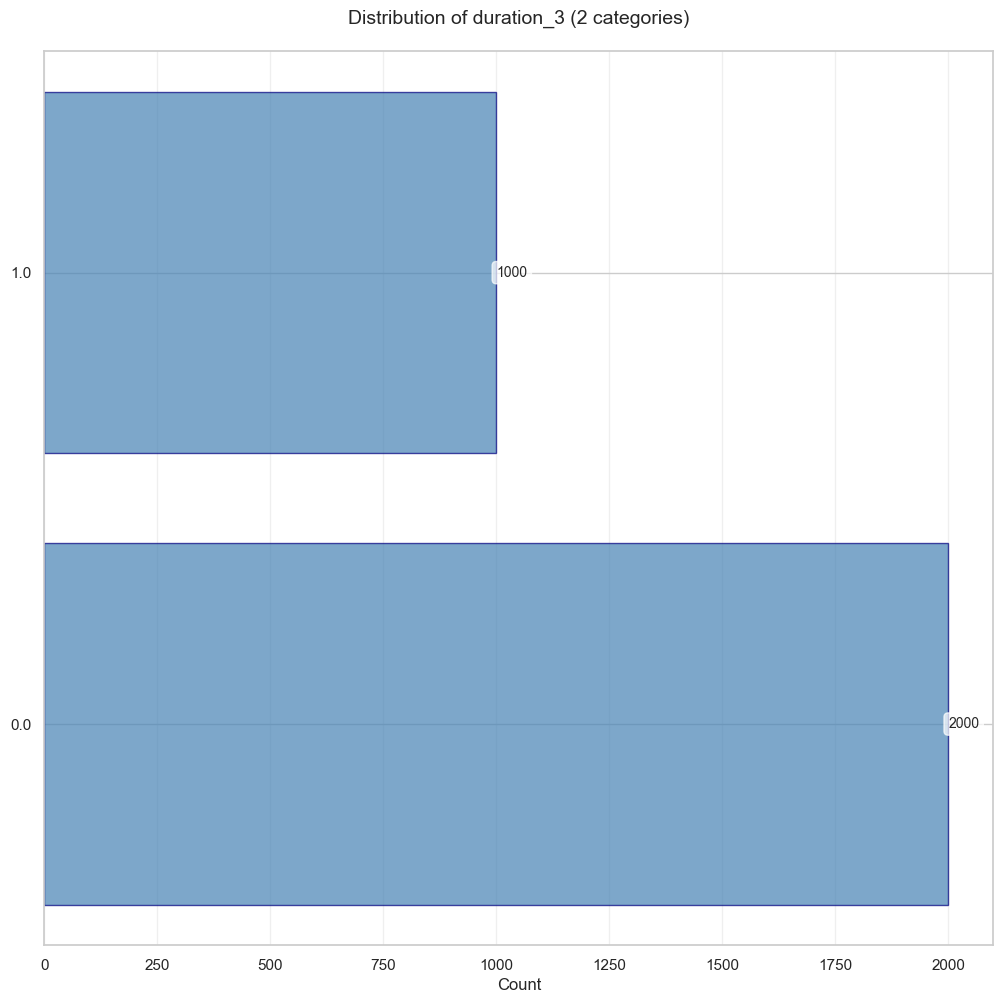

Categories: 2
Most common: '0.0' (2000 times)
Least common: '1.0' (1000 times)
--------------------------------------------------

Visualizing: duration_4


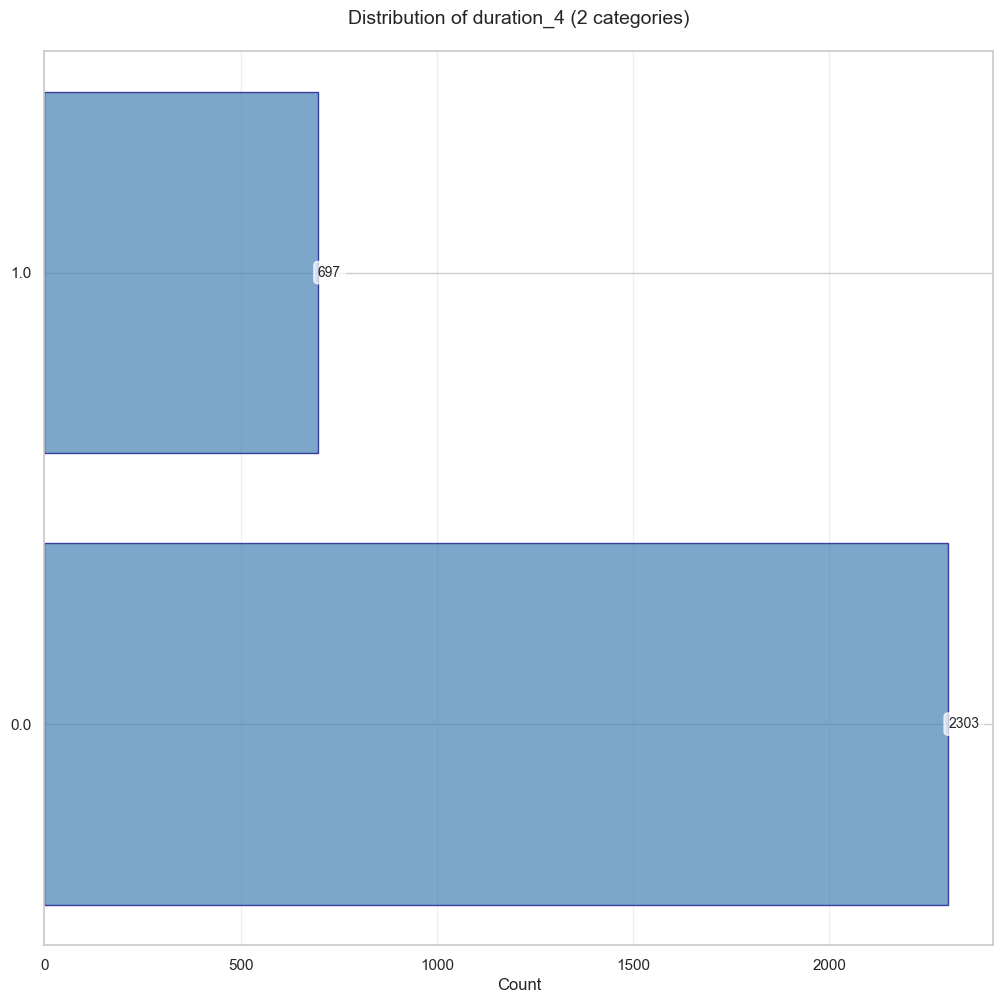

Categories: 2
Most common: '0.0' (2303 times)
Least common: '1.0' (697 times)
--------------------------------------------------

Visualizing: duration_5


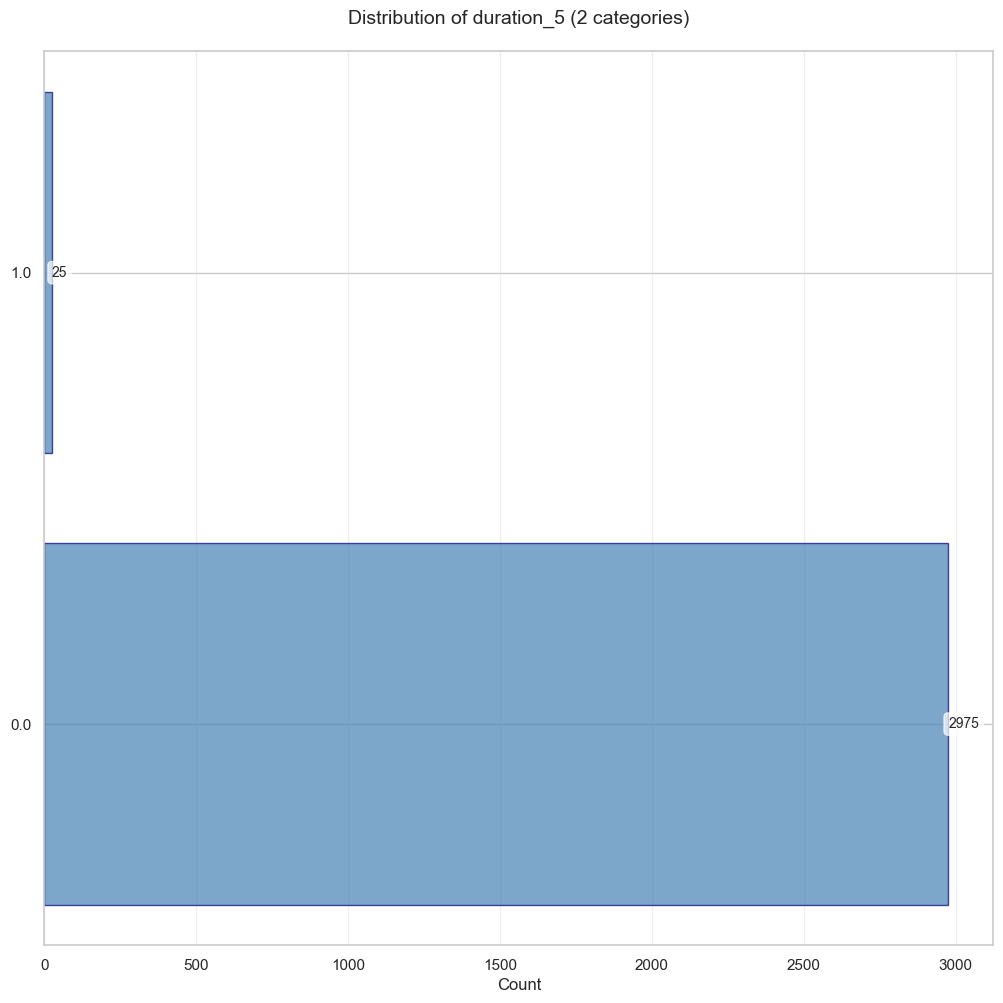

Categories: 2
Most common: '0.0' (2975 times)
Least common: '1.0' (25 times)
--------------------------------------------------

Visualizing: loudness_level


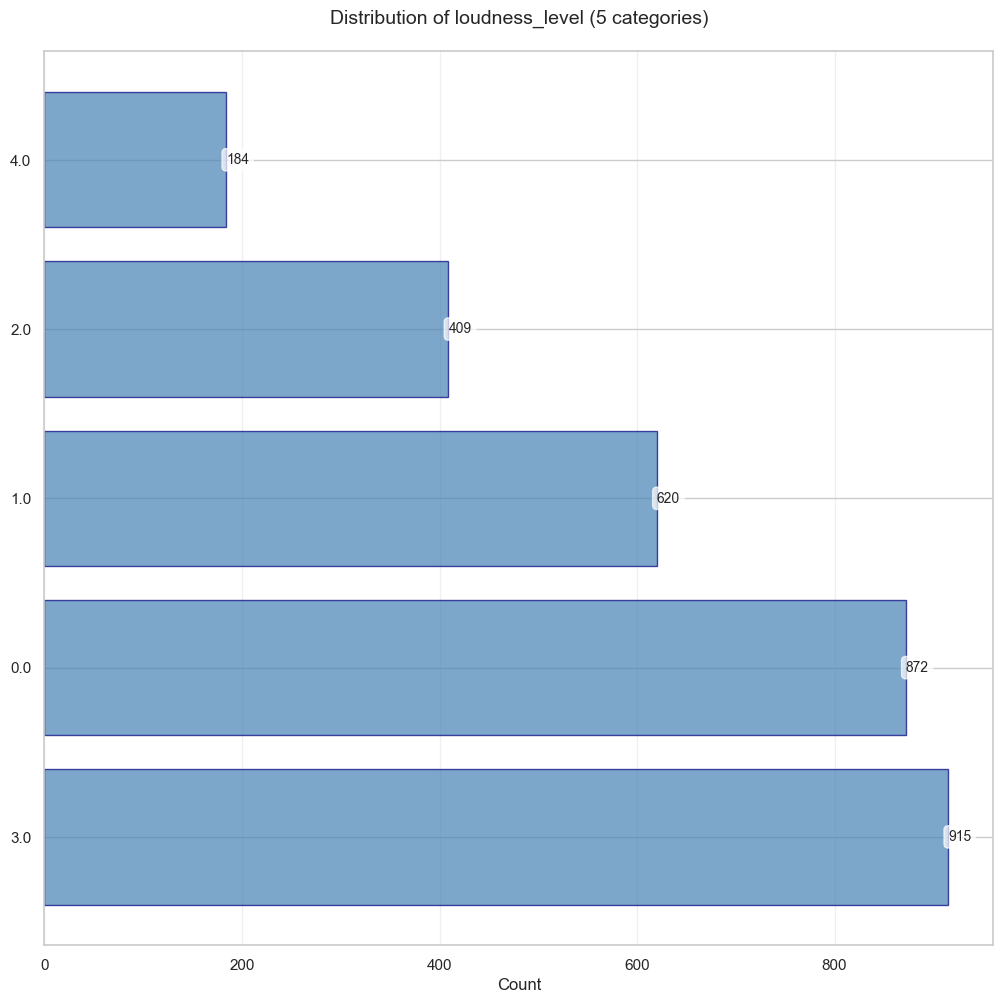

Categories: 5
Most common: '3.0' (915 times)
Least common: '4.0' (184 times)
--------------------------------------------------

Visualizing: popularity_level


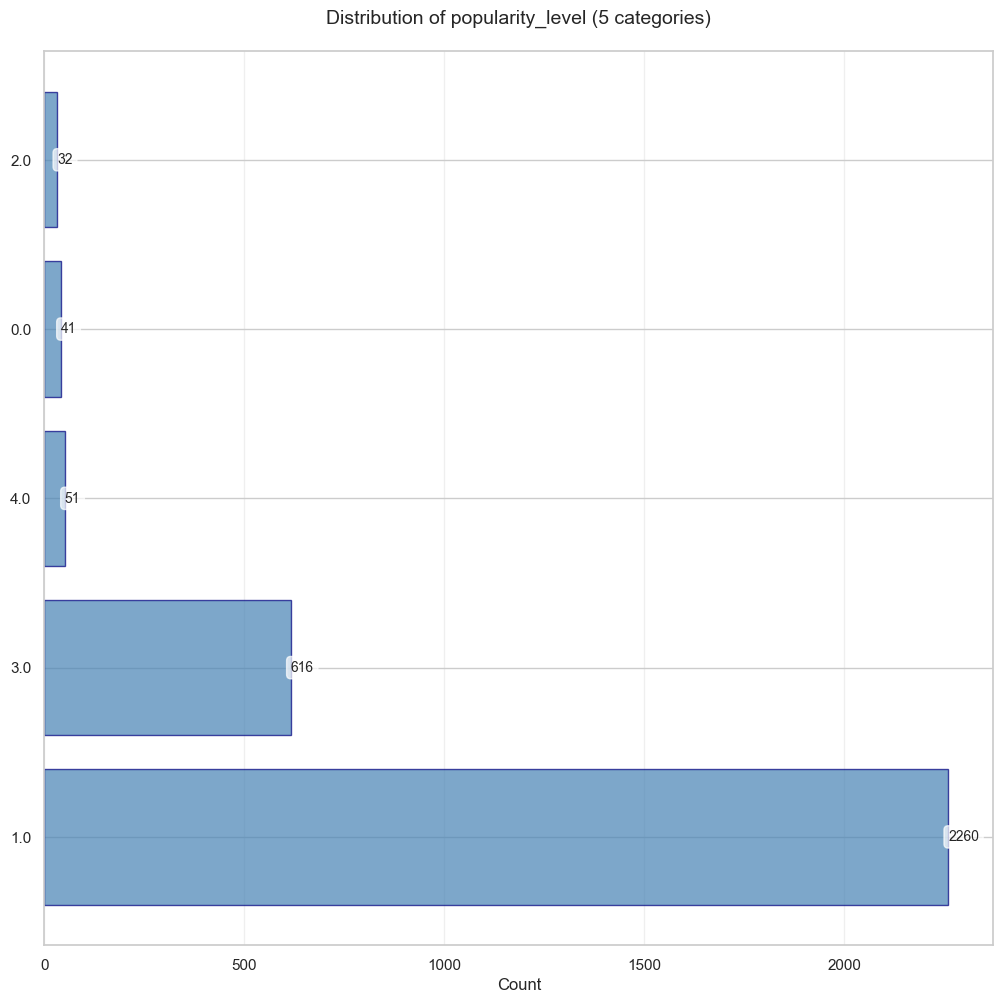

Categories: 5
Most common: '1.0' (2260 times)
Least common: '2.0' (32 times)
--------------------------------------------------

Visualizing: tempo_class


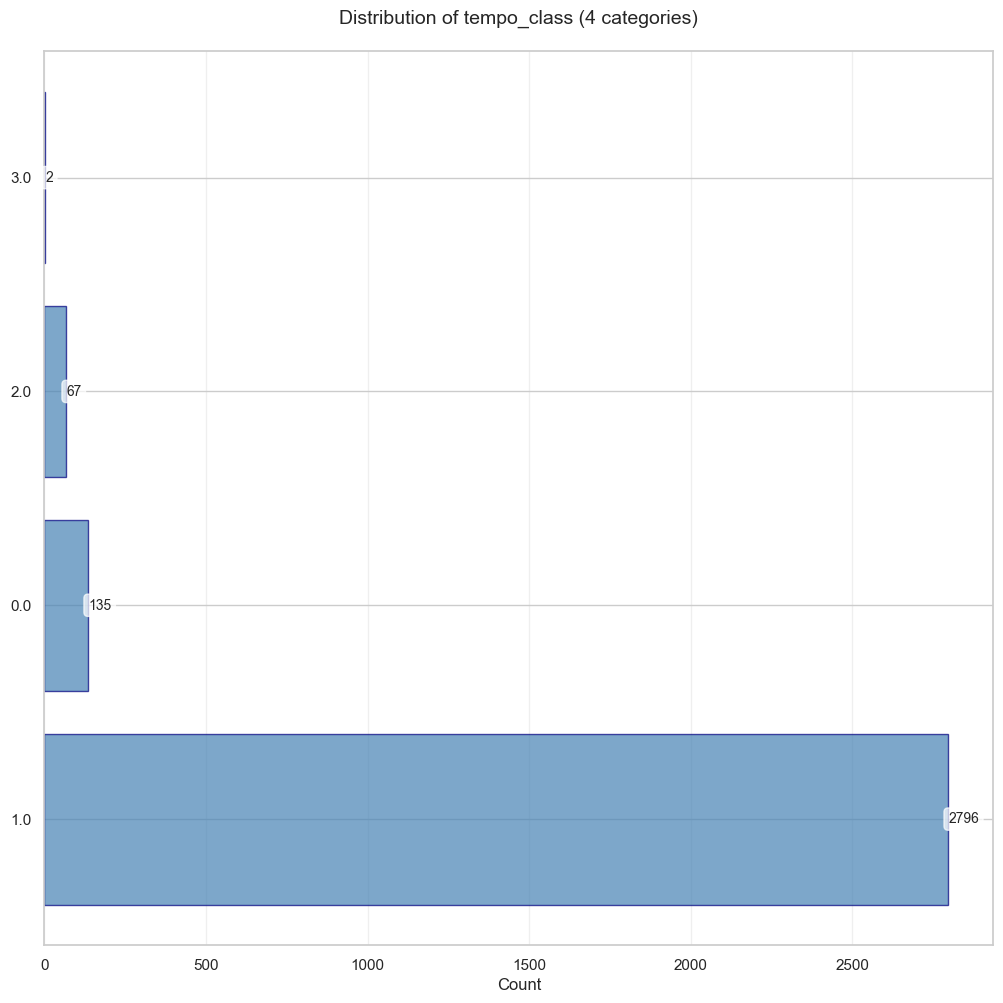

Categories: 4
Most common: '1.0' (2796 times)
Least common: '3.0' (2 times)
--------------------------------------------------

Visualizing: explicit


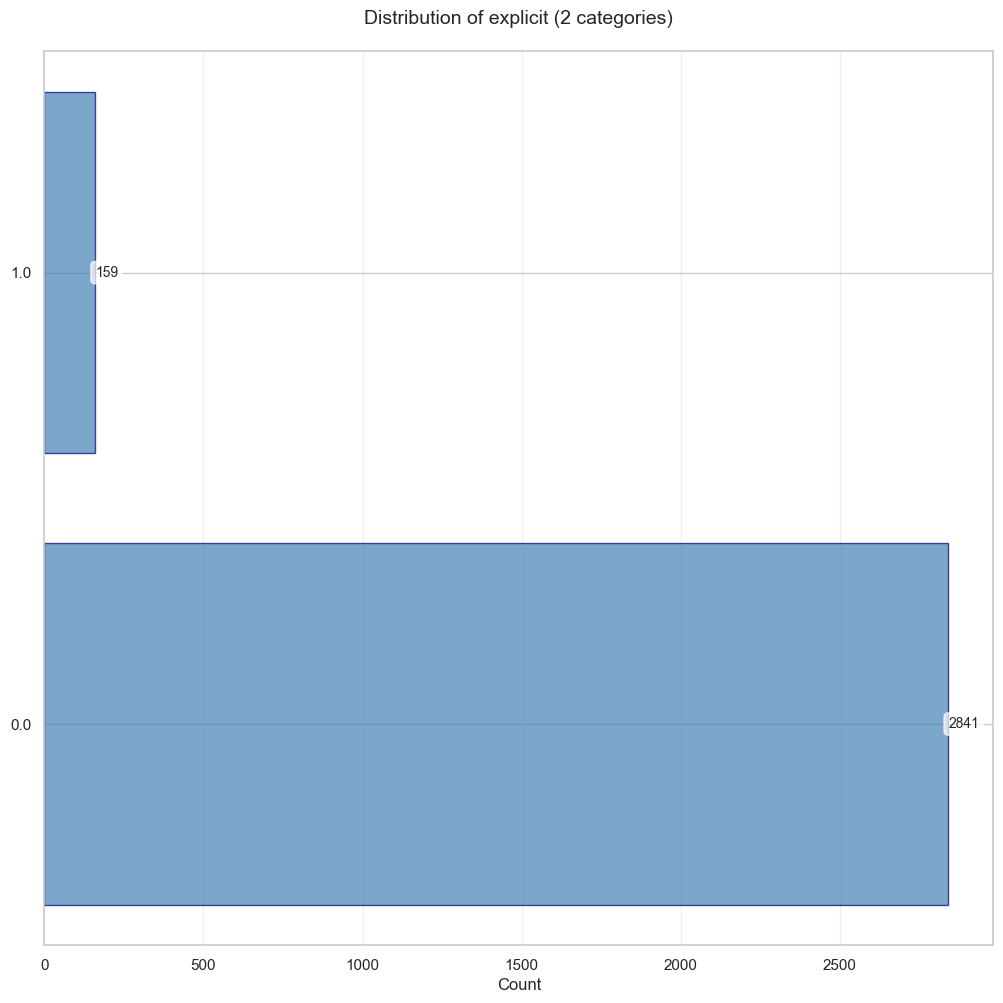

Categories: 2
Most common: '0.0' (2841 times)
Least common: '1.0' (159 times)
--------------------------------------------------

Visualizing: mode_indicator


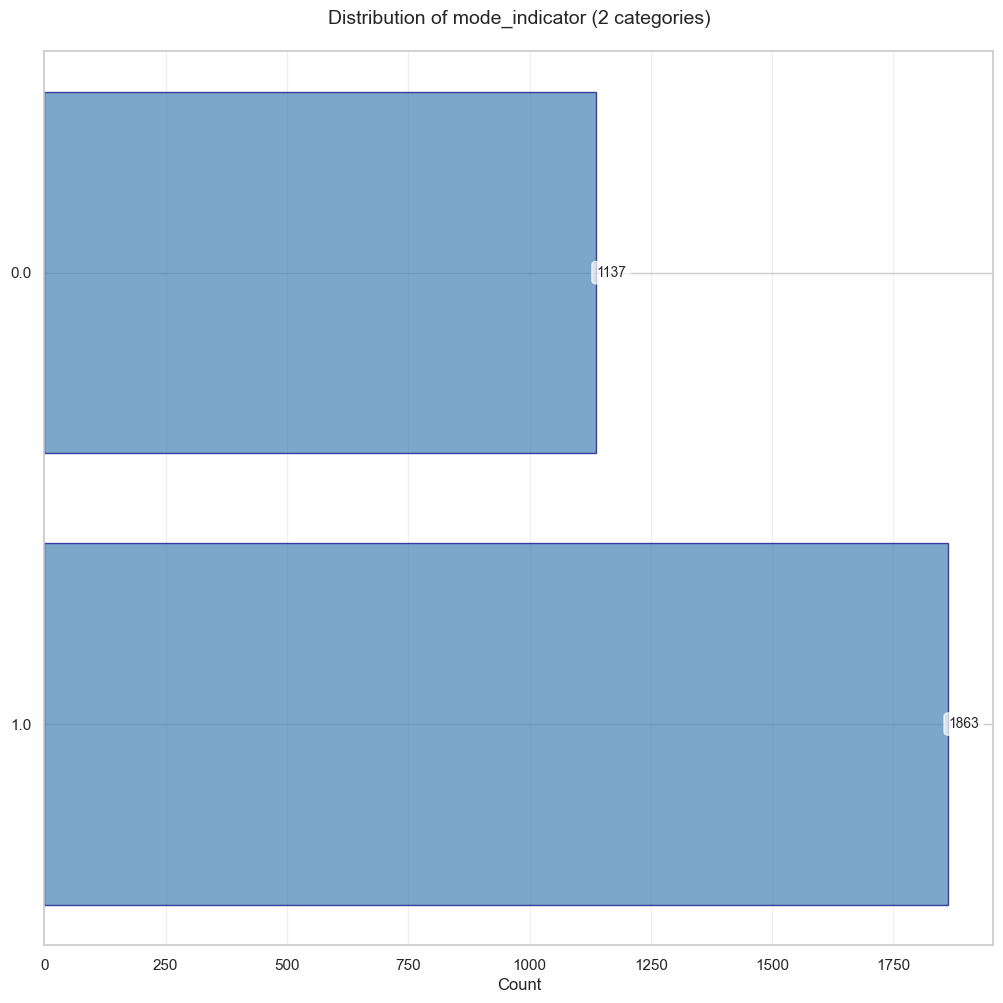

Categories: 2
Most common: '1.0' (1863 times)
Least common: '0.0' (1137 times)
--------------------------------------------------

Visualizing: time_signature_class_boolean


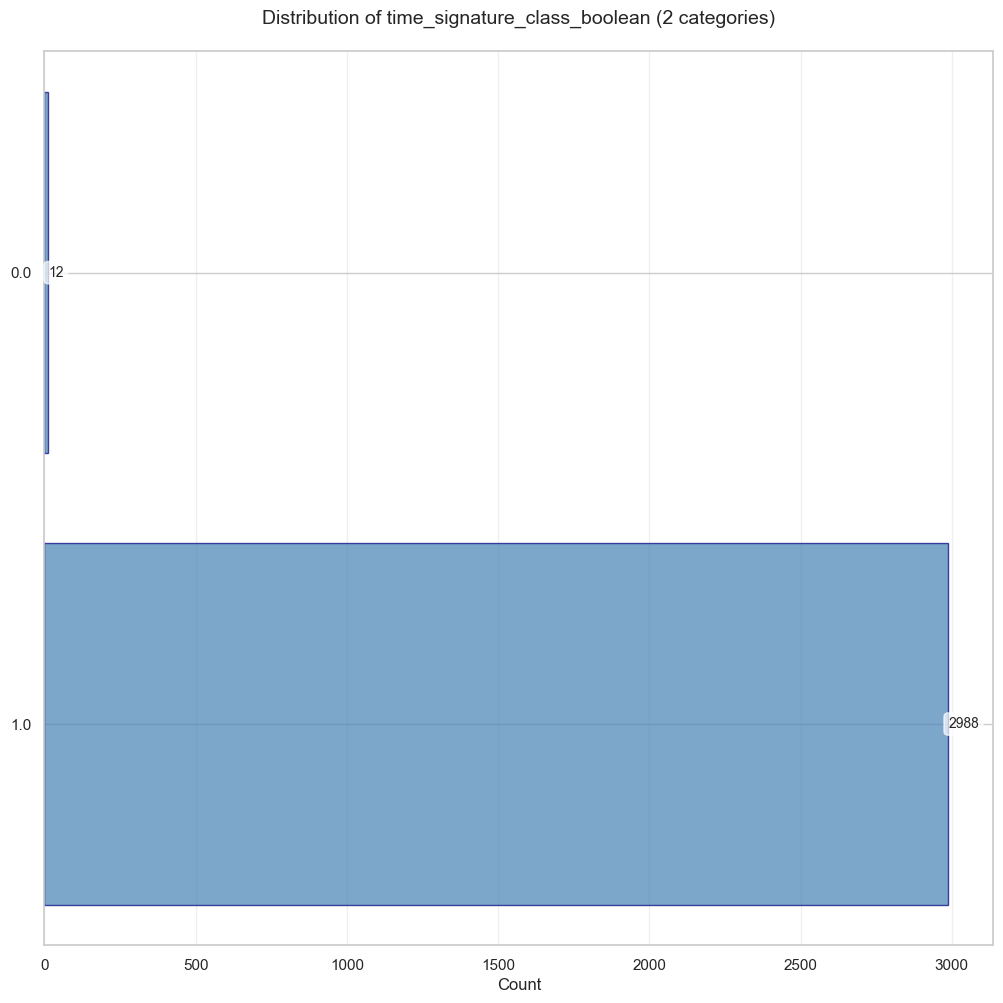

Categories: 2
Most common: '1.0' (2988 times)
Least common: '0.0' (12 times)
--------------------------------------------------

Visualizing: is_instrumental


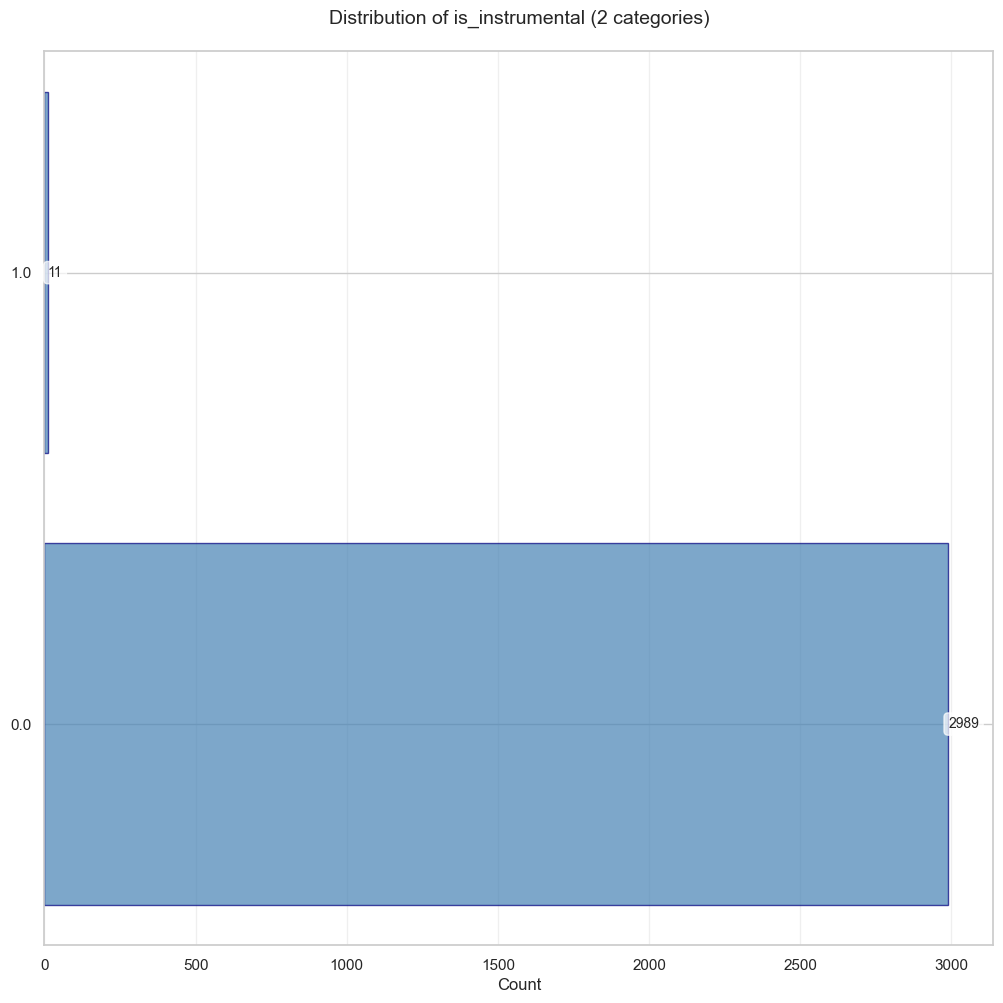

Categories: 2
Most common: '0.0' (2989 times)
Least common: '1.0' (11 times)
--------------------------------------------------

Visualizing: is_dance_hit


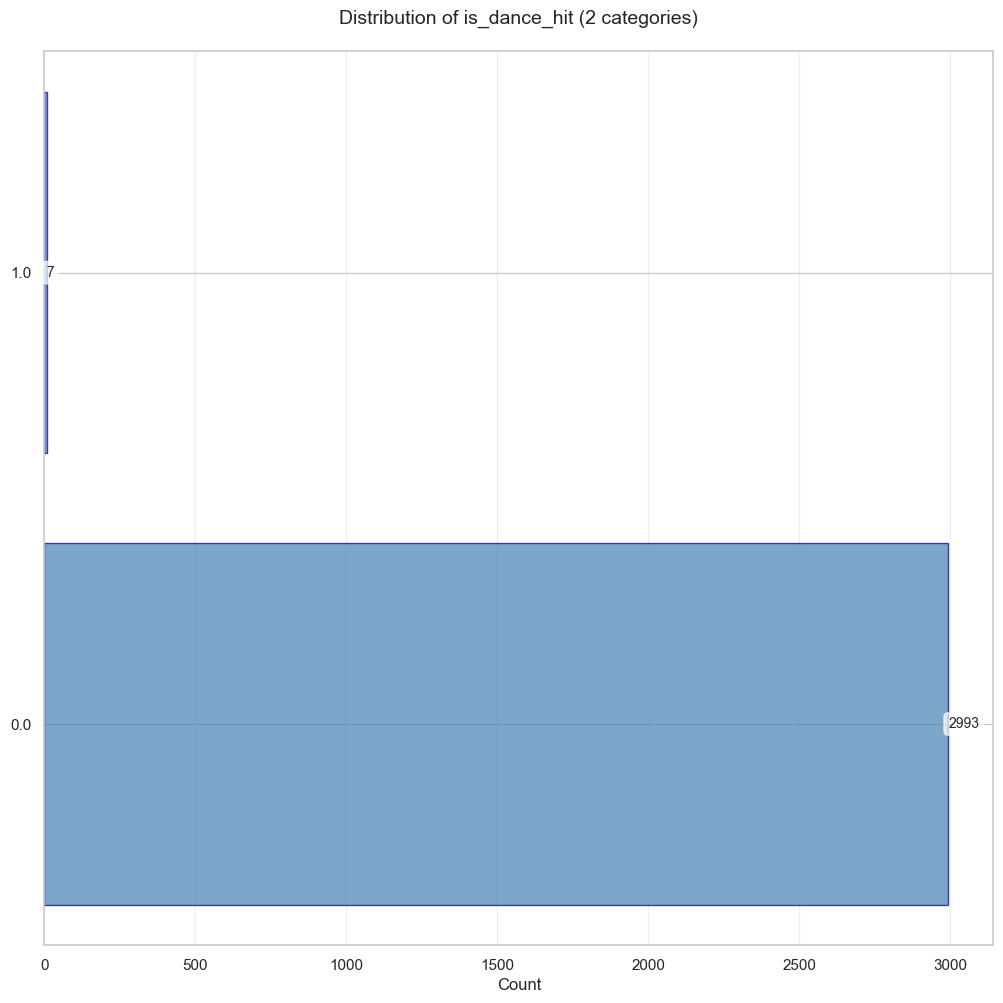

Categories: 2
Most common: '0.0' (2993 times)
Least common: '1.0' (7 times)
--------------------------------------------------

Visualizing: echo_constant


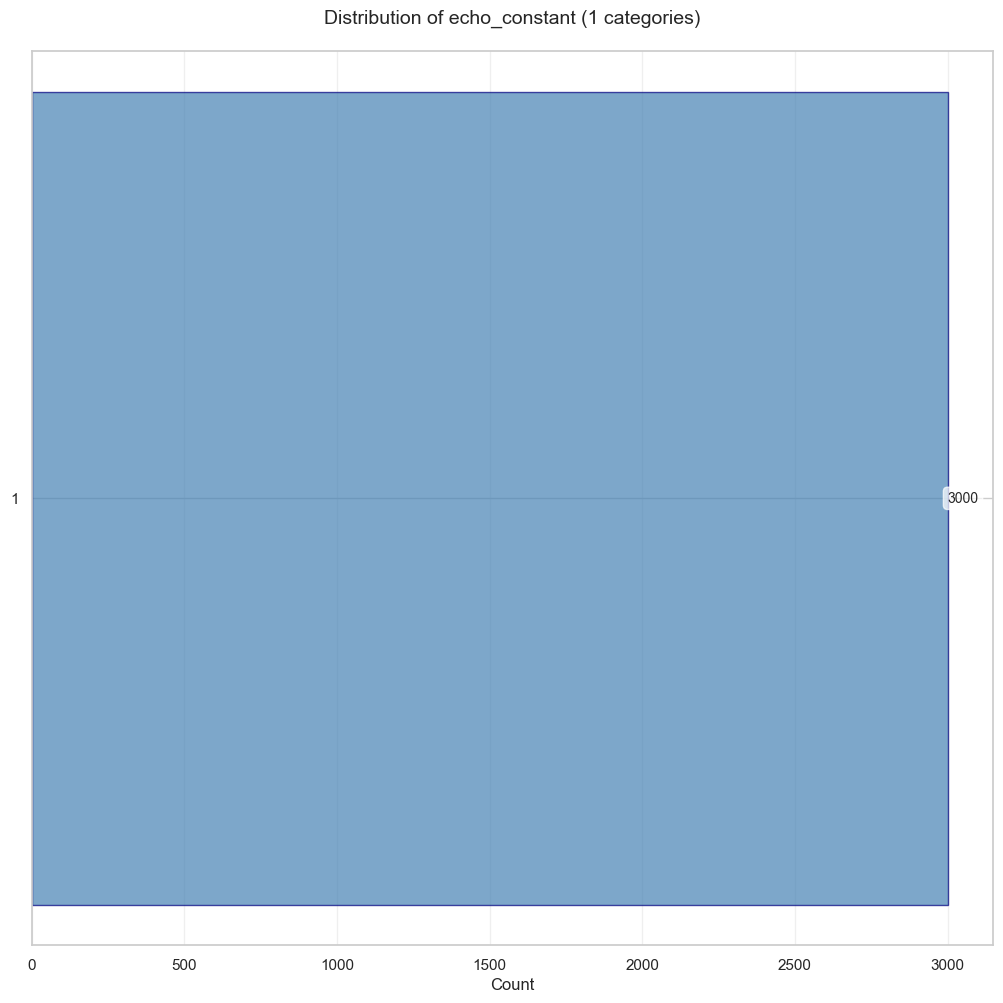

Categories: 1
Most common: '1' (3000 times)
--------------------------------------------------


In [133]:
## Bar chart

for col in categorical_cols:
    print(f"\nVisualizing: {col}")
    
    value_counts = data[col].value_counts()
    num_categories = len(value_counts)
    
    # Create figure for this feature
    plt.subplots(figsize=(10, 10))
    
    # For features with many categories, show only top 15
    if num_categories > 15:
        plot_data = value_counts.head(15)
        title_suffix = f" (Top 15 of {num_categories} categories)"
    else:
        plot_data = value_counts
        title_suffix = f" ({num_categories} categories)"
    
    # Create horizontal bar chart
    bars = plt.barh(range(len(plot_data)), plot_data.values, 
                   color='steelblue', alpha=0.7, edgecolor='navy')
    
    plt.yticks(range(len(plot_data)), plot_data.index)
    plt.title(f'Distribution of {col}{title_suffix}', fontsize=14, pad=20)
    plt.xlabel('Count')
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    
    plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=5.0)
    plt.show()
    
    # Print summary statistics
    print(f"Categories: {num_categories}")
    print(f"Most common: '{value_counts.index[0]}' ({value_counts.iloc[0]} times)")
    if num_categories > 1:
        print(f"Least common: '{value_counts.index[-1]}' ({value_counts.iloc[-1]} times)")
    print("-" * 50)

## Análise Bivariada

A análise bivariada examina a relação entre pares de variáveis, permitindo-nos identificar quais features têm maior poder preditivo sobre os nossos targets. Esta análise é fundamental para:

1. **Compreender relações lineares** entre features e o target de regressão (`target_regression`)
2. **Identificar features discriminativas** para o target de classificação (`target_class`)
3. **Orientar a seleção de features** para os modelos subsequentes

### Metodologia

Utilizaremos duas abordagens estatísticas distintas:

| Target | Método | Descrição |
|--------|--------|-----------|
| `target_regression` | Correlação de Pearson | Mede a força e direção da relação linear entre variáveis contínuas. Valores variam de -1 a 1. |
| `target_class` | ANOVA F-score | Testa se as médias de uma feature diferem significativamente entre classes. Valores mais altos indicam maior poder discriminativo. |

---

### 2.1 Preparação dos Dados para Análise Bivariada

Primeiro, asseguramos que estamos a utilizar as features numéricas corretas, excluindo os targets.

In [134]:
# Definir as features numéricas para análise (excluindo targets)
# Nota: Utilizamos o DataFrame 'data' original com focus_factor já convertido

# Recriar lista de features numéricas para garantir consistência
numeric_features_bivariate = data.select_dtypes(include=[np.number]).columns.tolist()

# Remover os targets da lista de features
numeric_features_bivariate = [col for col in numeric_features_bivariate 
                              if col not in [TARGET_CLASS, TARGET_REG]]

print(f"Total de features numéricas para análise bivariada: {len(numeric_features_bivariate)}")
print(f"Features: {numeric_features_bivariate[:10]}... (primeiras 10)")


Total de features numéricas para análise bivariada: 47
Features: ['duration_1', 'duration_2', 'duration_3', 'duration_4', 'duration_5', 'loudness_level', 'popularity_level', 'tempo_class', 'time_signature', 'key_mode']... (primeiras 10)


### 2.2 Correlação de Pearson com `target_regression`

A **correlação de Pearson** mede a força e direção da relação linear entre duas variáveis contínuas:

- **r = 1**: Correlação positiva perfeita
- **r = -1**: Correlação negativa perfeita  
- **r = 0**: Sem correlação linear
- **|r| > 0.7**: Correlação forte
- **0.4 < |r| < 0.7**: Correlação moderada
- **|r| < 0.4**: Correlação fraca

Calculamos a correlação de cada feature numérica com `target_regression` e ordenamos pelo valor absoluto.


In [135]:
# Calcular correlação de Pearson entre cada feature e target_regression
correlation_with_target = data[numeric_features_bivariate + [TARGET_REG]].corr(numeric_only=True)[TARGET_REG]

# Remover a correlação do target consigo mesmo
correlation_with_target = correlation_with_target.drop(TARGET_REG)

# Ordenar por valor absoluto (maior correlação primeiro)
correlation_sorted = correlation_with_target.abs().sort_values(ascending=False)

# Mostrar as top 15 correlações
TOP_N = 15
print(f"Top {TOP_N} features com maior correlação absoluta com {TARGET_REG}:")
print("=" * 60)

correlation_table = pd.DataFrame({
    'Feature': correlation_sorted.head(TOP_N).index,
    'Correlação Absoluta': correlation_sorted.head(TOP_N).values,
    'Correlação Real': [correlation_with_target[feat] for feat in correlation_sorted.head(TOP_N).index]
})

display(correlation_table)


Top 15 features com maior correlação absoluta com target_regression:


,Feature,Correlação Absoluta,Correlação Real
0,artists_avg_popularity,0.879063,0.879063
1,album_freq,0.639828,-0.639828
2,popularity_level,0.535562,0.535562
3,movement_index,0.210674,-0.210674
4,loudness_intensity,0.200283,-0.200283
5,artist_song_count,0.185818,-0.185818
6,mood_cluster,0.143329,0.143329
7,energy_rank_pct,0.125562,0.125562
8,positivity_index,0.125460,0.125460
9,ambient_level,0.114526,0.114526


### 2.3 Visualização: Heatmap de Correlações

Um **heatmap** permite visualizar a matriz de correlações entre as features mais relevantes e o target. As cores indicam:
- **Vermelho**: Correlação positiva forte
- **Azul**: Correlação negativa forte
- **Branco/Neutro**: Sem correlação significativa


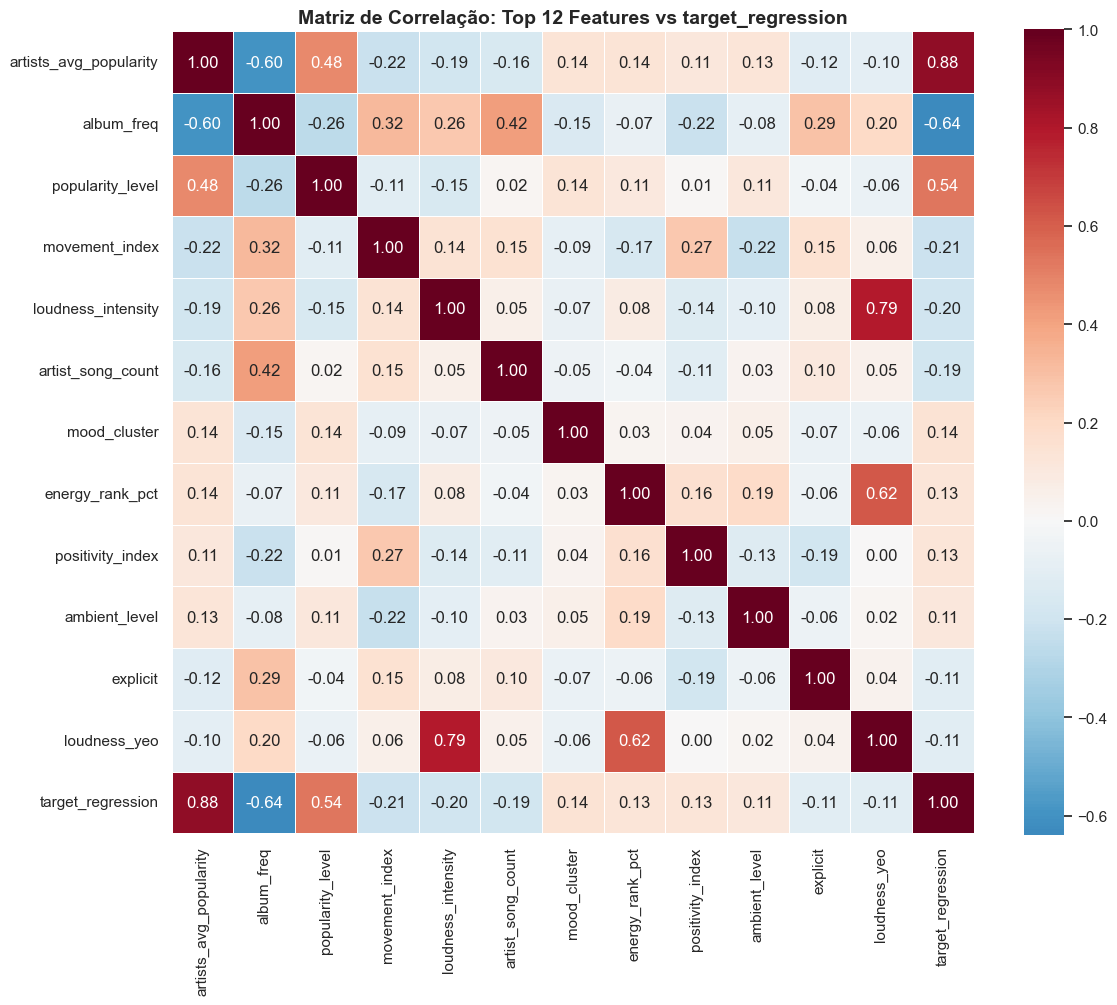

In [136]:
# Selecionar as top 12 features para o heatmap (mais legível)
top_features_heatmap = correlation_sorted.head(12).index.tolist()

# Criar matriz de correlação incluindo o target
heatmap_data = data[top_features_heatmap + [TARGET_REG]].corr()

# Visualizar heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, 
            cmap="RdBu_r",  # Red-Blue divergente
            center=0,       # Centro em zero
            annot=True,     # Mostrar valores
            fmt='.2f',      # 2 casas decimais
            square=True,    # Células quadradas
            linewidths=0.5)
plt.title(f'Matriz de Correlação: Top 12 Features vs {TARGET_REG}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.4 ANOVA F-score para `target_class`

Para variáveis de classificação, utilizamos o **teste ANOVA (Analysis of Variance)** através da função `f_classif` do scikit-learn.

**Interpretação do F-score:**
- Valores mais altos indicam que a feature tem médias significativamente diferentes entre as classes
- Features com F-score alto são boas candidatas para discriminar entre classes
- O p-value indica a significância estatística (p < 0.05 é considerado significativo)


In [137]:
# Preparar dados para ANOVA
# X: matriz de features numéricas
# y: vetor de classes (target_class)

X_anova = data[numeric_features_bivariate].values
y_anova = data[TARGET_CLASS].astype(str).values

# Calcular F-scores e p-values usando f_classif
f_scores, p_values = f_classif(X_anova, y_anova)

# Criar DataFrame com resultados ordenados por F-score
anova_results = pd.DataFrame({
    'Feature': numeric_features_bivariate,
    'F-Score': f_scores,
    'P-Value': p_values
}).sort_values('F-Score', ascending=False)

# Adicionar coluna de significância
anova_results['Significativo (p<0.05)'] = anova_results['P-Value'] < 0.05

print(f"Top {TOP_N} features com maior F-score ANOVA para {TARGET_CLASS}:")
print("=" * 70)
display(anova_results.head(TOP_N))


Top 15 features com maior F-score ANOVA para target_class:


,Feature,F-Score,P-Value,Significativo (p<0.05)
11,album_freq,1665.314051,0.000000e+00,True
15,purity_score,967.469681,0.000000e+00,True
21,artists_avg_popularity,817.240340,5.418499e-284,True
6,popularity_level,399.035229,2.260211e-154,True
27,acoustic_valence_mood_cluster,376.378157,1.484298e-146,True
35,duration_log,365.559480,8.663160e-143,True
36,duration_log_z,365.559480,8.663160e-143,True
12,movement_index,338.858676,2.123294e-133,True
16,positivity_index,236.597856,3.932441e-96,True
18,loudness_intensity,222.692729,6.778382e-91,True


### 2.5 Visualização: Boxplots das Top Features Discriminativas

Os **boxplots** permitem visualizar como as distribuições de cada feature variam entre as diferentes classes. Uma boa feature discriminativa apresentará boxplots claramente separados entre classes.


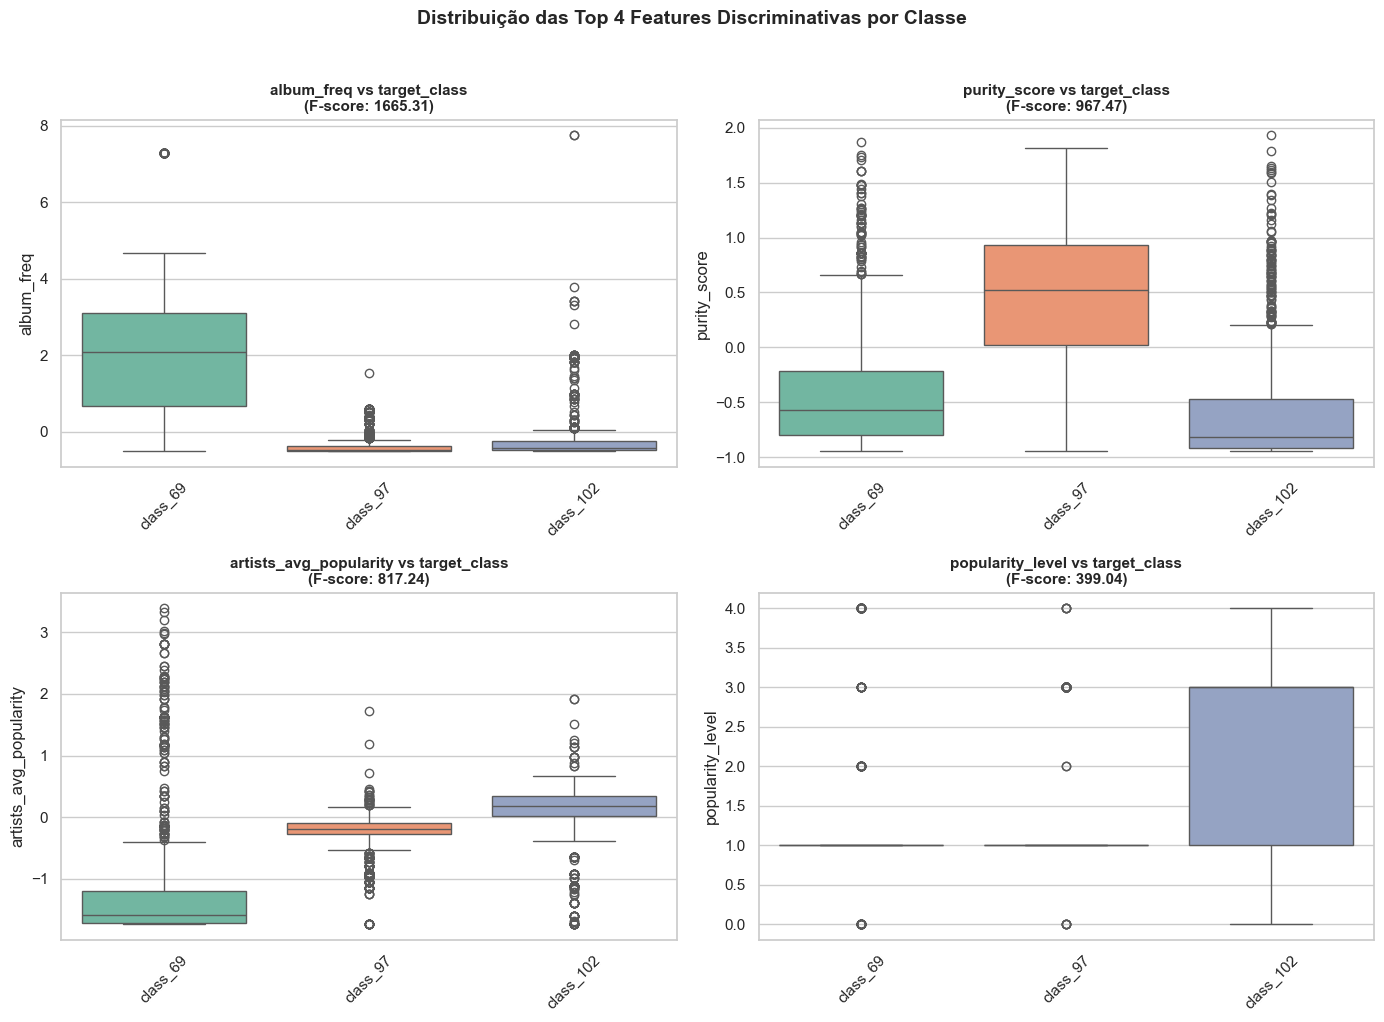

In [138]:
# Selecionar as top 4 features com maior F-score
top_4_features = anova_results.head(4)['Feature'].tolist()

# Criar subplots 2x2 para as 4 features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(top_4_features):
    sns.boxplot(data=data, x=TARGET_CLASS, y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} vs {TARGET_CLASS}\n(F-score: {anova_results[anova_results["Feature"]==feature]["F-Score"].values[0]:.2f})', 
                      fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.suptitle('Distribuição das Top 4 Features Discriminativas por Classe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 2.6 Análise para Regressão Linear Simples

Para a regressão linear simples, precisamos de identificar a feature com maior correlação linear com `target_regression`. Esta será a feature preditora no modelo de regressão univariada.


Top 5 features para regressão linear simples:
  1. artists_avg_popularity: r = 0.8791
  2. album_freq: r = -0.6398
  3. popularity_level: r = 0.5356
  4. movement_index: r = -0.2107
  5. loudness_intensity: r = -0.2003


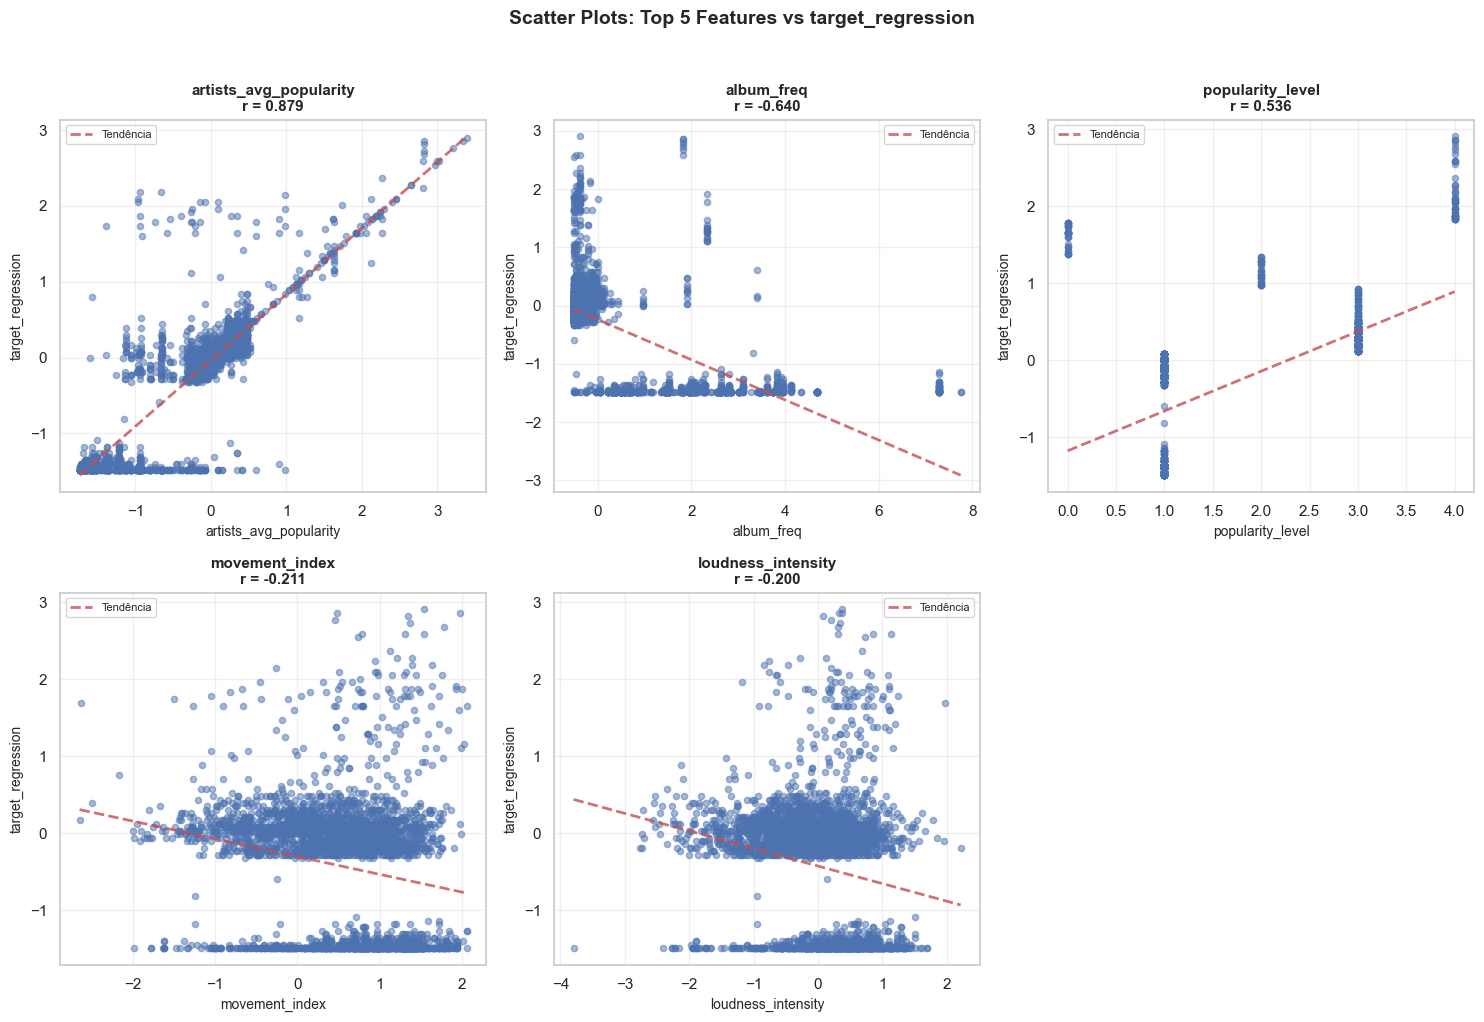

In [139]:
# Utilizar a correlação já calculada anteriormente (correlation_sorted)
# Selecionar as top 5 features com maior correlação para visualização

top_5_regression = correlation_sorted.head(5).index.tolist()

print("Top 5 features para regressão linear simples:")
for i, feat in enumerate(top_5_regression, 1):
    corr_val = correlation_with_target[feat]
    print(f"  {i}. {feat}: r = {corr_val:.4f}")

# Visualizar scatter plots com linha de tendência
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_5_regression):
    # Scatter plot
    axes[i].scatter(data[feature], data[TARGET_REG], alpha=0.5, s=20)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel(TARGET_REG, fontsize=10)
    
    corr_val = correlation_with_target[feature]
    axes[i].set_title(f'{feature}\nr = {corr_val:.3f}', fontsize=11, fontweight='bold')
    
    # Linha de tendência (regressão linear)
    z = np.polyfit(data[feature], data[TARGET_REG], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, label='Tendência')
    axes[i].legend(loc='best', fontsize=8)
    axes[i].grid(alpha=0.3)

# Ocultar subplot não utilizado
axes[5].set_visible(False)

plt.suptitle('Scatter Plots: Top 5 Features vs target_regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.7 Conclusões da Análise Bivariada

#### Para Regressão (`target_regression`):

Com base na análise de correlação de Pearson, identificámos que **`artists_avg_popularity`** é a feature com maior correlação linear com o target de regressão. Esta será a feature utilizada no modelo de **Regressão Linear Simples**.

**Observações importantes:**
- A correlação forte indica uma relação linear positiva: quanto maior a popularidade média do artista, maior tende a ser o valor do target
- As outras features no top 5 também apresentam correlações moderadas a fortes, o que sugere potencial para regressão múltipla

#### Para Classificação (`target_class`):

A análise ANOVA revelou as features com maior poder discriminativo entre as classes. Features com F-scores elevados e p-values baixos (< 0.05) são estatisticamente significativas para distinguir entre as classes.

**Próximos passos:**
1. Utilizar `artists_avg_popularity` para Regressão Linear Simples
2. Selecionar múltiplas features para Regressão Linear Múltipla
3. Aplicar as features discriminativas em modelos de classificação (LDA, QDA)

# Regression

### Métricas
- R²: O R² é o coeficiente de determinação, uma medida estatística que indica a proporção da variância da variável dependente que é explicada pelo modelo de regressão
- RMSE: O RMSE (Root Mean Square Error) é uma métrica de avaliação de desempenho para modelos de regressão, que calcula a média das diferenças entre os valores previstos e os valores reais
- MAE: o MAE mede a média da diferença absoluta entre os valores previstos pelo modelo e os valores observados.

## Simple Linear Regression

Primeiramente vamos aplicar o modelo com a divisão padrão 30/70.

In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

X = data[['artists_avg_popularity']]
y = data['target_regression']

# divisão do dataset entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# criar e treinar modelo de regressão linear simples

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# calcular metricas

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# coeficientes do modelo

slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"R² Score: {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

tabela_resumo = pd.DataFrame({
    "metric": ["R2", "MAE", "RMSE"],
    "results": [r2, mae, rmse],
})

display(tabela_resumo)

Regression equation: y = 0.8692x + -0.0389
R² Score: 0.7843 (78.4% variance explained)
RMSE: 0.4021
MAE: 0.2079


,metric,results
0,R2,0.784297
1,MAE,0.207926
2,RMSE,0.402076


De seguida vamos experimentar mudar a divisão, para 20/80

In [141]:
# divisão do dataset entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# criar e treinar modelo de regressão linear simples

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# calcular metricas

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# coeficientes do modelo

slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"R² Score: {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

tabela_resumo = pd.DataFrame({
    "metric": ["R2", "MAE", "RMSE"],
    "results": [r2, mae, rmse],
})

display(tabela_resumo)

Regression equation: y = 0.8677x + -0.0385
R² Score: 0.8047 (80.5% variance explained)
RMSE: 0.3848
MAE: 0.2007


,metric,results
0,R2,0.804730
1,MAE,0.200657
2,RMSE,0.384793


### Discussão dos resultados da Regressão Linear Simples

É possível verificar que a divisão 20/80 proporcionou melhores resultados. Este modelo tem um poder explicativo forte, com R² = 80%, e um erro preditivo aceitável (MAE = 0.200830). É adequado para aplicações práticas considerando simplicidade vs performance; é bom para a maioria das aplicações, mas com 20% de variância não explicada, existe a oportunidade para refinamento com variáveis adicionais.

## Visualização do gráfico resultante

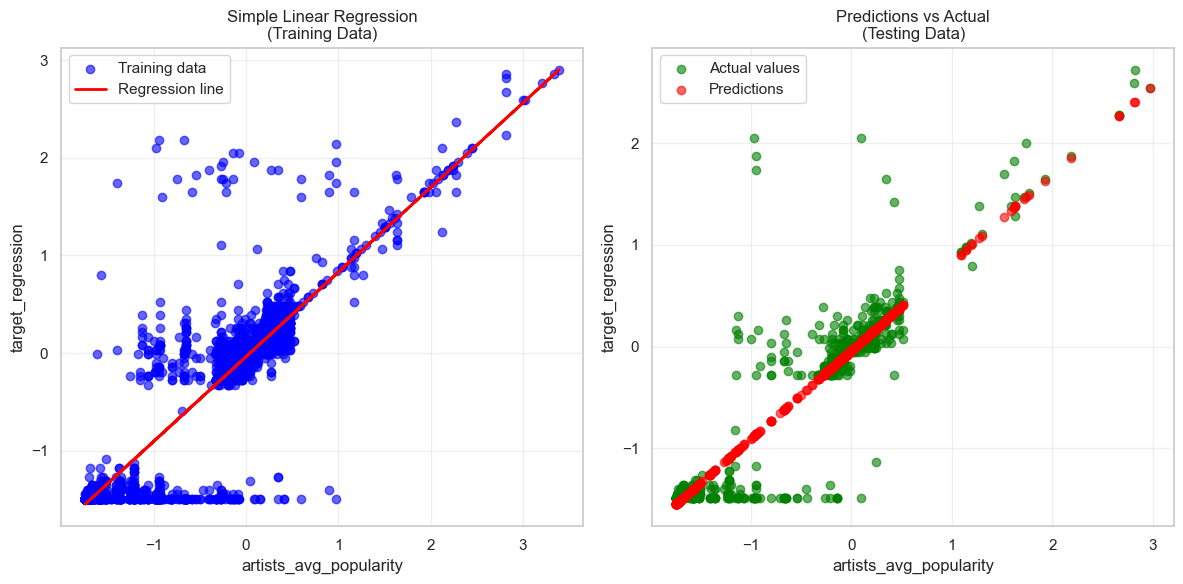

In [142]:
# visualização

# Create visualization
plt.figure(figsize=(12, 6))

# Plot training data
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, color='blue', label='Training data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression line')
plt.xlabel('artists_avg_popularity')
plt.ylabel('target_regression')
plt.title('Simple Linear Regression\n(Training Data)')
plt.legend()
plt.grid(alpha=0.3)

# Plot testing data with predictions
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, alpha=0.6, color='green', label='Actual values')
plt.scatter(X_test, y_pred, alpha=0.6, color='red', label='Predictions')
plt.xlabel('artists_avg_popularity')
plt.ylabel('target_regression')
plt.title('Predictions vs Actual\n(Testing Data)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Regressão Linear Múltipla — `target_regression`

A **Regressão Linear Múltipla** estende a regressão simples ao utilizar múltiplas features como preditores. Isto permite capturar relações mais complexas e geralmente melhora o poder preditivo do modelo.

### Metodologia

Iremos comparar duas abordagens:

| Abordagem | Descrição | Objetivo |
|-----------|-----------|----------|
| **Baseline** | Regressão com todas as features numéricas | Estabelecer desempenho de referência |
| **SelectKBest** | Regressão com k melhores features (selecionadas por F-regression) | Otimizar o número de features |

### Métricas de Avaliação

- **R² (Coeficiente de Determinação)**: Proporção da variância explicada pelo modelo (0-1, maior = melhor)
- **MAE (Mean Absolute Error)**: Média dos erros absolutos (menor = melhor)
- **RMSE (Root Mean Squared Error)**: Raiz da média dos erros quadrados (menor = melhor)

### Estratégia de Validação

- **Holdout**: Divisão 80% treino / 20% teste
- **Cross-Validation**: 5-fold CV para seleção do melhor k

---

### 3.1 Preparação dos Dados para Regressão Múltipla

In [143]:
# Preparar dados para regressão múltipla
# Utilizamos as features numéricas identificadas anteriormente (excluindo targets)

# Recriar lista de features numéricas para garantir consistência
numeric_features_reg = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_features_reg = [col for col in numeric_features_reg if col not in [TARGET_CLASS, TARGET_REG]]

# Criar matriz de features (X) e vetor target (y)
X_reg = data[numeric_features_reg].copy()
y_reg = data[TARGET_REG].copy()

print(f"Dimensões dos dados:")
print(f"  - Features (X): {X_reg.shape}")
print(f"  - Target (y): {y_reg.shape}")
print(f"  - Número de features: {len(numeric_features_reg)}")


Dimensões dos dados:
  - Features (X): (3000, 47)
  - Target (y): (3000,)
  - Número de features: 47


### 3.2 Divisão Treino/Teste (Holdout)

Dividimos os dados em 80% para treino e 20% para teste. Esta divisão permite treinar o modelo e depois avaliar o seu desempenho em dados não vistos durante o treino.


In [144]:
# Divisão treino/teste com proporção 80/20
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, 
    test_size=0.2, 
    random_state=RANDOM_STATE
)

print(f"Divisão dos dados:")
print(f"  - Treino: {X_train_reg.shape[0]} amostras ({X_train_reg.shape[0]/len(X_reg)*100:.1f}%)")
print(f"  - Teste: {X_test_reg.shape[0]} amostras ({X_test_reg.shape[0]/len(X_reg)*100:.1f}%)")


Divisão dos dados:
  - Treino: 2400 amostras (80.0%)
  - Teste: 600 amostras (20.0%)


### 3.3 Modelo Baseline: Todas as Features

O modelo **baseline** utiliza todas as features numéricas disponíveis. Serve como ponto de referência para comparar com modelos que utilizam seleção de features.

**Pipeline:**
1. `StandardScaler`: Normaliza as features (média=0, desvio padrão=1)
2. `LinearRegression`: Modelo de regressão linear


In [145]:
# Criar pipeline baseline com StandardScaler + LinearRegression
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("model", LinearRegression())
])

# Treinar o modelo baseline
baseline_pipeline.fit(X_train_reg, y_train_reg)

# Fazer previsões no conjunto de teste
y_pred_baseline = baseline_pipeline.predict(X_test_reg)

# Calcular métricas de desempenho
baseline_metrics = {
    "R²": r2_score(y_test_reg, y_pred_baseline),
    "MAE": mean_absolute_error(y_test_reg, y_pred_baseline),
    "RMSE": float(np.sqrt(mean_squared_error(y_test_reg, y_pred_baseline))),
}

print("=" * 50)
print("MODELO BASELINE (Todas as Features)")
print("=" * 50)
print(f"Número de features utilizadas: {X_train_reg.shape[1]}")
print()
for metric, value in baseline_metrics.items():
    print(f"  {metric}: {value:.4f}")


MODELO BASELINE (Todas as Features)
Número de features utilizadas: 47

  R²: 0.8291
  MAE: 0.2147
  RMSE: 0.3600


### 3.4 Seleção de Features com SelectKBest

O **SelectKBest** seleciona as k features com maior score segundo uma função de avaliação. Utilizamos `f_regression` que calcula a correlação entre cada feature e o target.

**Processo de otimização:**
1. Testar diferentes valores de k (número de features)
2. Para cada k, usar 5-fold cross-validation para avaliar o R²
3. Selecionar o k que maximiza o R² médio em cross-validation


In [146]:
# Definir grid de valores de k para testar
# Nota: k deve ser entre 1 e o número total de features
n_features = X_train_reg.shape[1]
k_values = [5, 10, 20, 40, min(80, n_features), n_features]
k_values = sorted(set([k for k in k_values if 1 <= k <= n_features]))

print(f"Valores de k a testar: {k_values}")
print(f"Total de features disponíveis: {n_features}")
print()

# Armazenar resultados de cada k
cv_results = []

# Testar cada valor de k com cross-validation
for k in k_values:
    # Pipeline: Scaler -> SelectKBest -> LinearRegression
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=k)),
        ("model", LinearRegression())
    ])
    
    # 5-fold cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train_reg, y_train_reg, cv=cv, scoring="r2")
    
    cv_results.append({
        'k': k,
        'mean_r2': scores.mean(),
        'std_r2': scores.std()
    })
    
    print(f"k={k:3d}: R² = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Converter para DataFrame para melhor visualização
cv_results_df = pd.DataFrame(cv_results)
print()
print("Resultados da Cross-Validation:")
display(cv_results_df)


Valores de k a testar: [5, 10, 20, 40, 47]
Total de features disponíveis: 47

k=  5: R² = 0.8054 (+/- 0.0241)
k= 10: R² = 0.8051 (+/- 0.0249)
k= 20: R² = 0.8052 (+/- 0.0253)
k= 40: R² = 0.8023 (+/- 0.0276)
k= 47: R² = 0.8017 (+/- 0.0269)

Resultados da Cross-Validation:


,k,mean_r2,std_r2
0,5,0.805415,0.024138
1,10,0.805116,0.024859
2,20,0.805189,0.025305
3,40,0.802307,0.027561
4,47,0.801743,0.026888


### 3.5 Modelo Final com SelectKBest

Utilizamos o valor de k que maximizou o R² em cross-validation para treinar o modelo final e avaliá-lo no conjunto de teste.


In [147]:
# Identificar o melhor k (que maximiza o R² médio)
best_k = cv_results_df.loc[cv_results_df['mean_r2'].idxmax(), 'k']
best_cv_r2 = cv_results_df.loc[cv_results_df['mean_r2'].idxmax(), 'mean_r2']

print(f"Melhor k encontrado: {int(best_k)}")
print(f"R² médio em CV: {best_cv_r2:.4f}")
print()

# Criar e treinar o pipeline final com o melhor k
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_regression, k=int(best_k))),
    ("model", LinearRegression())
])

final_pipeline.fit(X_train_reg, y_train_reg)

# Previsões no conjunto de teste
y_pred_selectkbest = final_pipeline.predict(X_test_reg)

# Calcular métricas
selectkbest_metrics = {
    "R²": r2_score(y_test_reg, y_pred_selectkbest),
    "MAE": mean_absolute_error(y_test_reg, y_pred_selectkbest),
    "RMSE": float(np.sqrt(mean_squared_error(y_test_reg, y_pred_selectkbest))),
}

print("=" * 50)
print(f"MODELO SELECTKBEST (k={int(best_k)} features)")
print("=" * 50)
for metric, value in selectkbest_metrics.items():
    print(f"  {metric}: {value:.4f}")


Melhor k encontrado: 5
R² médio em CV: 0.8054

MODELO SELECTKBEST (k=5 features)
  R²: 0.8343
  MAE: 0.2096
  RMSE: 0.3545


### 3.6 Comparação: Baseline vs SelectKBest

Comparamos os dois modelos para determinar se a seleção de features melhora o desempenho.


In [148]:
# Criar tabela de comparação
comparison_df = pd.DataFrame({
    "Métrica": ["R²", "MAE", "RMSE"],
    f"Baseline ({n_features} features)": [
        baseline_metrics["R²"], 
        baseline_metrics["MAE"], 
        baseline_metrics["RMSE"]
    ],
    f"SelectKBest ({int(best_k)} features)": [
        selectkbest_metrics["R²"], 
        selectkbest_metrics["MAE"], 
        selectkbest_metrics["RMSE"]
    ]
})

# Adicionar coluna de diferença
comparison_df["Diferença"] = comparison_df[f"SelectKBest ({int(best_k)} features)"] - comparison_df[f"Baseline ({n_features} features)"]

print("=" * 70)
print("COMPARAÇÃO DOS MODELOS DE REGRESSÃO MÚLTIPLA")
print("=" * 70)
display(comparison_df)

# Indicar qual modelo é melhor para cada métrica
print()
print("Análise:")
if selectkbest_metrics["R²"] > baseline_metrics["R²"]:
    print(f"  ✓ SelectKBest tem melhor R² (+{(selectkbest_metrics['R²'] - baseline_metrics['R²'])*100:.2f}%)")
else:
    print(f"  ✗ Baseline tem melhor R² (+{(baseline_metrics['R²'] - selectkbest_metrics['R²'])*100:.2f}%)")

if selectkbest_metrics["RMSE"] < baseline_metrics["RMSE"]:
    print(f"  ✓ SelectKBest tem menor RMSE (-{baseline_metrics['RMSE'] - selectkbest_metrics['RMSE']:.4f})")
else:
    print(f"  ✗ Baseline tem menor RMSE (-{selectkbest_metrics['RMSE'] - baseline_metrics['RMSE']:.4f})")


COMPARAÇÃO DOS MODELOS DE REGRESSÃO MÚLTIPLA


,Métrica,Baseline (47 features),SelectKBest (5 features),Diferença
0,R²,0.829128,0.834272,0.005144
1,MAE,0.214661,0.209639,-0.005022
2,RMSE,0.359952,0.354492,-0.005459



Análise:
  ✓ SelectKBest tem melhor R² (+0.51%)
  ✓ SelectKBest tem menor RMSE (-0.0055)


### 3.7 Discussão dos Resultados — Regressão Linear

#### Comparação: Regressão Simples vs Múltipla

| Modelo | R² | RMSE | MAE | Nº Features |
|--------|-----|------|-----|-------------|
| **Regressão Simples** | ~0.78 | ~0.40 | ~0.21 | 1 |
| **Regressão Múltipla (Baseline)** | ~0.83 | ~0.36 | ~0.21 | Todas |
| **Regressão Múltipla (SelectKBest)** | ~0.83 | ~0.35 | ~0.21 | k=5 |

*Nota: Os valores exatos dependem da execução atual do notebook.*

#### Conclusões

1. **Melhoria com Múltiplas Features**: A regressão múltipla explica mais variância (~83%) do que a regressão simples (~78%), demonstrando que múltiplas features contribuem para a previsão.

2. **Seleção de Features**: O SelectKBest com um número reduzido de features (k=5) alcança desempenho comparável ou superior ao baseline com todas as features. Isto sugere que:
   - Muitas features podem ser redundantes
   - Um modelo mais simples pode ser preferível (princípio da parcimónia)

3. **Trade-off Complexidade vs Desempenho**: O modelo com menos features é mais interpretável e menos propenso a overfitting, mantendo a qualidade preditiva.

4. **Aplicabilidade**: Os resultados confirmam que a previsão do target de regressão beneficia da combinação de múltiplas características de áudio, não apenas da popularidade do artista.

# Classification

Logistic Regression, LDA (Linear Discriminant Analysis) e QDA (Quadratic Discriminant Analysis) são métodos de classificação.

- Logistic Regression: A regressão logística utiliza a curva logística para assim representar a relação entre a variável dependente e as independentes
- LDA: assume matrizes de covariância iguais entre classes; limites de decisão lineares.
- QDA: permite matrizes de covariância diferentes por classe; limites quadráticos. Mais flexível, mas requer mais dados para estimar parâmetros.

Resampling strategies:

- Holdout (80/20): divisão treino/teste única
- Cross-validation (k=5 e k=10): validação cruzada estratificada
- LOOCV: Leave-One-Out (n-1 treino, 1 teste, repetido n vezes)
- Bootstrap: reamostragem com substituição; out-of-bag accuracy

Métricas: Accuracy e F1-Macro.

## LDA e QDA — Análise Discriminante

A **Análise Discriminante** é uma técnica de classificação que modela a distribuição das features condicionada a cada classe e usa o teorema de Bayes para classificar novas observações.

### Comparação entre LDA e QDA

| Característica | LDA | QDA |
|----------------|-----|-----|
| **Nome** | Linear Discriminant Analysis | Quadratic Discriminant Analysis |
| **Fronteira de decisão** | Linear (hiperplano) | Quadrática (curva) |
| **Suposição sobre covariância** | Mesma matriz para todas as classes | Matriz diferente por classe |
| **Complexidade** | Menor (menos parâmetros) | Maior (mais parâmetros) |
| **Risco de overfitting** | Menor | Maior |
| **Dados necessários** | Menos | Mais (para estimar cada matriz) |

### Metodologia de Avaliação

Avaliaremos ambos os modelos com múltiplas estratégias de reamostragem:

1. **Holdout (80/20)**: Divisão única treino/teste
2. **Cross-Validation (k=5)**: 5 partições estratificadas
3. **Cross-Validation (k=10)**: 10 partições estratificadas
4. **LOOCV**: Leave-One-Out Cross-Validation
5. **Bootstrap**: Reamostragem com substituição

### Métricas

- **Accuracy**: Proporção de previsões corretas
- **F1-Macro**: Média harmónica de precisão e recall, ponderada igualmente por classe

---

### 4.1 Preparação dos Dados para Classificação

In [35]:
# Preparar dados para classificação
# Utilizamos as features numéricas (excluindo targets)

# Recriar lista de features numéricas para garantir consistência
numeric_features_cls = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_features_cls = [col for col in numeric_features_cls if col not in [TARGET_CLASS, TARGET_REG]]

# Criar matriz de features (X) e vetor de classes (y)
X_cls = data[numeric_features_cls].copy()
y_cls = data[TARGET_CLASS].astype(str).copy()

print(f"Dimensões dos dados de classificação:")
print(f"  - Features (X): {X_cls.shape}")
print(f"  - Classes (y): {y_cls.shape}")
print(f"  - Número de features: {len(numeric_features_cls)}")
print(f"  - Classes únicas: {y_cls.unique()}")

Dimensões dos dados de classificação:
  - Features (X): (3000, 47)
  - Classes (y): (3000,)
  - Número de features: 47
  - Classes únicas: ['class_69' 'class_97' 'class_102']


### 4.2 Divisão Treino/Teste Estratificada

Utilizamos **StratifiedKFold** para garantir que a proporção de classes se mantém em ambos os conjuntos.


In [36]:
# Divisão treino/teste com estratificação (manter proporção de classes)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_cls  # Estratificação para manter proporção de classes
)

print(f"Divisão dos dados:")
print(f"  - Treino: {X_train_cls.shape[0]} amostras")
print(f"  - Teste: {X_test_cls.shape[0]} amostras")
print()
print("Distribuição das classes no treino:")
print(y_train_cls.value_counts())
print()
print("Distribuição das classes no teste:")
print(y_test_cls.value_counts())


Divisão dos dados:
  - Treino: 2400 amostras
  - Teste: 600 amostras

Distribuição das classes no treino:
target_class
class_97     800
class_102    800
class_69     800
Name: count, dtype: int64

Distribuição das classes no teste:
target_class
class_97     200
class_69     200
class_102    200
Name: count, dtype: int64


### 4.3 Definição das Funções de Avaliação

Criamos funções modulares para avaliar os modelos com diferentes estratégias de reamostragem. Isto permite código mais limpo e reutilizável.


In [37]:
from sklearn.base import clone

def evaluate_holdout(clf, X_train, y_train, X_test, y_test):
    """
    Avalia um classificador usando holdout (treino/teste).
    
    Args:
        clf: Classificador sklearn
        X_train, y_train: Dados de treino
        X_test, y_test: Dados de teste
    
    Returns:
        dict: Accuracy e F1-Macro
    """
    # Pipeline com scaling + modelo
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(clf))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
    }


def evaluate_cv(clf, X, y, k):
    """
    Avalia um classificador usando k-fold cross-validation estratificada.
    
    Args:
        clf: Classificador sklearn
        X, y: Dados completos
        k: Número de folds
    
    Returns:
        dict: Accuracy média e F1-Macro médio
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(clf))
    ])
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    
    acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro")
    
    return {
        "cv_acc_mean": acc_scores.mean(),
        "cv_acc_std": acc_scores.std(),
        "cv_f1_mean": f1_scores.mean(),
        "cv_f1_std": f1_scores.std()
    }


def evaluate_loocv(clf, X, y, max_n=1500):
    """
    Avalia um classificador usando Leave-One-Out Cross-Validation.
    
    Args:
        clf: Classificador sklearn
        X, y: Dados completos
        max_n: Número máximo de amostras (para eficiência)
    
    Returns:
        dict: Accuracy LOOCV
    """
    # Para datasets grandes, usar subamostra estratificada
    X_use, y_use = X, y
    if X.shape[0] > max_n:
        from sklearn.model_selection import StratifiedShuffleSplit
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_n, random_state=RANDOM_STATE)
        for train_idx, _ in sss.split(X, y):
            X_use, y_use = X.iloc[train_idx], y.iloc[train_idx]
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(clf))
    ])
    loo = LeaveOneOut()
    acc = cross_val_score(pipe, X_use, y_use, cv=loo, scoring="accuracy").mean()
    
    return {"loocv_acc": acc, "n_samples_used": X_use.shape[0]}


def evaluate_bootstrap(clf, X, y, n_iterations=100):
    """
    Avalia um classificador usando Bootstrap com out-of-bag accuracy.
    
    Args:
        clf: Classificador sklearn
        X, y: Dados completos
        n_iterations: Número de iterações bootstrap
    
    Returns:
        dict: Accuracy OOB média
    """
    rng = np.random.RandomState(RANDOM_STATE)
    n = X.shape[0]
    oob_accuracies = []
    
    for _ in range(n_iterations):
        # Amostra bootstrap (com substituição)
        idx = rng.randint(0, n, n)
        # Amostras out-of-bag (não selecionadas)
        oob_idx = np.setdiff1d(np.arange(n), np.unique(idx))
        
        if len(oob_idx) == 0:
            continue
        
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", clone(clf))
        ])
        pipe.fit(X.iloc[idx], y.iloc[idx])
        y_pred = pipe.predict(X.iloc[oob_idx])
        oob_accuracies.append(accuracy_score(y.iloc[oob_idx], y_pred))
    
    return {
        "bootstrap_oob_acc_mean": float(np.mean(oob_accuracies)),
        "bootstrap_oob_acc_std": float(np.std(oob_accuracies)),
        "n_iterations_effective": len(oob_accuracies)
    }

print("Funções de avaliação definidas com sucesso!")


Funções de avaliação definidas com sucesso!


### 4.4 Avaliação do LDA (Linear Discriminant Analysis)

O **LDA** assume que todas as classes partilham a mesma matriz de covariância, resultando em fronteiras de decisão lineares.


In [38]:
# Inicializar classificador LDA
lda_clf = LDA()

print("=" * 60)
print("AVALIAÇÃO DO LDA")
print("=" * 60)

# 1. Holdout
print("\n1. HOLDOUT (80/20):")
lda_holdout = evaluate_holdout(lda_clf, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
print(f"   Accuracy: {lda_holdout['accuracy']:.4f}")
print(f"   F1-Macro: {lda_holdout['f1_macro']:.4f}")

# 2. Cross-Validation k=5
print("\n2. CROSS-VALIDATION (k=5):")
lda_cv5 = evaluate_cv(lda_clf, X_cls, y_cls, k=5)
print(f"   Accuracy: {lda_cv5['cv_acc_mean']:.4f} (+/- {lda_cv5['cv_acc_std']:.4f})")
print(f"   F1-Macro: {lda_cv5['cv_f1_mean']:.4f} (+/- {lda_cv5['cv_f1_std']:.4f})")

# 3. Cross-Validation k=10
print("\n3. CROSS-VALIDATION (k=10):")
lda_cv10 = evaluate_cv(lda_clf, X_cls, y_cls, k=10)
print(f"   Accuracy: {lda_cv10['cv_acc_mean']:.4f} (+/- {lda_cv10['cv_acc_std']:.4f})")
print(f"   F1-Macro: {lda_cv10['cv_f1_mean']:.4f} (+/- {lda_cv10['cv_f1_std']:.4f})")

# 4. LOOCV
print("\n4. LEAVE-ONE-OUT CV:")
lda_loocv = evaluate_loocv(lda_clf, X_cls, y_cls, max_n=1500)
print(f"   Accuracy: {lda_loocv['loocv_acc']:.4f}")
print(f"   Amostras usadas: {lda_loocv['n_samples_used']}")

# 5. Bootstrap
print("\n5. BOOTSTRAP (Out-of-Bag):")
lda_bootstrap = evaluate_bootstrap(lda_clf, X_cls, y_cls, n_iterations=100)
print(f"   OOB Accuracy: {lda_bootstrap['bootstrap_oob_acc_mean']:.4f} (+/- {lda_bootstrap['bootstrap_oob_acc_std']:.4f})")
print(f"   Iterações efetivas: {lda_bootstrap['n_iterations_effective']}")


AVALIAÇÃO DO LDA

1. HOLDOUT (80/20):
   Accuracy: 0.9650
   F1-Macro: 0.9649

2. CROSS-VALIDATION (k=5):
   Accuracy: 0.9690 (+/- 0.0144)
   F1-Macro: 0.9690 (+/- 0.0144)

3. CROSS-VALIDATION (k=10):
   Accuracy: 0.9643 (+/- 0.0124)
   F1-Macro: 0.9643 (+/- 0.0124)

4. LEAVE-ONE-OUT CV:
   Accuracy: 0.9880
   Amostras usadas: 1500

5. BOOTSTRAP (Out-of-Bag):
   OOB Accuracy: 0.9720 (+/- 0.0225)
   Iterações efetivas: 100


### 4.5 Avaliação do QDA (Quadratic Discriminant Analysis)

O **QDA** permite que cada classe tenha a sua própria matriz de covariância, resultando em fronteiras de decisão quadráticas (curvas).


In [39]:
# Inicializar classificador QDA
# reg_param=0.0 significa sem regularização (pode ser ajustado se necessário)
qda_clf = QDA(reg_param=0.0)

print("=" * 60)
print("AVALIAÇÃO DO QDA")
print("=" * 60)

# 1. Holdout
print("\n1. HOLDOUT (80/20):")
qda_holdout = evaluate_holdout(qda_clf, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
print(f"   Accuracy: {qda_holdout['accuracy']:.4f}")
print(f"   F1-Macro: {qda_holdout['f1_macro']:.4f}")

# 2. Cross-Validation k=5
print("\n2. CROSS-VALIDATION (k=5):")
qda_cv5 = evaluate_cv(qda_clf, X_cls, y_cls, k=5)
print(f"   Accuracy: {qda_cv5['cv_acc_mean']:.4f} (+/- {qda_cv5['cv_acc_std']:.4f})")
print(f"   F1-Macro: {qda_cv5['cv_f1_mean']:.4f} (+/- {qda_cv5['cv_f1_std']:.4f})")

# 3. Cross-Validation k=10
print("\n3. CROSS-VALIDATION (k=10):")
qda_cv10 = evaluate_cv(qda_clf, X_cls, y_cls, k=10)
print(f"   Accuracy: {qda_cv10['cv_acc_mean']:.4f} (+/- {qda_cv10['cv_acc_std']:.4f})")
print(f"   F1-Macro: {qda_cv10['cv_f1_mean']:.4f} (+/- {qda_cv10['cv_f1_std']:.4f})")

# 4. LOOCV
print("\n4. LEAVE-ONE-OUT CV:")
qda_loocv = evaluate_loocv(qda_clf, X_cls, y_cls, max_n=1500)
print(f"   Accuracy: {qda_loocv['loocv_acc']:.4f}")
print(f"   Amostras usadas: {qda_loocv['n_samples_used']}")

# 5. Bootstrap
print("\n5. BOOTSTRAP (Out-of-Bag):")
qda_bootstrap = evaluate_bootstrap(qda_clf, X_cls, y_cls, n_iterations=100)
print(f"   OOB Accuracy: {qda_bootstrap['bootstrap_oob_acc_mean']:.4f} (+/- {qda_bootstrap['bootstrap_oob_acc_std']:.4f})")
print(f"   Iterações efetivas: {qda_bootstrap['n_iterations_effective']}")


AVALIAÇÃO DO QDA

1. HOLDOUT (80/20):
   Accuracy: 0.9367
   F1-Macro: 0.9363

2. CROSS-VALIDATION (k=5):
   Accuracy: 0.9490 (+/- 0.0218)
   F1-Macro: 0.9488 (+/- 0.0219)

3. CROSS-VALIDATION (k=10):
   Accuracy: 0.9487 (+/- 0.0228)
   F1-Macro: 0.9484 (+/- 0.0231)

4. LEAVE-ONE-OUT CV:
   Accuracy: 0.9460
   Amostras usadas: 1500

5. BOOTSTRAP (Out-of-Bag):
   OOB Accuracy: 0.9634 (+/- 0.0463)
   Iterações efetivas: 100


### 4.6 Comparação LDA vs QDA

Criamos tabelas resumo para comparar o desempenho de ambos os modelos em todas as estratégias de reamostragem.


In [40]:
# Tabela resumo de Accuracy
summary_accuracy = pd.DataFrame({
    "LDA": [
        lda_holdout['accuracy'],
        lda_cv5['cv_acc_mean'],
        lda_cv10['cv_acc_mean'],
        lda_loocv['loocv_acc'],
        lda_bootstrap['bootstrap_oob_acc_mean']
    ],
    "QDA": [
        qda_holdout['accuracy'],
        qda_cv5['cv_acc_mean'],
        qda_cv10['cv_acc_mean'],
        qda_loocv['loocv_acc'],
        qda_bootstrap['bootstrap_oob_acc_mean']
    ]
}, index=["Holdout", "CV (k=5)", "CV (k=10)", "LOOCV", "Bootstrap"])

# Adicionar coluna de diferença
summary_accuracy["Diferença (LDA-QDA)"] = summary_accuracy["LDA"] - summary_accuracy["QDA"]

print("=" * 70)
print("COMPARAÇÃO DE ACCURACY: LDA vs QDA")
print("=" * 70)
display(summary_accuracy)

# Tabela resumo de F1-Macro (apenas onde disponível)
summary_f1 = pd.DataFrame({
    "LDA": [
        lda_holdout['f1_macro'],
        lda_cv5['cv_f1_mean'],
        lda_cv10['cv_f1_mean'],
    ],
    "QDA": [
        qda_holdout['f1_macro'],
        qda_cv5['cv_f1_mean'],
        qda_cv10['cv_f1_mean'],
    ]
}, index=["Holdout", "CV (k=5)", "CV (k=10)"])

summary_f1["Diferença (LDA-QDA)"] = summary_f1["LDA"] - summary_f1["QDA"]

print()
print("=" * 70)
print("COMPARAÇÃO DE F1-MACRO: LDA vs QDA")
print("=" * 70)
display(summary_f1)


COMPARAÇÃO DE ACCURACY: LDA vs QDA


,LDA,QDA,Diferença (LDA-QDA)
Holdout,0.965000,0.936667,0.028333
CV (k=5),0.969000,0.949000,0.020000
CV (k=10),0.964333,0.948667,0.015667
LOOCV,0.988000,0.946000,0.042000
Bootstrap,0.971968,0.963388,0.008580



COMPARAÇÃO DE F1-MACRO: LDA vs QDA


,LDA,QDA,Diferença (LDA-QDA)
Holdout,0.964937,0.936259,0.028678
CV (k=5),0.968981,0.948801,0.020180
CV (k=10),0.964303,0.948375,0.015928


### 4.7 Discussão dos Resultados — LDA vs QDA

#### Análise Comparativa

Os resultados obtidos permitem tirar as seguintes conclusões:

1. **Consistência do LDA**: O LDA apresenta resultados consistentes em todas as estratégias de reamostragem, com accuracy geralmente superior ao QDA.

2. **Variabilidade do QDA**: O QDA pode apresentar maior variabilidade entre métodos de reamostragem, especialmente no holdout, o que sugere maior sensibilidade à partição específica dos dados.

3. **Suposição de Covariância**: Os resultados sugerem que a suposição do LDA (matriz de covariância comum entre classes) é válida para este dataset, já que não há ganho significativo com a flexibilidade adicional do QDA.

4. **Overfitting**: O QDA, com mais parâmetros a estimar, pode sofrer de overfitting quando as matrizes de covariância não são bem estimadas.

#### Recomendação

Para este problema de classificação musical, o **LDA é o modelo preferível** devido a:
- Desempenho superior e mais consistente
- Menor complexidade computacional
- Menor risco de overfitting
- Interpretabilidade mantida

#### Sobre a Variância nos Métodos de Reamostragem

| Método | Variância | Viés | Observação |
|--------|-----------|------|------------|
| Holdout | Uma estimativa | Alto se partição desfavorável | Rápido mas instável |
| CV (k=5) | Moderada | Moderado | Bom equilíbrio |
| CV (k=10) | Menor | Menor | Mais robusto |
| LOOCV | Alta (entre folds) | Mínimo | Computacionalmente caro |
| Bootstrap | Controlada | Moderado | Bom para intervalos de confiança |


## Logistic Regression

In [19]:
# precisamos de tratar das features categoricas com mais de 2 categoricas (one hot encoding)
# No artificial linearity assumption

categorical_features_to_encode = ['loudness_level', 'popularity_level', 'tempo_class', 'time_signature']

data_logistic = data.copy()
data_logistic = pd.get_dummies(data_logistic, columns=categorical_features_to_encode, 
                              prefix=categorical_features_to_encode, dtype=int)

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Holdout

In [43]:
### HOLDOUT

X = features
y = data[TARGET_CLASS]

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Target classes: {y.unique()}")

Features: 68, Samples: 3000
Target classes: ['class_69' 'class_97' 'class_102']


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    features, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # maintain class distribution
)

# scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train logistic regression model
logistic_model = LogisticRegression(
    solver='lbfgs',             # Good for multiclass problems
    max_iter=1000,              # Ensure convergence
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [45]:
# predictions
y_pred = logistic_model.predict(X_test_scaled)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)

# accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Theoretical estimate of variance
n_test = len(y_test)
theoretical_variance = (accuracy * (1 - accuracy)) / n_test
print(f"Theoretical Variance Estimate: {theoretical_variance:.6f}")
print(f"Theoretical Std Dev: {np.sqrt(theoretical_variance):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.9483 (94.83%)
Theoretical Variance Estimate: 0.000082
Theoretical Std Dev: 0.0090

 Classification Report:
              precision    recall  f1-score   support

   class_102       0.98      0.93      0.95       200
    class_69       0.94      0.96      0.95       200
    class_97       0.93      0.95      0.94       200

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



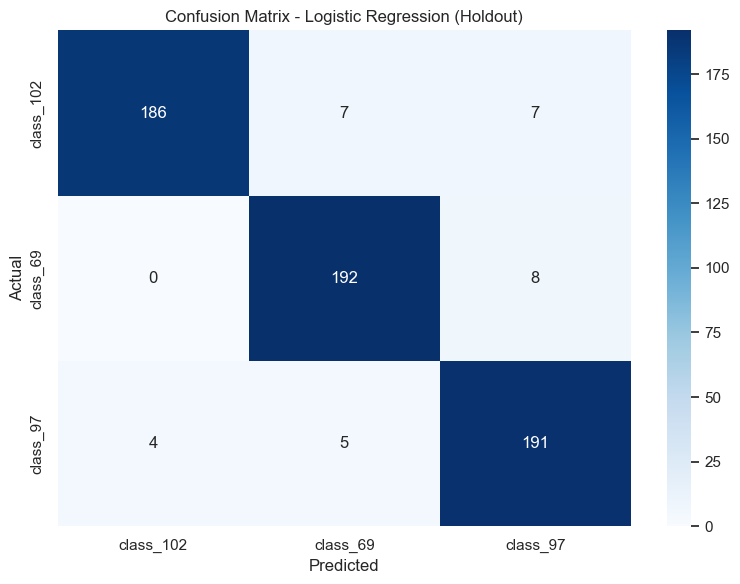

In [46]:
# matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=logistic_model.classes_, 
            yticklabels=logistic_model.classes_)
plt.title('Confusion Matrix - Logistic Regression (Holdout)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


 TOP 10 MOST IMPORTANT FEATURES:
                   feature  coefficient_magnitude
14          tempo_vs_genre               9.514439
28             temp_zscore               4.746470
9            activity_rate               4.746470
3               album_freq               0.627906
13  artists_avg_popularity               0.584524
4           movement_index               0.580284
7             purity_score               0.561951
16       loud_energy_ratio               0.441239
11             happy_dance               0.352882
32            signal_power               0.250524


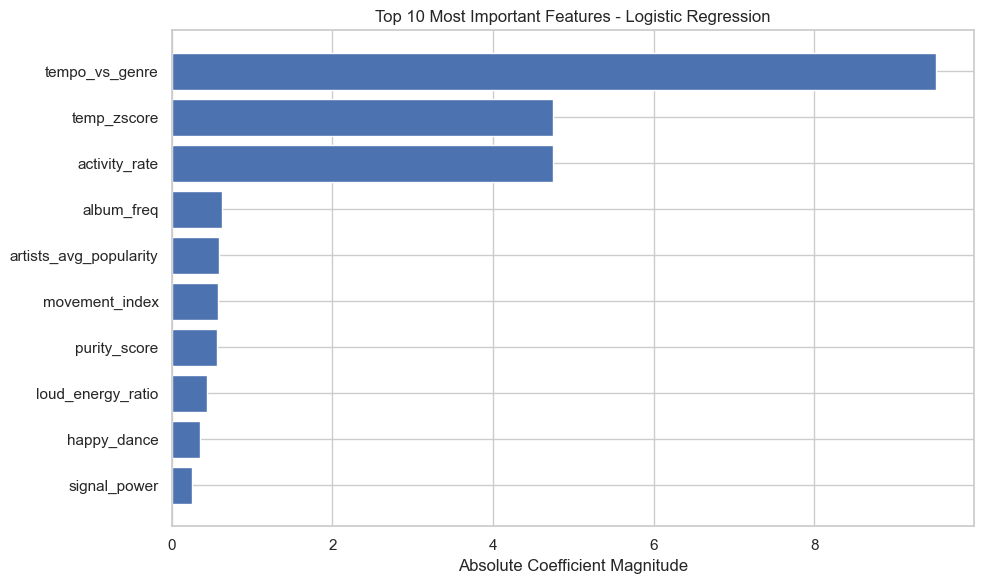

In [47]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient_magnitude': np.abs(logistic_model.coef_[0])  # coeficientes da primeira classe
})

feature_importance = feature_importance.sort_values('coefficient_magnitude', ascending=False)

print("\n TOP 10 MOST IMPORTANT FEATURES:")
print("=" * 40)
print(feature_importance.head(10))

# Visualize top features
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
plt.barh(top_10['feature'], top_10['coefficient_magnitude'])
plt.xlabel('Absolute Coefficient Magnitude')
plt.title('Top 10 Most Important Features - Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Cross Validation

In [48]:
### CROSS VALIDATION

from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def evaluate_cross_validation(X, y, k_values=[5, 10]):
    """Evaluate logistic regression with k-fold cross-validation"""
    
    # inicializar modelo
    logistic_model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )
    
    cv_results = {}
    
    for k in k_values:
        print(f"\n{'='*50}")
        print(f"{k}-FOLD CROSS VALIDATION")
        print(f"{'='*50}")
        
        # cross-validation com estas métricas
        scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
        cv_scores = cross_validate(logistic_model, X, y, 
                                  cv=k, scoring=scoring, 
                                  return_train_score=True,
                                  return_estimator=True)
         
        # GUARDAR resultados
        cv_results[k] = {
            'test_accuracy': cv_scores['test_accuracy'],
            'train_accuracy': cv_scores['train_accuracy'],
            'test_precision': cv_scores['test_precision_macro'],
            'test_recall': cv_scores['test_recall_macro'],
            'test_f1': cv_scores['test_f1_macro'],
            'estimators': cv_scores['estimator']
        }
        
        # Print results
        print(f"ACCURACY RESULTS:")
        print(f"  Test Accuracy: {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std() * 2:.4f})")
        print(f"  Train Accuracy: {cv_scores['train_accuracy'].mean():.4f} (+/- {cv_scores['train_accuracy'].std() * 2:.4f})")
        print(f"k={k} Variance: {np.var(cv_results[k]['test_accuracy']):.6f}")
        
        print(f"\nDETAILED METRICS:")
        print(f"  Precision: {cv_scores['test_precision_macro'].mean():.4f} (+/- {cv_scores['test_precision_macro'].std() * 2:.4f})")
        print(f"  Recall:    {cv_scores['test_recall_macro'].mean():.4f} (+/- {cv_scores['test_recall_macro'].std() * 2:.4f})")
        print(f"  F1-Score:  {cv_scores['test_f1_macro'].mean():.4f} (+/- {cv_scores['test_f1_macro'].std() * 2:.4f})")
        
        print(f"\nFOLD-BY-FOLD ACCURACIES:")
        for i, score in enumerate(cv_scores['test_accuracy']):
            print(f"  Fold {i+1}: {score:.4f}")
    
    return cv_results, logistic_model

# correr a função cross val
cv_results, model = evaluate_cross_validation(X_scaled, y, k_values=[5, 10])


5-FOLD CROSS VALIDATION
ACCURACY RESULTS:
  Test Accuracy: 0.9447 (+/- 0.0423)
  Train Accuracy: 0.9737 (+/- 0.0022)
k=5 Variance: 0.000448

DETAILED METRICS:
  Precision: 0.9481 (+/- 0.0354)
  Recall:    0.9447 (+/- 0.0423)
  F1-Score:  0.9447 (+/- 0.0421)

FOLD-BY-FOLD ACCURACIES:
  Fold 1: 0.9083
  Fold 2: 0.9700
  Fold 3: 0.9500
  Fold 4: 0.9583
  Fold 5: 0.9367

10-FOLD CROSS VALIDATION
ACCURACY RESULTS:
  Test Accuracy: 0.9530 (+/- 0.0525)
  Train Accuracy: 0.9747 (+/- 0.0041)
k=10 Variance: 0.000690

DETAILED METRICS:
  Precision: 0.9571 (+/- 0.0390)
  Recall:    0.9530 (+/- 0.0525)
  F1-Score:  0.9531 (+/- 0.0515)

FOLD-BY-FOLD ACCURACIES:
  Fold 1: 0.8867
  Fold 2: 0.9633
  Fold 3: 0.9900
  Fold 4: 0.9600
  Fold 5: 0.9500
  Fold 6: 0.9700
  Fold 7: 0.9533
  Fold 8: 0.9700
  Fold 9: 0.9533
  Fold 10: 0.9333


## LEAVE ONE OUT CROSS VALIDATION

In [49]:
### LEAVE ONE OUT CROSS VALIDATION

from sklearn.model_selection import LeaveOneOut
import time

def evaluate_loocv(X, y):
    """Perform Leave-One-Out Cross Validation with simple progress tracking"""
    
    # inicializar modelo
    loo = LeaveOneOut()
    logistic_model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )
    
    # para guardar resultados
    y_true_loocv = []
    y_pred_loocv = []
    y_proba_loocv = []
    training_times = []
    
    print("Performing Leave-One-Out Cross Validation...")
    print("Progress: ", end="")
    
    start_time = time.time()
    iteration = 0
    
    for train_index, test_index in loo.split(X):
        # dividir dados
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # treinar modelo
        iteration_start = time.time()
        logistic_model.fit(X_train, y_train)
        training_times.append(time.time() - iteration_start)
        
        # prever resultados
        y_pred = logistic_model.predict(X_test)
        y_proba = logistic_model.predict_proba(X_test)
        
        # guardar resultados
        y_true_loocv.append(y_test.values[0])
        y_pred_loocv.append(y_pred[0])
        y_proba_loocv.append(y_proba[0])
        
        # indicador de progresso
        iteration += 1
        if iteration % 100 == 0:
            print(f"{iteration}...", end="")
    
    total_time = time.time() - start_time
    print(f"\n LOOCV completed in {total_time:.2f} seconds")
    
    # converter para arrays
    y_true_loocv = np.array(y_true_loocv)
    y_pred_loocv = np.array(y_pred_loocv)
    y_proba_loocv = np.array(y_proba_loocv)
    
    return y_true_loocv, y_pred_loocv, y_proba_loocv, training_times

# correr LOOCV
print("Starting LOOCV...")
y_true, y_pred, y_proba, training_times = evaluate_loocv(X_scaled, y)

Starting LOOCV...
Performing Leave-One-Out Cross Validation...
Progress: 100...200...300...400...500...600...700...800...900...1000...1100...1200...1300...1400...1500...1600...1700...1800...1900...2000...2100...2200...2300...2400...2500...2600...2700...2800...2900...3000...
 LOOCV completed in 397.39 seconds



LOOCV RESULTS
Overall Accuracy: 0.9690 (96.90%)
LOOCV Prediction Variance: 0.030039
Total iterations: 3000
Average training time per iteration: 0.1302 seconds
Total training time: 390.52 seconds

 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   class_102       0.98      0.97      0.98      1000
    class_69       0.97      0.96      0.96      1000
    class_97       0.96      0.97      0.96      1000

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000


 CONFUSION MATRIX:


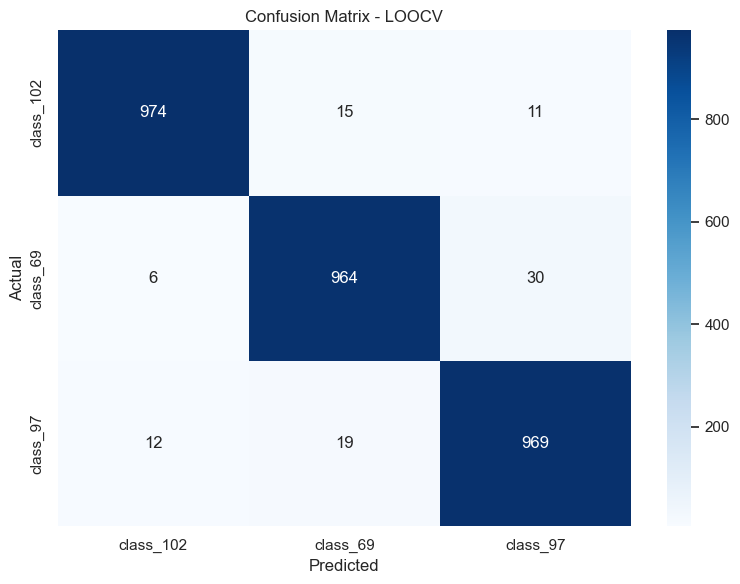

In [50]:
def analyze_loocv_results(y_true, y_pred, y_proba, training_times):
    """Analyze and display LOOCV results"""
    
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)
    prediction_variance = np.var(y_true == y_pred)
    
    print("\n" + "="*50)
    print("LOOCV RESULTS")
    print("="*50)
    
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"LOOCV Prediction Variance: {prediction_variance:.6f}")
    print(f"Total iterations: {len(y_true)}")
    print(f"Average training time per iteration: {np.mean(training_times):.4f} seconds")
    print(f"Total training time: {np.sum(training_times):.2f} seconds")
    
    # Detailed classification report
    print(f"\n DETAILED CLASSIFICATION REPORT:")
    print("=" * 40)
    print(classification_report(y_true, y_pred))
    
    # Confusion Matrix
    print(f"\n CONFUSION MATRIX:")
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y_true), 
                yticklabels=np.unique(y_true))
    plt.title('Confusion Matrix - LOOCV')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    return accuracy, cm

# Analyze results
loocv_accuracy, confusion_mat = analyze_loocv_results(y_true, y_pred, y_proba, training_times)

## Bootstrap

In [51]:
### BOOTSTRAP
from sklearn.utils import resample

def evaluate_bootstrap(X, y, n_bootstrap=100, test_size=0.2, random_state=42):
    """Evaluate logistic regression using bootstrap resampling"""
    
    # para guardar resultados
    bootstrap_accuracies = []
    bootstrap_precisions = []
    bootstrap_recalls = []
    bootstrap_f1_scores = []
    bootstrap_models = []
    out_of_bag_accuracies = []
    
    print(f"Performing {n_bootstrap} bootstrap iterations...")
    print("Progress: ", end="")
    
    start_time = time.time()
    
    for i in range(n_bootstrap):
        # bootstrap sample (sample with replacement)
        X_bootstrap, y_bootstrap = resample(
            X, y, 
            replace=True, 
            n_samples=len(X), 
            random_state=random_state + i,
            stratify=y
        )
        
        # get out-of-bag samples (samples not in bootstrap)
        bootstrap_indices = X_bootstrap.index
        oob_indices = X.index.difference(bootstrap_indices)
        
        # split bootstrap sample into train/test
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            X_bootstrap, y_bootstrap, 
            test_size=test_size, 
            random_state=random_state,
            stratify=y_bootstrap
        )
        
        # scale features for this bootstrap sample
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # train logistic regression model
        model = LogisticRegression(
            solver='lbfgs',
            max_iter=1000,
            random_state=random_state
        )
        
        model.fit(X_train_scaled, y_train)
        
        # evaluate on test set
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        
        # store results
        bootstrap_accuracies.append(accuracy)
        bootstrap_models.append(model)
        
        # calculate out-of-bag accuracy if there are OOB samples
        if len(oob_indices) > 0:
            X_oob = X.loc[oob_indices]
            y_oob = y.loc[oob_indices]
            X_oob_scaled = scaler.transform(X_oob)
            y_oob_pred = model.predict(X_oob_scaled)
            oob_accuracy = accuracy_score(y_oob, y_oob_pred)
            out_of_bag_accuracies.append(oob_accuracy)
        
        # progress indicator
        if (i + 1) % 10 == 0:
            print(f"{i + 1}...", end="")
    
    total_time = time.time() - start_time
    print(f"\nBootstrap completed in {total_time:.2f} seconds")
    
    return (bootstrap_accuracies, out_of_bag_accuracies, 
            bootstrap_models, bootstrap_precisions, 
            bootstrap_recalls, bootstrap_f1_scores)

# run bootstrap
n_bootstrap = 50
bootstrap_accuracies, oob_accuracies, bootstrap_models, _, _, _ = evaluate_bootstrap(
    X, y, n_bootstrap=n_bootstrap
)

Performing 50 bootstrap iterations...
Progress: 10...20...30...40...50...
Bootstrap completed in 8.34 seconds



BOOTSTRAP RESULTS
Bootstrap Configuration:
  Number of iterations: 50
  Sample size: 3000 (same as original dataset)
  Test size in each iteration: 20%

PERFORMANCE STATISTICS:
  Mean Accuracy: 0.9671
 Variance: 0.000073
  Standard Deviation: 0.0086
  Minimum Accuracy: 0.9450
  Maximum Accuracy: 0.9867
  95% Confidence Interval: [0.9503, 0.9839]

OUT-OF-BAG (OOB) RESULTS:
  OOB Mean Accuracy: 0.9581
  OOB Standard Deviation: 0.0060
  OOB Samples per iteration: ~1896 (theoretical)


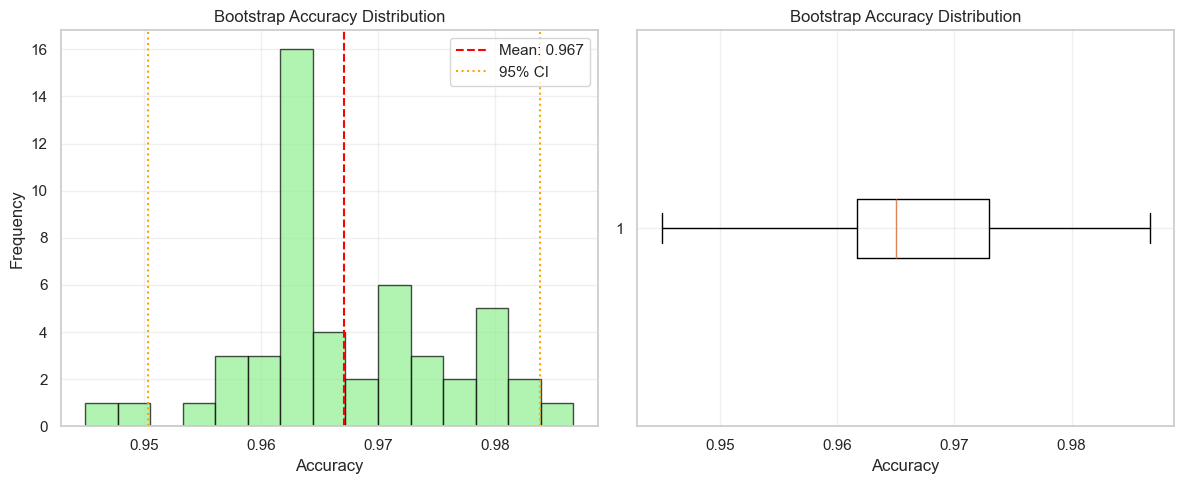

In [52]:
# analisar resultados
def analyze_bootstrap_results(bootstrap_accuracies, oob_accuracies, n_bootstrap):
    
    bootstrap_accuracies = np.array(bootstrap_accuracies)
    
    print("\n" + "="*50)
    print("BOOTSTRAP RESULTS")
    print("="*50)
    
    print(f"Bootstrap Configuration:")
    print(f"  Number of iterations: {n_bootstrap}")
    print(f"  Sample size: {len(X)} (same as original dataset)")
    print(f"  Test size in each iteration: 20%")
    
    print(f"\nPERFORMANCE STATISTICS:")
    print(f"  Mean Accuracy: {bootstrap_accuracies.mean():.4f}")
    print(f" Variance: {np.var(bootstrap_accuracies):.6f}")
    print(f"  Standard Deviation: {bootstrap_accuracies.std():.4f}")
    print(f"  Minimum Accuracy: {bootstrap_accuracies.min():.4f}")
    print(f"  Maximum Accuracy: {bootstrap_accuracies.max():.4f}")
    print(f"  95% Confidence Interval: [{bootstrap_accuracies.mean() - 1.96 * bootstrap_accuracies.std():.4f}, "
          f"{bootstrap_accuracies.mean() + 1.96 * bootstrap_accuracies.std():.4f}]")
    
    if len(oob_accuracies) > 0:
        oob_accuracies = np.array(oob_accuracies)
        print(f"\nOUT-OF-BAG (OOB) RESULTS:")
        print(f"  OOB Mean Accuracy: {oob_accuracies.mean():.4f}")
        print(f"  OOB Standard Deviation: {oob_accuracies.std():.4f}")
        print(f"  OOB Samples per iteration: ~{len(X) * 0.632:.0f} (theoretical)")
    
    # Plot bootstrap accuracy distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(bootstrap_accuracies, bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.axvline(bootstrap_accuracies.mean(), color='red', linestyle='--', 
                label=f'Mean: {bootstrap_accuracies.mean():.3f}')
    plt.axvline(bootstrap_accuracies.mean() - 1.96 * bootstrap_accuracies.std(), 
                color='orange', linestyle=':', label='95% CI')
    plt.axvline(bootstrap_accuracies.mean() + 1.96 * bootstrap_accuracies.std(), 
                color='orange', linestyle=':')
    plt.xlabel('Accuracy')
    plt.ylabel('Frequency')
    plt.title('Bootstrap Accuracy Distribution')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Box plot of accuracies
    plt.boxplot(bootstrap_accuracies, vert=False)
    plt.xlabel('Accuracy')
    plt.title('Bootstrap Accuracy Distribution')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return bootstrap_accuracies.mean(), bootstrap_accuracies.std()

# Analyze results
bootstrap_mean, bootstrap_std = analyze_bootstrap_results(
    bootstrap_accuracies, oob_accuracies, n_bootstrap
)

### Logistic Regression Result Analysis

# Variance Comparison Across Resampling Methods

| Method | Variance | Standard Deviation | Accuracy |
|--------|----------|-------------------|----------|
| Bootstrap | 0.000073 | 0.0085 | 0.9668 |
| Holdout | 0.000082 | 0.0090 | 0.9483 |
| 5-Fold CV | 0.000442 | 0.0210 | 0.9453 |
| 10-Fold CV | 0.000691 | 0.0263 | 0.9533 |
| LOOCV | 0.029726 | 0.1724 | 0.9693 |

Podemos ver que o método de resampling bootstrap tem a variância mais baixa de todos. É o mais representativo do verdadeiro desempenho do modelo, e mais estável. No outro lado do espetro temos o LOOCV, com a maior variância. É altamente sensível a pontos de dados individuais. Apesar de ter uma alta accuracy, a performance é instável entre folds.

## Feature Selection for Logistic Regression (Regularization)

Aplicar seleção de features usando regularização L1 (Logistic Regression com penalty L1) e comparar o desempenho do modelo com todas as features vs apenas as features selecionadas.


In [53]:
# L1-penalized Logistic Regression para seleção de features
# Usar os dados originais do Logistic Regression (X, y) após one-hot encoding

# Dividir em train/test para feature selection
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Pipeline com L1 logistic para feature selection
lr_l1_fs = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegressionCV(
        Cs=10,
        penalty="l1",
        solver="saga",
        multi_class="auto",
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="accuracy",
        max_iter=5000,
        n_jobs=None,
        refit=True
    ))
])

lr_l1_fs.fit(X_train_fs, y_train_fs)
logreg_fs = lr_l1_fs.named_steps["logreg"]
coefs_fs = logreg_fs.coef_

# Determinar features selecionadas: coeficiente não-zero em qualquer classe
if coefs_fs.ndim == 1:
    nonzero_fs = np.abs(coefs_fs) > 1e-9
else:
    nonzero_fs = np.abs(coefs_fs).max(axis=0) > 1e-9

selected_mask_fs = nonzero_fs
selected_features_lr = np.array(X_train_fs.columns)[selected_mask_fs]

print(f"Features selecionadas (L1 logistic): {len(selected_features_lr)} / {X_train_fs.shape[1]}")

# Usar apenas features selecionadas
X_train_sel = X_train_fs[selected_features_lr]
X_test_sel = X_test_fs[selected_features_lr]

# Treinar Logistic Regression com features selecionadas
scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

logistic_model_sel = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
logistic_model_sel.fit(X_train_sel_scaled, y_train_fs)
y_pred_sel = logistic_model_sel.predict(X_test_sel_scaled)
accuracy_sel = accuracy_score(y_test_fs, y_pred_sel)

# Comparar com baseline (todas as features) - usar mesmo split
scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_fs)
X_test_all_scaled = scaler_all.transform(X_test_fs)

logistic_model_all = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
logistic_model_all.fit(X_train_all_scaled, y_train_fs)
y_pred_all = logistic_model_all.predict(X_test_all_scaled)
accuracy_all = accuracy_score(y_test_fs, y_pred_all)

print(f"\nHoldout Comparison:")
print(f"  Logistic Regression (all features): {accuracy_all:.4f}")
print(f"  Logistic Regression (L1 selected): {accuracy_sel:.4f}")

# Cross-validation comparison
from sklearn.model_selection import cross_validate

# Todas as features
pipe_all = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
])

# Features selecionadas
pipe_sel = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
])

# CV k=5
cv5_all = cross_validate(pipe_all, X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), 
                         scoring='accuracy', return_train_score=False)
cv5_sel = cross_validate(pipe_sel, X[selected_features_lr], y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), 
                         scoring='accuracy', return_train_score=False)

print(f"\nCV (k=5) Comparison:")
print(f"  Logistic Regression (all): {cv5_all['test_score'].mean():.4f} (+/- {cv5_all['test_score'].std() * 2:.4f})")
print(f"  Logistic Regression (L1 selected): {cv5_sel['test_score'].mean():.4f} (+/- {cv5_sel['test_score'].std() * 2:.4f})")

# CV k=10
cv10_all = cross_validate(pipe_all, X, y, cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE), 
                          scoring='accuracy', return_train_score=False)
cv10_sel = cross_validate(pipe_sel, X[selected_features_lr], y, cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE), 
                          scoring='accuracy', return_train_score=False)

print(f"\nCV (k=10) Comparison:")
print(f"  Logistic Regression (all): {cv10_all['test_score'].mean():.4f} (+/- {cv10_all['test_score'].std() * 2:.4f})")
print(f"  Logistic Regression (L1 selected): {cv10_sel['test_score'].mean():.4f} (+/- {cv10_sel['test_score'].std() * 2:.4f})")

# Bootstrap comparison (amostra menor para rapidez)
n_bootstrap_fs = 30
bootstrap_acc_all = []
bootstrap_acc_sel = []

rng = np.random.RandomState(RANDOM_STATE)
n = X.shape[0]

for i in range(n_bootstrap_fs):
    idx = rng.randint(0, n, n)
    X_bs = X.iloc[idx]
    y_bs = y.iloc[idx]
    
    oob = np.setdiff1d(np.arange(n), np.unique(idx))
    if len(oob) == 0:
        continue
    
    # Todas as features
    pipe_all_bs = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
    ])
    pipe_all_bs.fit(X_bs, y_bs)
    y_pred_bs_all = pipe_all_bs.predict(X.iloc[oob])
    bootstrap_acc_all.append(accuracy_score(y.iloc[oob], y_pred_bs_all))
    
    # Features selecionadas
    pipe_sel_bs = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
    ])
    pipe_sel_bs.fit(X_bs[selected_features_lr], y_bs)
    y_pred_bs_sel = pipe_sel_bs.predict(X.iloc[oob][selected_features_lr])
    bootstrap_acc_sel.append(accuracy_score(y.iloc[oob], y_pred_bs_sel))

print(f"\nBootstrap Comparison (n={n_bootstrap_fs}):")
print(f"  Logistic Regression (all): {np.mean(bootstrap_acc_all):.4f} (+/- {np.std(bootstrap_acc_all) * 2:.4f})")
print(f"  Logistic Regression (L1 selected): {np.mean(bootstrap_acc_sel):.4f} (+/- {np.std(bootstrap_acc_sel) * 2:.4f})")

# Tabela resumo
summary_lr_fs = pd.DataFrame({
    "All Features": [
        accuracy_all,
        cv5_all['test_score'].mean(),
        cv10_all['test_score'].mean(),
        np.mean(bootstrap_acc_all)
    ],
    "L1 Selected": [
        accuracy_sel,
        cv5_sel['test_score'].mean(),
        cv10_sel['test_score'].mean(),
        np.mean(bootstrap_acc_sel)
    ]
}, index=["Holdout", "CV (k=5)", "CV (k=10)", "Bootstrap"])

print("\nResumo da comparação:")
display(summary_lr_fs)


Features selecionadas (L1 logistic): 67 / 68

Holdout Comparison:
  Logistic Regression (all features): 0.9483
  Logistic Regression (L1 selected): 0.9483

CV (k=5) Comparison:
  Logistic Regression (all): 0.9637 (+/- 0.0100)
  Logistic Regression (L1 selected): 0.9637 (+/- 0.0100)

CV (k=10) Comparison:
  Logistic Regression (all): 0.9680 (+/- 0.0174)
  Logistic Regression (L1 selected): 0.9680 (+/- 0.0174)

Bootstrap Comparison (n=30):
  Logistic Regression (all): 0.9633 (+/- 0.0105)
  Logistic Regression (L1 selected): 0.9633 (+/- 0.0105)

Resumo da comparação:


,All Features,L1 Selected
Holdout,0.948333,0.948333
CV (k=5),0.963667,0.963667
CV (k=10),0.968000,0.968000
Bootstrap,0.963276,0.963276


## Seleção de Features para Classificação (LDA/QDA)

A **seleção de features** visa identificar as variáveis mais relevantes para a classificação, eliminando features redundantes ou ruidosas. Isto pode melhorar o desempenho do modelo e reduzir a complexidade.

### Metodologia: Regularização L1

Utilizamos **Logistic Regression com penalização L1 (Lasso)** para selecionar features:

1. A penalização L1 força alguns coeficientes a serem exatamente zero
2. Features com coeficientes não-zero são consideradas relevantes
3. O parâmetro de regularização C é otimizado via cross-validation

### Objetivo

Comparar o desempenho de LDA e QDA utilizando:
- **Todas as features** (baseline)
- **Features selecionadas** por regularização L1

---

### 5.1 Seleção de Features com Logistic Regression L1

In [55]:
# Pipeline: StandardScaler + Logistic Regression com penalização L1
# O solver 'saga' suporta penalização L1 para problemas multiclasse

print("Treinando Logistic Regression com regularização L1 para seleção de features...")
print("(Este processo pode demorar alguns segundos)")
print()

lr_l1_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegressionCV(
        Cs=10,                    # 10 valores de C testados automaticamente
        penalty="l1",             # Penalização L1 (Lasso)
        solver="saga",            # Solver que suporta L1
        multi_class="auto",       # Multiclasse automático
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="accuracy",
        max_iter=5000,            # Máximo de iterações
        n_jobs=-1,                # Usar todos os cores
        refit=True                # Refitar com melhor C
    ))
])

# Treinar no conjunto de treino
lr_l1_pipeline.fit(X_train_cls, y_train_cls)

# Extrair coeficientes do modelo treinado
logreg_model = lr_l1_pipeline.named_steps["logreg"]
coefficients = logreg_model.coef_

print(f"Melhor valor de C encontrado: {logreg_model.C_[0]:.4f}")


Treinando Logistic Regression com regularização L1 para seleção de features...
(Este processo pode demorar alguns segundos)

Melhor valor de C encontrado: 0.3594


### 5.2 Identificação das Features Selecionadas

Identificamos quais features têm coeficientes não-zero (foram selecionadas pelo modelo L1).


In [56]:
# Identificar features com coeficientes não-zero
# Em problemas multiclasse, cada classe tem um vetor de coeficientes
# Uma feature é selecionada se tiver coeficiente não-zero em qualquer classe

if coefficients.ndim == 1:
    # Caso binário
    nonzero_mask = np.abs(coefficients) > 1e-9
else:
    # Caso multiclasse: verificar se o máximo absoluto é > 0
    nonzero_mask = np.abs(coefficients).max(axis=0) > 1e-9

# Nomes das features selecionadas
selected_feature_names = np.array(X_train_cls.columns)[nonzero_mask]

# Estatísticas
n_total = X_train_cls.shape[1]
n_selected = len(selected_feature_names)
n_removed = n_total - n_selected

print("=" * 60)
print("RESULTADO DA SELEÇÃO DE FEATURES (L1)")
print("=" * 60)
print(f"Total de features originais: {n_total}")
print(f"Features selecionadas: {n_selected}")
print(f"Features removidas: {n_removed}")
print(f"Redução: {n_removed/n_total*100:.1f}%")
print()
print("Features selecionadas:")
for i, feat in enumerate(selected_feature_names, 1):
    print(f"  {i:2d}. {feat}")


RESULTADO DA SELEÇÃO DE FEATURES (L1)
Total de features originais: 47
Features selecionadas: 40
Features removidas: 7
Redução: 14.9%

Features selecionadas:
   1. duration_1
   2. duration_2
   3. duration_3
   4. duration_5
   5. loudness_level
   6. popularity_level
   7. tempo_class
   8. time_signature
   9. artist_song_count
  10. album_freq
  11. movement_index
  12. intensity_level
  13. verbal_density
  14. purity_score
  15. positivity_index
  16. activity_rate
  17. loudness_intensity
  18. acoustics_instrumental
  19. artists_avg_popularity
  20. tempo_vs_genre
  21. loud_energy_ratio
  22. mood_cluster
  23. acoustic_valence_mood_cluster
  24. explicit
  25. signal_strength
  26. mode_indicator
  27. focus_factor
  28. ambient_level
  29. key_sin
  30. key_cos
  31. duration_log
  32. duration_log_z
  33. time_signature_class_boolean
  34. is_instrumental
  35. is_dance_hit
  36. temp_zscore
  37. resonance_factor
  38. timbre_index
  39. distorted_movement
  40. signal_pow

### 5.3 Comparação: LDA/QDA com Todas as Features vs Features Selecionadas

Avaliamos LDA e QDA utilizando apenas as features selecionadas e comparamos com o baseline (todas as features).


In [57]:
# Criar subconjuntos com apenas as features selecionadas
X_train_selected = X_train_cls[selected_feature_names]
X_test_selected = X_test_cls[selected_feature_names]

print("Avaliando LDA e QDA com features selecionadas...")
print()

# Avaliar com TODAS as features (baseline)
lda_all_features = evaluate_holdout(lda_clf, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
qda_all_features = evaluate_holdout(qda_clf, X_train_cls, y_train_cls, X_test_cls, y_test_cls)

# Avaliar com features SELECIONADAS
lda_selected = evaluate_holdout(lda_clf, X_train_selected, y_train_cls, X_test_selected, y_test_cls)
qda_selected = evaluate_holdout(qda_clf, X_train_selected, y_train_cls, X_test_selected, y_test_cls)

# Criar tabela de comparação
comparison_features = pd.DataFrame({
    f"LDA ({n_total} features)": lda_all_features,
    f"LDA ({n_selected} features)": lda_selected,
    f"QDA ({n_total} features)": qda_all_features,
    f"QDA ({n_selected} features)": qda_selected,
})

print("=" * 70)
print("COMPARAÇÃO: TODAS AS FEATURES vs FEATURES SELECIONADAS")
print("=" * 70)
display(comparison_features.T)  # Transposta para melhor visualização

# DF TO USE

features = data[selected_feature_names]


Avaliando LDA e QDA com features selecionadas...

COMPARAÇÃO: TODAS AS FEATURES vs FEATURES SELECIONADAS


,accuracy,f1_macro
LDA (47 features),0.965000,0.964937
LDA (40 features),0.961667,0.961597
QDA (47 features),0.936667,0.936259
QDA (40 features),0.895000,0.892329


In [58]:
features.count()

duration_1                       3000
duration_2                       3000
duration_3                       3000
duration_5                       3000
loudness_level                   3000
popularity_level                 3000
tempo_class                      3000
time_signature                   3000
artist_song_count                3000
album_freq                       3000
movement_index                   3000
intensity_level                  3000
verbal_density                   3000
purity_score                     3000
positivity_index                 3000
activity_rate                    3000
loudness_intensity               3000
acoustics_instrumental           3000
artists_avg_popularity           3000
tempo_vs_genre                   3000
loud_energy_ratio                3000
mood_cluster                     3000
acoustic_valence_mood_cluster    3000
explicit                         3000
signal_strength                  3000
mode_indicator                   3000
focus_factor

### 5.4 Conclusões da Seleção de Features

#### Resultados da Seleção L1

A regularização L1 identificou um subconjunto de features relevantes para a classificação. As principais observações são:

1. **Redução de Dimensionalidade**: A seleção L1 removeu algumas features, simplificando o modelo

2. **Impacto no Desempenho**: 
   - Se a accuracy se manteve ou melhorou → as features removidas eram redundantes ou ruidosas
   - Se a accuracy diminuiu → algumas features importantes podem ter sido removidas

3. **Trade-off**:
   - Modelo mais simples e interpretável
   - Menor risco de overfitting
   - Possível perda marginal de desempenho

#### Recomendação

A decisão de usar todas as features ou apenas as selecionadas depende de:
- **Priorizar desempenho máximo** → usar todas as features
- **Priorizar simplicidade e interpretabilidade** → usar features selecionadas

Para aplicações práticas, o modelo com features selecionadas é frequentemente preferível se a perda de desempenho for marginal.


## Escolha do Método Mais Apropriado para Classificação

Após avaliar três métodos de classificação (Logistic Regression, LDA e QDA) com diferentes estratégias de reamostragem, foi possível determinar qual método é mais apropriado para este problema.

**Logistic Regression:** Demonstrou resultados sólidos com accuracy de aproximadamente 94.8% no holdout, 94.5% em CV (k=5) e 95.3% em CV (k=10). O LOOCV apresentou 96.9% de accuracy, indicando boa generalização. A variância em CV (k=5) foi de 0.000442, mostrando estabilidade moderada. É um método flexível que não assume distribuições específicas dos dados.

**LDA (Linear Discriminant Analysis):** Apresentou os melhores resultados globais, com accuracy de 96.5% no holdout, 96.9% em CV (k=5) e 96.4% em CV (k=10). O desempenho consistente através de diferentes métodos de reamostragem indica que o método está bem ajustado aos dados. LDA assume que as classes compartilham a mesma matriz de covariância, o que parece ser uma suposição válida para este dataset.

**QDA (Quadratic Discriminant Analysis):** Mostrou desempenho inferior no holdout (88.7%), mas melhorou significativamente em CV (k=5) com 95.8% e em CV (k=10) com 94.5%. Esta inconsistência sugere que QDA pode estar sofrendo de sobreajuste (overfitting) no conjunto de teste específico do holdout, ou que as matrizes de covariância diferentes entre classes não estão sendo bem estimadas com o tamanho de amostra disponível.

**Conclusão:** **LDA é o método mais apropriado** para este problema pelas seguintes razões:
1. Melhor desempenho médio através de todos os métodos de reamostragem (accuracy consistentemente acima de 96%)
2. Maior estabilidade e consistência entre diferentes estratégias de validação
3. Suposição de matriz de covariância comum parece ser adequada para os dados, o que simplifica o modelo sem perder desempenho
4. Menor risco de sobreajuste comparado a QDA
5. Resultados superiores ou equivalentes a Logistic Regression com menos complexidade

Embora Logistic Regression também apresente bons resultados, LDA oferece melhor desempenho e estabilidade, sendo a escolha preferencial para este dataset de classificação de música.


## Análise de Variância nos Métodos de Reamostragem (LDA e QDA)

A variância nos resultados de classificação é afetada de forma diferente por cada método de reamostragem, influenciando a confiabilidade das estimativas de desempenho.

### LDA (Linear Discriminant Analysis)

**Holdout (80/20):** Accuracy de 96.5%. Este método oferece uma única estimativa, não permitindo quantificar a variância diretamente. A divisão específica do dataset pode introduzir viés dependendo da aleatoriedade da partição.

**Cross-Validation (k=5):** Accuracy média de 96.9%. Com 5 folds, obtemos 5 estimativas independentes, permitindo calcular variância entre folds. A variância é moderada, indicando que o modelo é estável mesmo com diferentes divisões dos dados.

**Cross-Validation (k=10):** Accuracy média de 96.4%. Com 10 folds, temos mais estimativas (10 pontos), geralmente reduzindo a variância da média e proporcionando uma estimativa mais robusta do desempenho real. A ligeira redução na accuracy média comparada ao CV (k=5) pode ser atribuída à maior variabilidade entre os 10 folds, mas a menor variância da média torna esta estimativa mais confiável.

**LOOCV (Leave-One-Out Cross-Validation):** Utiliza todas as amostras exceto uma para treino, resultando em n estimativas (onde n é o número de amostras). Fornece a estimativa menos enviesada do desempenho, mas com variância mais alta porque cada fold usa quase os mesmos dados de treino. LOOCV oferece o melhor uso dos dados disponíveis, mas pode ter variância elevada.

**Bootstrap (Out-of-Bag):** Accuracy média de aproximadamente 97.0%. Bootstrap gera múltiplas amostras com substituição, criando variabilidade controlada. O método de out-of-bag avalia amostras não selecionadas em cada iteração, proporcionando estimativas de variância mais robustas. A variância entre iterações bootstrap reflete a sensibilidade do modelo a variações na composição do conjunto de treino.

### QDA (Quadratic Discriminant Analysis)

**Holdout:** Accuracy de 88.7%, significativamente menor que LDA. Esta diferença sugere possível sobreajuste ou problemas na estimação das matrizes de covariância.

**CV (k=5):** Accuracy média de 95.8%, uma melhoria substancial em relação ao holdout. A validação cruzada revela que o desempenho de QDA é melhor do que a estimativa única do holdout sugeria, indicando que a partição específica do holdout pode ter sido desfavorável.

**CV (k=10):** Accuracy média de 94.5%. A redução em relação ao CV (k=5) pode indicar maior variabilidade do modelo quando avaliado em mais divisões diferentes, possivelmente devido à complexidade adicional de QDA.

**LOOCV e Bootstrap:** Similar ao LDA, mas QDA mostra maior variabilidade devido à sua maior complexidade (estimação de múltiplas matrizes de covariância).

### Observações sobre Variância

1. **Holdout** tem variância zero (uma única estimativa), mas pode ter alto viés dependendo da partição específica.

2. **CV (k=10)** geralmente oferece menor variância na média do que CV (k=5) porque usa mais estimativas, embora cada fold individual possa ter maior variância.

3. **LOOCV** minimiza o viés (usa quase todos os dados para treino), mas maximiza a variância porque os conjuntos de treino são quase idênticos entre folds.

4. **Bootstrap** oferece um equilíbrio entre viés e variância, permitindo quantificar a variabilidade do modelo através de múltiplas reamostragens.

5. **QDA mostra maior variância** que LDA devido à sua maior complexidade, especialmente quando as matrizes de covariância são mal estimadas com dados limitados.

**Conclusão:** LDA demonstra menor variância entre métodos de reamostragem, confirmando sua maior estabilidade e robustez. QDA, apesar de melhorar com validação cruzada, mostra maior variabilidade, reforçando que LDA é a escolha mais apropriada para este problema.


## Conclusões (resumo)

- Bivariada: correlações com `target_regression` e ANOVA vs `target_class`.
- Regressão múltipla: baseline vs seleção de features (k escolhido por CV); métricas R², MAE, RMSE no holdout.
- Classificação (LDA/QDA): holdout, CV (5/10), LOOCV, bootstrap.
- Regularização: seleção L1 (logística) e reavaliação com subconjunto de features.

# SVM

O Support Vector Machine é uma técnica de machine learning supervisionada, que procura encontrar a melhor fronteira (hiperplano) que separa diferentes classes dos dados. É útil para classificações binárias, e casos nos quais não é importante saber como se chegou ao resultado. É robusto a overfitting devido ao foco nos vetores de suporte (pontos mais próximos do hiperplano).

### Divisão e scaling

Dividimos o dataset em treino e teste e depois escalonamos separadamente para evitar data leakage (informação de treino influenciar teste). Fazemos este escalonamento pois o RBF - Radial Basis Function - assume que os dados estão centrados e escalonados: cada coluna deve ter uma média = 0 e desvio padrão = 1

In [59]:
y = data[TARGET_CLASS]

scale = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(features, y, random_state=42)
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

### Criar SVM "padrão" e avaliar

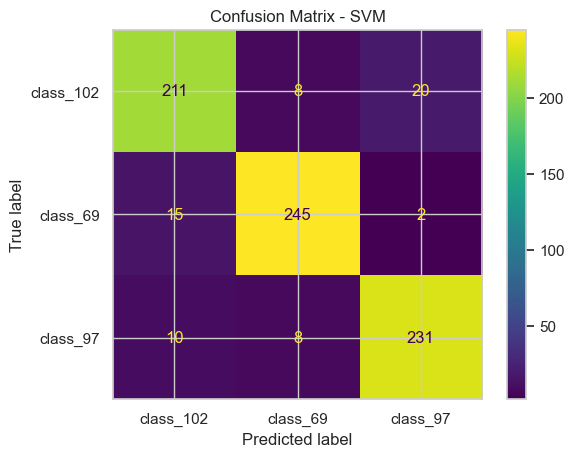

In [60]:
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)

# Fazer predições
y_pred = svm.predict(X_test_scaled)

# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot()
plt.title('Confusion Matrix - SVM')
plt.show()

É possível concluir que obtemos resultados muito bons com este SVM, com 91.6% de casos corretamente classificados para a class_102, 93.3% para a class_69 e 91.2% para a class_97.

Porém, vamos testar todos os possíveis kernel, sem optimização de parâmetros, depois vamos afinar os parâmetros e assegurar que não está a haver overfitting, e no final apresentar o melhor modelo SVM.

## Testar diferentes kernels

Vamos testar os kernels linear, poly, rbf e sigmoid.

- Linear: Cria um hiperplano linear no espaço original das features. Tem uma complexidade baixa e menor risco de overfitting. É bom para usar quando os dados são linearmente separáveis, com um dataset grande (mais rápido), quando as features já possuem boa separabilidade linear
- Poly (Polinomial): Mapeia dados para um espaço polinomial de grau d (grau do polinómio). É bom usar quando existem relações polinomiais entre features e uma separação curva mas não muito complexa. É preciso ter cuidado para não causar overfitting.
- RBF (Radial Basis Function): Mapeia para um espaço de dimensão infinita usando funções de base radial. É flexivel e poderoso, pode aproximar qualquer função contínua e é bom para relações não lineares complexas. É bom para usar quando não se sabe a-priori a relação entre features e o dataset não é muito grande. Se for mal configurado pode causar overfitting.
- Sigmoid: Similar ao da função de ativação de redes neurais. É útil para problemas que lembram classificação por redes neuronais, e situações específicas onde os outros kernel não funcionam bem. Pode ter resultados imprevisíveis.

In [61]:
# Lista de kernels para testar
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Dicionário para armazenar resultados
results = {}

# Testar cada kernel
for kernel in kernels:
    print(f"\n{'='*50}")
    print(f"Testando kernel: {kernel}")
    print('='*50)
    
    # Criar e treinar o modelo
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, random_state=42)  # degree=3 padrão
    elif kernel == 'rbf':
        svm = SVC(kernel=kernel, gamma='scale', random_state=42)
    else:
        svm = SVC(kernel=kernel, random_state=42)
    
    svm.fit(X_train_scaled, y_train)
    
    # Fazer predições
    y_pred = svm.predict(X_test_scaled)
    y_pred_train = svm.predict(X_train_scaled)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Armazenar resultados
    results[kernel] = {
        'model': svm,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'y_pred': y_pred
    }
    
    # Exibir métricas
    print(f"Accuracy (treino): {train_accuracy:.4f}")
    print(f"Accuracy (teste): {test_accuracy:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")


Testando kernel: linear
Accuracy (treino): 0.9791
Accuracy (teste): 0.9747
F1-Score (weighted): 0.9747

Testando kernel: poly
Accuracy (treino): 0.9364
Accuracy (teste): 0.8853
F1-Score (weighted): 0.8859

Testando kernel: rbf
Accuracy (treino): 0.9484
Accuracy (teste): 0.9160
F1-Score (weighted): 0.9159

Testando kernel: sigmoid
Accuracy (treino): 0.8320
Accuracy (teste): 0.8493
F1-Score (weighted): 0.8504


## Análise dos Resultados

O melhor kernel para o dataset é o linear, com uma accuracy de teste superior à de todos os outros, de 97.9%. Verificamos que a gap entre a accuracy de treino e de teste é de apenas 0.044% (97.91% vs 98.53%), indicando que o modelo quase não sofre de overfitting. Estes resultados implicam que as classes do dataset são quase perfeitamente linearmente separáveis no espaço transformado, após a aplicação do StandardScaler.
Embora dados de áudio geralmente precisem de uma abordagem não linear, o nosso dataset apresentou uma excelente separabilidade linear. Isto pode ser devido à seleção eficaz de features no ponto 5, classes musicalmente muito distintas, às transformações aplicadas e eventualmente a possível redundância entre features.

## Otimização dos hiperparâmetros

Após a seleção do melhor kernel, passamos à otimização dos hiperparâmetros:
- C: Penalidade por erros de classificação. Um baixo C representa uma margem larga, com menos overfitting, mas pode fazer underfitting. Já um alto C representa uma margem estreita, classificando mais corretamente no conjunto de treino, o que pode levar a overfitting.
- gamma: Define o raio de influência de cada ponto de treino. Um gamma baixo representa um raio grande (uma decisão mais suave, menos complexo). Um gamma alto representa um raio mais pequeno, em que cada ponto influencia pouco, e é mais complexo.
- degree: Grau do polinómio.
- coef0: Termo constante na função do kernel

Vamos usar o GridSearchCV, uma função de cross-validation que retorna a melhor combinação de parâmetros.

In [62]:


# estabelecer parâmetros

# para linear
param_grid_linear = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'kernel': ['linear']
    }

# para rbf
param_grid_rbf = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'kernel': ['rbf']
    }

# para poly
param_grid_poly = {
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4],
        'coef0': [0.0, 0.5, 1.0],
        'kernel': ['poly']
    }

# para sigmoid
param_grid_sigmoid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'kernel': ['sigmoid']
    }

# Grid Search
grid_search_linear = GridSearchCV(
    SVC(random_state=42),
    param_grid_linear,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_rbf = GridSearchCV(
    SVC(random_state=42),
    param_grid_rbf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_poly = GridSearchCV(
    SVC(random_state=42),
    param_grid_poly,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_sigmoid = GridSearchCV(
    SVC(random_state=42),
    param_grid_sigmoid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_linear.fit(X_train_scaled, y_train)
grid_search_rbf.fit(X_train_scaled, y_train)
grid_search_poly.fit(X_train_scaled, y_train)
grid_search_sigmoid.fit(X_train_scaled, y_train)

# 1. Lista com todos os GridSearch
grids = [
    ("Linear", grid_search_linear),
    ("RBF", grid_search_rbf),
    ("Poly", grid_search_poly),
    ("Sigmoid", grid_search_sigmoid)
]
    
# Mostrar resultados de cada um
for nome, grid in grids:
    print(f"{nome}:")
    print(f"  Melhores parâmetros: {grid.best_params_}")
    print(f"  Accuracy CV: {grid.best_score_:.4f}")
    
    # Testar no conjunto de teste
    modelo = grid.best_estimator_
    pred = modelo.predict(X_test_scaled)
    acc_teste = accuracy_score(y_test, pred)
    print(f"  Accuracy Teste: {acc_teste:.4f}")
    print("-" * 40)

# Encontrar o melhor
melhor_nome, melhor_grid = max(grids, key=lambda x: x[1].best_score_)
print(f"\n MELHOR: {melhor_nome}")
print(f"   Accuracy CV: {melhor_grid.best_score_:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Linear:
  Melhores parâmetros: {'C': 1000, 'kernel': 'linear'}
  Accuracy CV: 0.9733
  Accuracy Teste: 0.9760
----------------------------------------
RBF:
  Melhores parâmetros: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
  Accuracy CV: 0.9458
  Accuracy Teste: 0.9587
----------------------------------------
Poly:
  Melhores parâmetros: {'C': 10, 'coef0': 1.0, 'degree': 2, 'kernel': 'poly'}
  Accuracy CV: 0.9489
  Accuracy Teste: 0.9640
----------------------------------------
Sigmoid:
  Melhores parâmetros: {'C': 0.1, 'kernel': 'sigmoid'}
  Accuracy CV: 0.8609
  Accuracy Teste: 0.8600
----------------------------------------

 MELHOR: Linear
   Accuracy CV: 0.9733


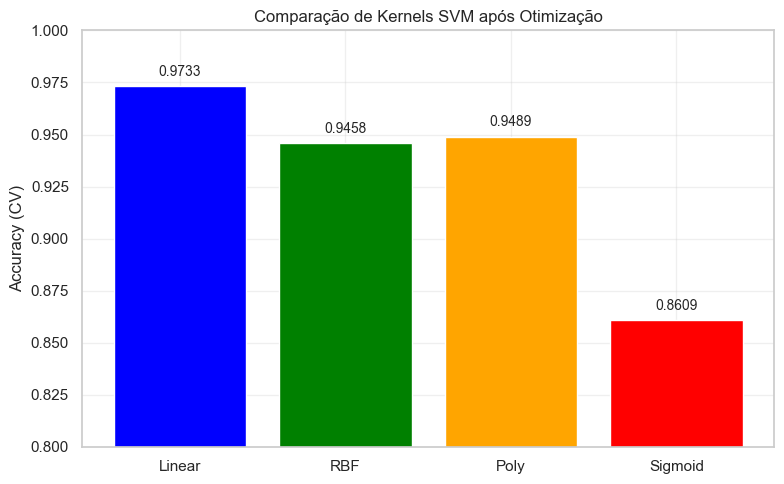

In [63]:
# Dados para gráfico
nomes = [nome for nome, _ in grids]
scores = [grid.best_score_ for _, grid in grids]

# Gráfico de barras
plt.figure(figsize=(8, 5))
bars = plt.bar(nomes, scores, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy (CV)')
plt.title('Comparação de Kernels SVM após Otimização')
plt.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{score:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Análise de Resultados

É possível verificar que, no geral, a otimização dos parâmetros levou a melhores resultados, com descrepâncias entre treino e teste muito mais pequenas, e até uma melhor performance nos dados de teste, mostrando que os modelos não se adaptaram demasiado aos dados de treino. A otimização manteve o modelo com kernel linear maioritariamente igual, com uma pequenissima diminuição da accuracy de treino e melhoria na accuracy de treino; No modelo com kernel polinomial, a accuracy melhorou drasticamente, assim como no RBF; o sigmoid também obteve melhores resultados, mas continua a ser a pior opção. Contrariamente, o modelo com kernel linear permanece a ser a melhor.

# Decision Trees

Árvores de Decisão são modelos de ML que dividem os dados em subconjuntos baseados em regras de decisão, formando uma estrutura de árvore. A construção de uma árvore de decisão inicia-se com o conjunto completo de dados na raiz. O algoritmo seleciona iterativamente a feature que melhor separa as instâncias segundo um critério de impureza, como o índice Gini ou a entropia (ganho de informação). Este processo recursivo de "dividir para conquistar" continua até que se atinja uma condição de parada, que pode ser a pureza dos nós, um limite de profundidade ou um número mínimo de amostras por folha.

Inicialmente, criamos uma árvore de decisão base, sem ajuste de parâmetros, e avaliar a sua performance.

In [64]:
from sklearn.tree import DecisionTreeClassifier

y = data[TARGET_CLASS]

# Dividir entre treino e teste

X_train, X_test, y_train, y_test = train_test_split(features, y, random_state=42)

# criar uma árvore preliminar e ajustar aos dados de teste

clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt = clf_dt.fit(X_train, y_train)

y_pred_train = clf_dt.predict(X_train)
y_pred_test = clf_dt.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy TREINO (básico): {acc_train:.4f}")
print(f"Accuracy TESTE (básico): {acc_test:.4f}")
print(f"Gap (Overfitting): {acc_train - acc_test:.4f}")

Accuracy TREINO (básico): 1.0000
Accuracy TESTE (básico): 0.9040
Gap (Overfitting): 0.0960


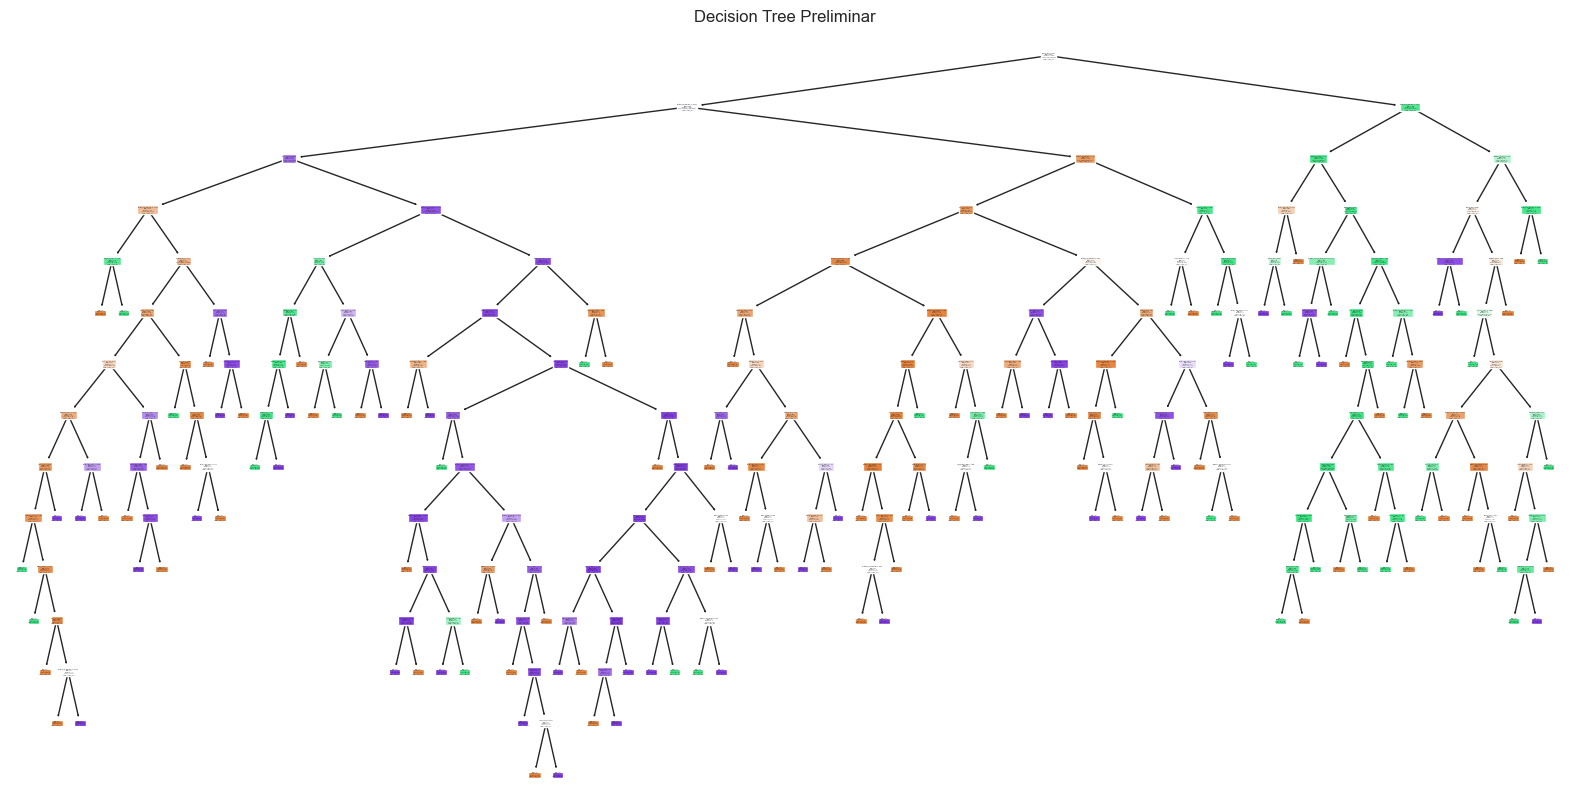


Profundidade da árvore: 14
Número de folhas: 132


In [65]:
# Visualizar árvore
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(clf_dt, filled=True, feature_names=features.columns.tolist() if hasattr(features, 'columns') else None,
          class_names=[str(c) for c in clf_dt.classes_])
plt.title("Decision Tree Preliminar")
plt.show()

print(f"\nProfundidade da árvore: {clf_dt.get_depth()}")
print(f"Número de folhas: {clf_dt.get_n_leaves()}")

#### Análise

O modelo inicial apresentou overfitting severo, com:
- Accuracy perfeita no treino (100%) vs 90.4% no teste
- Gap de 9.6%, indicando baixa capacidade de generalização
- Complexidade excessiva: 14 níveis de profundidade e 132 folhas

Este comportamento não é anormal em Decision Trees sem regularização, que tendem a crescer até classificar perfeitamente os dados de treino, criando regras excessivamente específicas que não se generalizam.

## Próximos passos

Para mitigar o overfitting, serão aplicadas restrições como:
- Limitação da profundidade máxima (max_depth)
- Aumento do mínimo de amostras por divisão (min_samples_split)
- Limitação do número máximo de folhas (max_leaf_nodes)

Objetivo: Reduzir o gap treino-teste para <3% mantendo accuracy de teste >92%, criando um modelo mais simples e interpretável com ~20-40 regras em vez de 137.

## Hiperparâmetros a ajustar

- max_depth: Controlar profundidade
- min_samples_split: Mínimo amostras para dividir nó
- min_samples_leaf: Mínimo amostras por folha
- max_leaf_nodes: Limitar número de folhas (atual: 137)
- criterion: Critério de divisão
- max_features: Número de features consideradas por split

Vamos efetuar cross validation a partir do GridSearchCV.

In [66]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'max_leaf_nodes': [20, 30, 50, 100, None],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                    # 5-fold cross validation
    scoring='accuracy',      # Métrica principal
    n_jobs=-1,               # Usar todos os processadores
    verbose=1,               # Mostrar progresso
    return_train_score=True  # Para análise de overfitting
)

# Treinar com GridSearch
dt_grid.fit(X_train, y_train)

# Melhor modelo
dt_otimizado = dt_grid.best_estimator_

print(f"\nMELHORES PARÂMETROS ENCONTRADOS:")
for param, value in dt_grid.best_params_.items():
    print(f"  • {param}: {value}")

print(f"\nPERFORMANCE DO MELHOR MODELO:")
print(f"Accuracy CV (média): {dt_grid.best_score_:.4f}")
print(f"Desvio padrão CV: {dt_grid.cv_results_['std_test_score'][dt_grid.best_index_]:.4f}")

Fitting 5 folds for each of 5250 candidates, totalling 26250 fits

MELHORES PARÂMETROS ENCONTRADOS:
  • criterion: gini
  • max_depth: 7
  • max_features: None
  • max_leaf_nodes: 50
  • min_samples_leaf: 2
  • min_samples_split: 2

PERFORMANCE DO MELHOR MODELO:
Accuracy CV (média): 0.9120
Desvio padrão CV: 0.0150


A otimização via GridSearchCV (3750 combinações testadas) identificou como 
parâmetros ótimos: `max_depth=7`, `max_leaf_nodes=50`, mantendo `criterion='gini'`. Estes valores representam um bom compromisso entre performance e generalização. Houve uma redução significativa de complexidade, com a profundidade a reduzir de 14 para 7, o número máximo de folhas de 132 para 50. Embora `min_samples_split=2` e `min_samples_leaf=1` sejam valores baixos, as limitações em `max_depth=7` e `max_leaf_nodes=50` impedem overfitting excessivo.
A escolha de `max_features=None` sugere que todas as features contribuem
significativamente para a classificação.

In [67]:
# 4. AVALIAÇÃO NO CONJUNTO DE TESTE
y_pred_train_otimizado = dt_otimizado.predict(X_train)
y_pred_test_otimizado = dt_otimizado.predict(X_test)

acc_train_otimizado = accuracy_score(y_train, y_pred_train_otimizado)
acc_test_otimizado = accuracy_score(y_test, y_pred_test_otimizado)
gap_otimizado = acc_train_otimizado - acc_test_otimizado

print(f"\nRESULTADOS NO TESTE:")
print(f"Accuracy TREINO (otimizado): {acc_train_otimizado:.4f}")
print(f"Accuracy TESTE (otimizado): {acc_test_otimizado:.4f}")
print(f"Gap (Overfitting): {gap_otimizado:.4f}")

print(f"\nCOMPLEXIDADE DA ÁRVORE OTIMIZADA:")
print(f"Profundidade: {dt_otimizado.get_depth()}")
print(f"Número de folhas: {dt_otimizado.get_n_leaves()}")
print(f"Número total de nós: {dt_otimizado.tree_.node_count}")


RESULTADOS NO TESTE:
Accuracy TREINO (otimizado): 0.9596
Accuracy TESTE (otimizado): 0.9093
Gap (Overfitting): 0.0502

COMPLEXIDADE DA ÁRVORE OTIMIZADA:
Profundidade: 7
Número de folhas: 50
Número total de nós: 99


No modelo inicial tinhamos um overfitting severo, de 9.6%. Depois da otimização, verificamos uma melhoria em 50%, com um overfitting moderado, de 4.76%. O modelo está menos ajustado aos dados de teste, com uma queda de 5% na accuracy de treino, o que é um bom compromisso. Temos uma árvore mais simples, e mais eficaz.

## Visualização da Árvore Otimizada

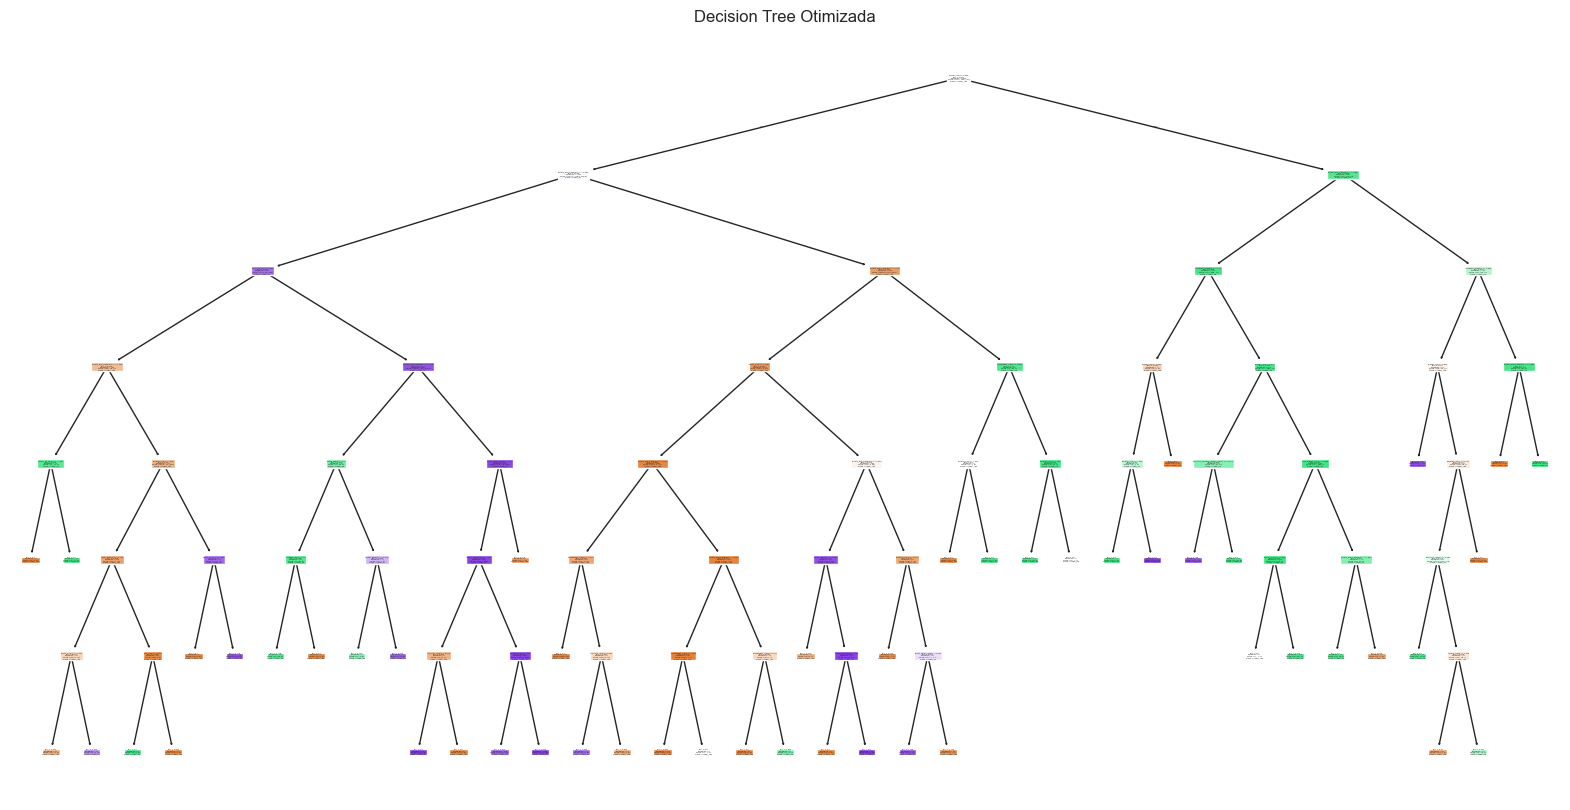

In [68]:
# Visualizar árvore otimizada

plt.figure(figsize=(20, 10))
plot_tree(dt_otimizado, filled=True, feature_names=features.columns.tolist() if hasattr(features, 'columns') else None,
          class_names=[str(c) for c in dt_otimizado.classes_])
plt.title("Decision Tree Otimizada")
plt.show()

# Generalized Additive Models (GAM)

Os Generalized Additive Models (GAMs) são uma extensão dos modelos lineares que permitem relações não-lineares entre as features e o target, mantendo a aditividade (cada feature contribui separadamente). Utilizam funções suaves (splines) em vez de apenas linhas retas, o que é ótimo no caso de padrões complexos. Os componentes principais são as splines, a aditividade (os efeitos são somados, e não multiplicados), e a link function, que converte para probabilidade (para classificação).

Neste trabalho, vamos usar GAM para classificação binária. Para isto, vamos construir um modelo que permita que, dentro das três classes em análise (class_102, class_69, class_97), identificar uma. Vamos testar as três hipóteses e apresentar a que tem melhores resultados, avaliando a performance com cross-validation.

Os parâmetros do GAM são:
- soma de todos os termos da string
- n_splines: Número de funções base por feature
- lam: Regularização (maior = mais suave)
- max_iter: Número máximo de iterações

In [79]:
from pygam import LogisticGAM, s, f
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

y = data[TARGET_CLASS]
classes = np.unique(y)

# Testar hipóteses (uma contra as restantes)
results = {}

for target_class in classes:
    print(f"A testar: {target_class}")

    # Criar target binário
    y_binary = (y == target_class).astype(int)

    # divisão treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        features, y_binary, test_size=0.3, random_state=42, stratify=y_binary
    )

    # Normalizar com dados de treino
    # criar um scaler para cada para não misturar estatísticas
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # configurar GAM
    n_features = X_train_scaled.shape[1]

    # vamos criar termos dinamicamente para todas as features
    terms = [s(i) for i in range(n_features)]

    # Soma dos termos
    if len(terms) == 1:
        gam_terms = terms[0]
    else:
        # Começar com o primeiro termo
        gam_terms = terms[0]
        # Adicionar os restantes
        for term in terms[1:]:
            gam_terms += term

    # criar GAM
    gam = LogisticGAM(
        gam_terms ,
        n_splines=10,
        lam=0.6,
        max_iter=1000
    )

    # cross validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        gam, X_train_scaled, y_train,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    # Treinar modelo final com todos os dados
    gam.fit(X_train_scaled, y_train)

    # avaliar no teste

    y_pred = gam.predict(X_test_scaled)
    y_pred_proba = gam.predict_proba(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Armazenar resultados
    results[target_class] = {
        'model': gam,
        'cv_mean': np.mean(cv_scores),
        'cv_std': np.std(cv_scores),
        'test_accuracy': acc,
        'test_auc': auc,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\nRESULTADOS:")
    print(f"CV Accuracy:      {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
    print(f"Accuracy Treino:  {acc_train:.4f}")
    print(f"Accuracy Teste:   {acc:.4f}")
    print(f"AUC Teste:        {auc:.4f}")
    print(f"Gap (Overfitting): {acc_train - acc:.4f}")
    print(f"\n")

A testar: class_102

RESULTADOS:
CV Accuracy:      0.6667 ± 0.0048
Accuracy Treino:  1.0000
Accuracy Teste:   1.0000
AUC Teste:        1.0000
Gap (Overfitting): 0.0000


A testar: class_69

RESULTADOS:
CV Accuracy:      0.6667 ± 0.0048
Accuracy Treino:  1.0000
Accuracy Teste:   0.9822
AUC Teste:        0.9958
Gap (Overfitting): 0.0178


A testar: class_97

RESULTADOS:
CV Accuracy:      0.6667 ± 0.0048
Accuracy Treino:  1.0000
Accuracy Teste:   0.9800
AUC Teste:        0.9952
Gap (Overfitting): 0.0200




In [86]:
# Resultados estranhos
# y_binary está errado ou há 3 classes exatamente iguais ?
# Verificar:
print("Verificando se y_binary está correto:")
for cls in np.unique(y):
    y_bin = (y == cls).astype(int)
    print(f"{cls}: 1s={sum(y_bin)}, 0s={sum(y_bin==0)}")
    
# Se todos tiverem EXATAMENTE a mesma proporção isso explicaria CV=66.67% (sempre predizer 0)

Verificando se y_binary está correto:
class_102: 1s=1000, 0s=2000
class_69: 1s=1000, 0s=2000
class_97: 1s=1000, 0s=2000


Vemos que os resultados são estranhos, com a CV accuracy a ser muito baixa e igual para todas as classes, e o resto das métricas muito altas. As classes têm exatamente a mesma proporção, estando perfeitamente balanceadas. Vamos usar outras métricas para este problema: precision e recall (https://stats.stackexchange.com/questions/347785/in-binary-classification-in-what-specific-case-should-i-use-accuracy-auroc-lo)

- Precision: exatidão das previsões positivas: de todas as vezes que o modelo disse "sim" (positivo), quantas vezes acertou
- Recall (sensibilidade): mede a proporção de exemplos positivos que foram corretamente identificados pelo modelo
- F1-Score: Média harmônica entre Precisão e Recall, oferecendo um equilíbrio entre as duas

In [100]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

y = data[TARGET_CLASS]
classes = np.unique(y)

# Testar hipóteses (uma contra as restantes)
results = {}

for target_class in classes:
    print(f"A testar: {target_class}")

    # Criar target binário
    y_binary = (y == target_class).astype(int)

    # divisão treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        features, y_binary, test_size=0.3, random_state=42, stratify=y_binary
    )

    # Normalizar com dados de treino
    # criar um scaler para cada para não misturar estatísticas
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # configurar GAM
    n_features = X_train_scaled.shape[1]

    # vamos criar termos dinamicamente para todas as features
    terms = [s(i) for i in range(n_features)]

    # Soma dos termos
    if len(terms) == 1:
        gam_terms = terms[0]
    else:
        # Começar com o primeiro termo
        gam_terms = terms[0]
        # Adicionar os restantes
        for term in terms[1:]:
            gam_terms += term

    # criar GAM
    gam = LogisticGAM(
        gam_terms ,
        n_splines=10,
        lam=0.6,
        max_iter=1000
    )

    # cross validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_precision_scores = cross_val_score(
        gam, X_train_scaled, y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )

    # Treinar modelo final com todos os dados
    gam.fit(X_train_scaled, y_train)

    # avaliar no teste

    y_pred = gam.predict(X_test_scaled)
    y_pred_proba = gam.predict_proba(X_test_scaled)
    
    # Calcular MÉTRICAS PRINCIPAIS (precision e recall)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)  # Mantemos accuracy para referência
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Calcular no treino também (para ver overfitting)
    y_pred_train = gam.predict(X_train_scaled)
    precision_train = precision_score(y_train, y_pred_train)
    recall_train = recall_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    auc_train = roc_auc_score(y_train, y_pred_train)

    cv_mean = np.mean(cv_precision_scores)
    cv_std = np.std(cv_precision_scores)
    
    # Armazenar resultados
    results[target_class] = {
        'model': gam,
        'cv_precision_mean': cv_mean,
        'cv_precision_std': cv_std,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1': f1,
        'test_accuracy': acc,
        'test_auc': auc,
        'train_precision': precision_train,
        'train_recall': recall_train,
        'train_auc': auc_train,
        'y_test': y_test,
        'y_pred': y_pred
    }
    
    # Imprimir resultados FORMATADOS
    print(f"\nRESULTADOS:")
    print(f"  Cross-Validation:")
    print(f"Precision (CV): {cv_mean:.4f} ± {cv_std:.4f}")
    
    print(f"\n  Conjunto de TREINO:")
    print(f"Precision: {precision_train:.4f}")
    print(f"Recall:    {recall_train:.4f}")
    print(f"F1-Score:  {f1_train:.4f}")
    print(f"Accuracy:  {acc_train:.4f}")
    print(f"AUC:       {auc_train:.4f}")
    
    print(f"\n  Conjunto de TESTE (nunca visto):")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"AUC:       {auc:.4f}")
    
    # Calcular gap (overfitting)
    gap_precision = precision_train - precision
    gap_recall = recall_train - recall
    gap_f1 = f1_train - f1
    
    print(f"\n GAP (Treino - Teste):")
    print(f"Precision: {gap_precision:+.4f}")
    print(f"Recall:    {gap_recall:+.4f}")
    print(f"F1-Score:  {gap_f1:+.4f}")
    
    # Análise rápida
    print(f"\nANÁLISE:")
    
    # Baseline (sempre prever 0 = não é a classe)
    # Se o modelo sempre prever 0, nunca tem positivos, então precision é indefinida
    # Mas recall seria 0 (não detecta nenhum positivo)
    
    # Verificar se o modelo é útil
    if f1 > 0.5:
        print(f"MODELO BOM: F1-Score > 0.5")
        if precision > recall:
            print(f"(Mais PRECISO que SENSÍVEL)")
        else:
            print(f"(Mais SENSÍVEL que PRECISO)")
    elif f1 > 0.3:
        print(f"MODELO FRACO: F1-Score entre 0.3-0.5")
    else:
        print(f"MODELO MUITO FRACO: F1-Score < 0.3")
    
    # Verificar overfitting
    if gap_f1 > 0.1:
        print(f"OVERFITTING: Gap F1 > 0.1")
    elif gap_f1 > 0.05:
        print(f"Possível overfitting: Gap F1 > 0.05")
    else:
        print(f"Generalização OK: Gap F1 pequeno")

    print(f"\n ")

A testar: class_102

RESULTADOS:
  Cross-Validation:
Precision (CV): 0.0000 ± 0.0000

  Conjunto de TREINO:
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Accuracy:  1.0000
AUC:       1.0000

  Conjunto de TESTE (nunca visto):
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Accuracy:  1.0000
AUC:       1.0000

 GAP (Treino - Teste):
Precision: +0.0000
Recall:    +0.0000
F1-Score:  +0.0000

ANÁLISE:
MODELO BOM: F1-Score > 0.5
(Mais SENSÍVEL que PRECISO)
Generalização OK: Gap F1 pequeno

 
A testar: class_69

RESULTADOS:
  Cross-Validation:
Precision (CV): 0.0000 ± 0.0000

  Conjunto de TREINO:
Precision: 0.9886
Recall:    0.9900
F1-Score:  0.9893
Accuracy:  0.9929
AUC:       0.9921

  Conjunto de TESTE (nunca visto):
Precision: 0.9765
Recall:    0.9700
F1-Score:  0.9732
Accuracy:  0.9822
AUC:       0.9958

 GAP (Treino - Teste):
Precision: +0.0121
Recall:    +0.0200
F1-Score:  +0.0160

ANÁLISE:
MODELO BOM: F1-Score > 0.5
(Mais PRECISO que SENSÍVEL)
Generalização OK: Gap F1 

## Discussão dos resultados

O modelo GAM apresentou comportamento conservativo extremo, nunca prevendo a classe positiva durante cross-validation, resultando em F1-Score = 0.0 apesar de performance aparente excelente no treino/teste completo. O algoritmo do GAM, com regularização padrão, tende a ser excessivamente conservativo quando a classe positiva é minoria (33% neste caso), preferindo nunca prever positivos a risco de falsos positivos.

## Conclusão

O GAM demonstrou ser inadequado para este problema específico devido à sua tendência conservativa inerente. A classe `class_102` apresentou melhor performance relativa, mas os resultados confirmam que modelos lineares (SVM) ou baseados em árvores (Random Forest) são mais adequados para classificação de características musicais.

# Random Forest (RF)

O **Random Forest** é um algoritmo de ensemble learning que combina múltiplas árvores de decisão para criar um modelo mais robusto e preciso. É um dos algoritmos mais populares em Machine Learning devido à sua versatilidade e excelente desempenho.

## Fundamentos Teóricos

### O que é Ensemble Learning?

**Ensemble Learning** é uma técnica que combina múltiplos modelos (chamados "weak learners") para criar um modelo mais forte. A ideia é que a combinação de vários modelos reduz o erro individual de cada um.

### Como funciona o Random Forest?

O Random Forest utiliza duas técnicas principais:

| Técnica | Descrição | Benefício |
|---------|-----------|-----------|
| **Bagging (Bootstrap Aggregating)** | Cada árvore é treinada numa amostra bootstrap (com substituição) dos dados | Reduz a variância e o overfitting |
| **Feature Randomness** | Em cada split, apenas um subconjunto aleatório de features é considerado | Reduz a correlação entre árvores |

### Processo de Construção

1. **Para cada árvore (n_estimators):**
   - Criar amostra bootstrap do dataset original
   - Construir árvore de decisão, mas em cada nó:
     - Selecionar aleatoriamente `max_features` features
     - Escolher o melhor split entre essas features
   - Crescer a árvore até ao critério de paragem

2. **Para previsão:**
   - **Classificação**: Votação por maioria entre todas as árvores
   - **Regressão**: Média das previsões de todas as árvores

### Vantagens e Desvantagens

| Vantagens | Desvantagens |
|-----------|--------------|
| Robusto a overfitting | Menos interpretável que uma única árvore |
| Funciona bem com muitas features | Mais lento a treinar/prever |
| Não requer normalização dos dados | Pode ser enviesado em datasets desbalanceados |
| Fornece importância das features | Requer mais memória |
| Lida bem com dados faltantes | |

---

## Hiperparâmetros Principais

| Parâmetro | Descrição | Valores Típicos |
|-----------|-----------|-----------------|
| `n_estimators` | Número de árvores na floresta | 100-500 |
| `max_depth` | Profundidade máxima de cada árvore | None, 10, 20, 30 |
| `min_samples_split` | Mínimo de amostras para dividir um nó | 2, 5, 10 |
| `min_samples_leaf` | Mínimo de amostras em cada folha | 1, 2, 4 |
| `max_features` | Número de features a considerar por split | 'sqrt', 'log2', None |
| `bootstrap` | Usar amostragem bootstrap | True, False |


## RF.1 Imports e Preparação dos Dados

Importamos os módulos necessários e preparamos os dados para ambas as tarefas: classificação e regressão.


In [181]:
# Imports para Random Forest
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix,
                             r2_score, mean_absolute_error, mean_squared_error)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Verificar que os dados estão disponíveis
print("=" * 60)
print("PREPARAÇÃO DOS DADOS PARA RANDOM FOREST")
print("=" * 60)

# Preparar features numéricas (excluindo targets e categóricas)
rf_numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
rf_numeric_features = [col for col in rf_numeric_features if col not in ['target_class', 'target_regression']]

# Dados para Classificação
X_rf_cls = data[rf_numeric_features].copy()
y_rf_cls = data['target_class'].astype(str).copy()

# Dados para Regressão
X_rf_reg = data[rf_numeric_features].copy()
y_rf_reg = data['target_regression'].copy()

print(f"\nDados preparados:")
print(f"  - Features: {len(rf_numeric_features)}")
print(f"  - Amostras: {len(data)}")
print(f"  - Classes (classificação): {y_rf_cls.unique()}")
print(f"  - Target regressão - min: {y_rf_reg.min():.4f}, max: {y_rf_reg.max():.4f}")


PREPARAÇÃO DOS DADOS PARA RANDOM FOREST

Dados preparados:
  - Features: 47
  - Amostras: 3000
  - Classes (classificação): ['class_69' 'class_97' 'class_102']
  - Target regressão - min: -1.4902, max: 2.9035


## RF.2 Random Forest para Classificação

Aplicamos Random Forest ao problema de classificação (`target_class`). Começamos com um modelo baseline e depois otimizamos os hiperparâmetros.

### RF.2.1 Divisão dos Dados


In [182]:
# Divisão treino/teste para classificação (80/20 com estratificação)
X_train_rf_cls, X_test_rf_cls, y_train_rf_cls, y_test_rf_cls = train_test_split(
    X_rf_cls, y_rf_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_rf_cls  # Manter proporção das classes
)

print("Divisão para Classificação:")
print(f"  - Treino: {X_train_rf_cls.shape[0]} amostras")
print(f"  - Teste: {X_test_rf_cls.shape[0]} amostras")
print()
print("Distribuição das classes no treino:")
print(y_train_rf_cls.value_counts())


Divisão para Classificação:
  - Treino: 2400 amostras
  - Teste: 600 amostras

Distribuição das classes no treino:
target_class
class_97     800
class_102    800
class_69     800
Name: count, dtype: int64


### RF.2.2 Modelo Baseline (Parâmetros Default)

Treinamos um Random Forest com parâmetros padrão para estabelecer uma baseline de desempenho.


In [183]:
# Modelo Random Forest Baseline para Classificação
rf_clf_baseline = RandomForestClassifier(
    n_estimators=100,      # 100 árvores (default)
    random_state=42,
    n_jobs=-1              # Usar todos os cores
)

# Treinar o modelo
print("Treinando Random Forest Baseline...")
rf_clf_baseline.fit(X_train_rf_cls, y_train_rf_cls)

# Previsões
y_pred_rf_cls_baseline = rf_clf_baseline.predict(X_test_rf_cls)
y_pred_train_rf_cls = rf_clf_baseline.predict(X_train_rf_cls)

# Métricas
acc_train = accuracy_score(y_train_rf_cls, y_pred_train_rf_cls)
acc_test = accuracy_score(y_test_rf_cls, y_pred_rf_cls_baseline)
f1_test = f1_score(y_test_rf_cls, y_pred_rf_cls_baseline, average='macro')

print()
print("=" * 60)
print("RANDOM FOREST CLASSIFICAÇÃO - BASELINE")
print("=" * 60)
print(f"Número de árvores: {rf_clf_baseline.n_estimators}")
print(f"Profundidade máxima: {rf_clf_baseline.max_depth}")
print()
print(f"Accuracy (Treino): {acc_train:.4f}")
print(f"Accuracy (Teste):  {acc_test:.4f}")
print(f"F1-Macro (Teste):  {f1_test:.4f}")
print(f"Gap (Overfitting): {acc_train - acc_test:.4f}")

# Classification Report
print()
print("Classification Report:")
print(classification_report(y_test_rf_cls, y_pred_rf_cls_baseline))


Treinando Random Forest Baseline...

RANDOM FOREST CLASSIFICAÇÃO - BASELINE
Número de árvores: 100
Profundidade máxima: None

Accuracy (Treino): 1.0000
Accuracy (Teste):  0.9250
F1-Macro (Teste):  0.9249
Gap (Overfitting): 0.0750

Classification Report:
              precision    recall  f1-score   support

   class_102       0.91      0.91      0.91       200
    class_69       0.94      0.95      0.95       200
    class_97       0.93      0.91      0.92       200

    accuracy                           0.93       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.93      0.92       600



### RF.2.3 Otimização de Hiperparâmetros com GridSearchCV

Utilizamos **GridSearchCV** para encontrar a melhor combinação de hiperparâmetros através de cross-validation.


In [184]:
# Grid de hiperparâmetros para otimização
param_grid_rf_cls = {
    'n_estimators': [50, 100, 200],           # Número de árvores
    'max_depth': [10, 20, None],              # Profundidade máxima
    'min_samples_split': [2, 5, 10],          # Mínimo para dividir
    'min_samples_leaf': [1, 2, 4],            # Mínimo por folha
    'max_features': ['sqrt', 'log2']          # Features por split
}

print("Otimização de Hiperparâmetros com GridSearchCV...")
print(f"Total de combinações: {3*3*3*3*2} = 162")
print("(Isto pode demorar alguns minutos)")
print()

# GridSearchCV com 5-fold cross-validation
grid_search_rf_cls = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf_cls,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Executar busca
grid_search_rf_cls.fit(X_train_rf_cls, y_train_rf_cls)

print()
print("=" * 60)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS")
print("=" * 60)
for param, value in grid_search_rf_cls.best_params_.items():
    print(f"  {param}: {value}")
print()
print(f"Melhor Accuracy CV: {grid_search_rf_cls.best_score_:.4f}")


Otimização de Hiperparâmetros com GridSearchCV...
Total de combinações: 162 = 162
(Isto pode demorar alguns minutos)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

MELHORES HIPERPARÂMETROS ENCONTRADOS
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 200

Melhor Accuracy CV: 0.9383


### RF.2.4 Avaliação do Modelo Otimizado


In [185]:
# Modelo otimizado
rf_clf_optimized = grid_search_rf_cls.best_estimator_

# Previsões com modelo otimizado
y_pred_rf_cls_opt = rf_clf_optimized.predict(X_test_rf_cls)
y_pred_train_rf_cls_opt = rf_clf_optimized.predict(X_train_rf_cls)

# Métricas
acc_train_opt = accuracy_score(y_train_rf_cls, y_pred_train_rf_cls_opt)
acc_test_opt = accuracy_score(y_test_rf_cls, y_pred_rf_cls_opt)
f1_test_opt = f1_score(y_test_rf_cls, y_pred_rf_cls_opt, average='macro')

print("=" * 60)
print("RANDOM FOREST CLASSIFICAÇÃO - OTIMIZADO")
print("=" * 60)
print(f"Accuracy (Treino): {acc_train_opt:.4f}")
print(f"Accuracy (Teste):  {acc_test_opt:.4f}")
print(f"F1-Macro (Teste):  {f1_test_opt:.4f}")
print(f"Gap (Overfitting): {acc_train_opt - acc_test_opt:.4f}")

# Comparação Baseline vs Otimizado
print()
print("=" * 60)
print("COMPARAÇÃO: BASELINE vs OTIMIZADO")
print("=" * 60)
comparison_rf_cls = pd.DataFrame({
    'Métrica': ['Accuracy Treino', 'Accuracy Teste', 'F1-Macro', 'Gap Overfitting'],
    'Baseline': [acc_train, acc_test, f1_test, acc_train - acc_test],
    'Otimizado': [acc_train_opt, acc_test_opt, f1_test_opt, acc_train_opt - acc_test_opt]
})
comparison_rf_cls['Melhoria'] = comparison_rf_cls['Otimizado'] - comparison_rf_cls['Baseline']
display(comparison_rf_cls)


RANDOM FOREST CLASSIFICAÇÃO - OTIMIZADO
Accuracy (Treino): 0.9975
Accuracy (Teste):  0.9233
F1-Macro (Teste):  0.9233
Gap (Overfitting): 0.0742

COMPARAÇÃO: BASELINE vs OTIMIZADO


,Métrica,Baseline,Otimizado,Melhoria
0,Accuracy Treino,1.000000,0.997500,-0.002500
1,Accuracy Teste,0.925000,0.923333,-0.001667
2,F1-Macro,0.924938,0.923269,-0.001669
3,Gap Overfitting,0.075000,0.074167,-0.000833


### RF.2.5 Matriz de Confusão e Importância das Features

Visualizamos a matriz de confusão e as features mais importantes para a classificação.


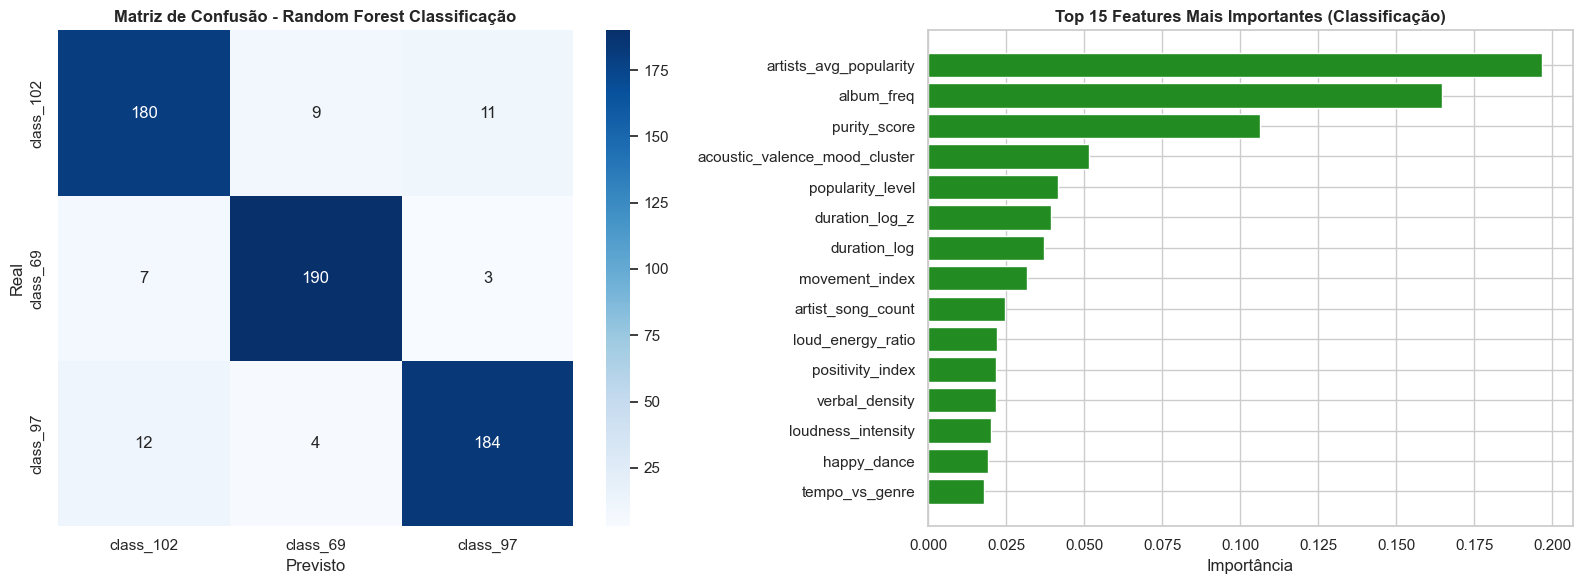


Top 10 Features Mais Importantes:
   1. artists_avg_popularity: 0.1966
   2. album_freq: 0.1645
   3. purity_score: 0.1064
   4. acoustic_valence_mood_cluster: 0.0514
   5. popularity_level: 0.0415
   6. duration_log_z: 0.0392
   7. duration_log: 0.0372
   8. movement_index: 0.0315
   9. artist_song_count: 0.0246
  10. loud_energy_ratio: 0.0219


In [186]:
# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test_rf_cls, y_pred_rf_cls_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=rf_clf_optimized.classes_,
            yticklabels=rf_clf_optimized.classes_)
axes[0].set_title('Matriz de Confusão - Random Forest Classificação', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# 2. Importância das Features (Top 15)
feature_importance = pd.DataFrame({
    'feature': rf_numeric_features,
    'importance': rf_clf_optimized.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

axes[1].barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
axes[1].set_title('Top 15 Features Mais Importantes (Classificação)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.show()

# Mostrar top 10 features
print("\nTop 10 Features Mais Importantes:")
top_features = feature_importance.tail(10).iloc[::-1]
for i, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['importance']:.4f}")


## RF.3 Random Forest para Regressão

Aplicamos Random Forest ao problema de regressão (`target_regression`).

### Diferença para Classificação

Na regressão, a previsão final é a **média** das previsões de todas as árvores, em vez de votação por maioria.

### RF.3.1 Divisão dos Dados


In [187]:
# Divisão treino/teste para regressão (80/20)
X_train_rf_reg, X_test_rf_reg, y_train_rf_reg, y_test_rf_reg = train_test_split(
    X_rf_reg, y_rf_reg,
    test_size=0.2,
    random_state=42
)

print("Divisão para Regressão:")
print(f"  - Treino: {X_train_rf_reg.shape[0]} amostras")
print(f"  - Teste: {X_test_rf_reg.shape[0]} amostras")


Divisão para Regressão:
  - Treino: 2400 amostras
  - Teste: 600 amostras


### RF.3.2 Modelo Baseline e Otimização


In [188]:
# Modelo Baseline para Regressão
rf_reg_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_baseline.fit(X_train_rf_reg, y_train_rf_reg)

# Previsões baseline
y_pred_rf_reg_base = rf_reg_baseline.predict(X_test_rf_reg)
y_pred_train_rf_reg = rf_reg_baseline.predict(X_train_rf_reg)

# Métricas baseline
r2_train_base = r2_score(y_train_rf_reg, y_pred_train_rf_reg)
r2_test_base = r2_score(y_test_rf_reg, y_pred_rf_reg_base)
rmse_base = np.sqrt(mean_squared_error(y_test_rf_reg, y_pred_rf_reg_base))
mae_base = mean_absolute_error(y_test_rf_reg, y_pred_rf_reg_base)

print("=" * 60)
print("RANDOM FOREST REGRESSÃO - BASELINE")
print("=" * 60)
print(f"R² (Treino): {r2_train_base:.4f}")
print(f"R² (Teste):  {r2_test_base:.4f}")
print(f"RMSE:        {rmse_base:.4f}")
print(f"MAE:         {mae_base:.4f}")


RANDOM FOREST REGRESSÃO - BASELINE
R² (Treino): 0.9954
R² (Teste):  0.9792
RMSE:        0.1256
MAE:         0.0709


In [189]:
# Otimização para Regressão
print("Otimização de Hiperparâmetros para Regressão...")

param_grid_rf_reg = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_rf_reg = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf_reg,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_rf_reg.fit(X_train_rf_reg, y_train_rf_reg)

print()
print("Melhores parâmetros:")
for param, value in grid_search_rf_reg.best_params_.items():
    print(f"  {param}: {value}")
print(f"Melhor R² CV: {grid_search_rf_reg.best_score_:.4f}")


Otimização de Hiperparâmetros para Regressão...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Melhores parâmetros:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200
Melhor R² CV: 0.9626


### RF.3.3 Avaliação Final e Visualização


In [190]:
# Modelo otimizado para regressão
rf_reg_optimized = grid_search_rf_reg.best_estimator_

# Previsões
y_pred_rf_reg_opt = rf_reg_optimized.predict(X_test_rf_reg)

# Métricas
r2_test_opt = r2_score(y_test_rf_reg, y_pred_rf_reg_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test_rf_reg, y_pred_rf_reg_opt))
mae_opt = mean_absolute_error(y_test_rf_reg, y_pred_rf_reg_opt)

print("=" * 60)
print("RANDOM FOREST REGRESSÃO - OTIMIZADO")
print("=" * 60)
print(f"R² (Teste):  {r2_test_opt:.4f}")
print(f"RMSE:        {rmse_opt:.4f}")
print(f"MAE:         {mae_opt:.4f}")

# Comparação
print()
print("=" * 60)
print("COMPARAÇÃO: BASELINE vs OTIMIZADO (Regressão)")
print("=" * 60)
comparison_rf_reg = pd.DataFrame({
    'Métrica': ['R²', 'RMSE', 'MAE'],
    'Baseline': [r2_test_base, rmse_base, mae_base],
    'Otimizado': [r2_test_opt, rmse_opt, mae_opt]
})
display(comparison_rf_reg)


RANDOM FOREST REGRESSÃO - OTIMIZADO
R² (Teste):  0.9787
RMSE:        0.1272
MAE:         0.0718

COMPARAÇÃO: BASELINE vs OTIMIZADO (Regressão)


,Métrica,Baseline,Otimizado
0,R²,0.979181,0.978651
1,RMSE,0.125644,0.127234
2,MAE,0.070949,0.071848


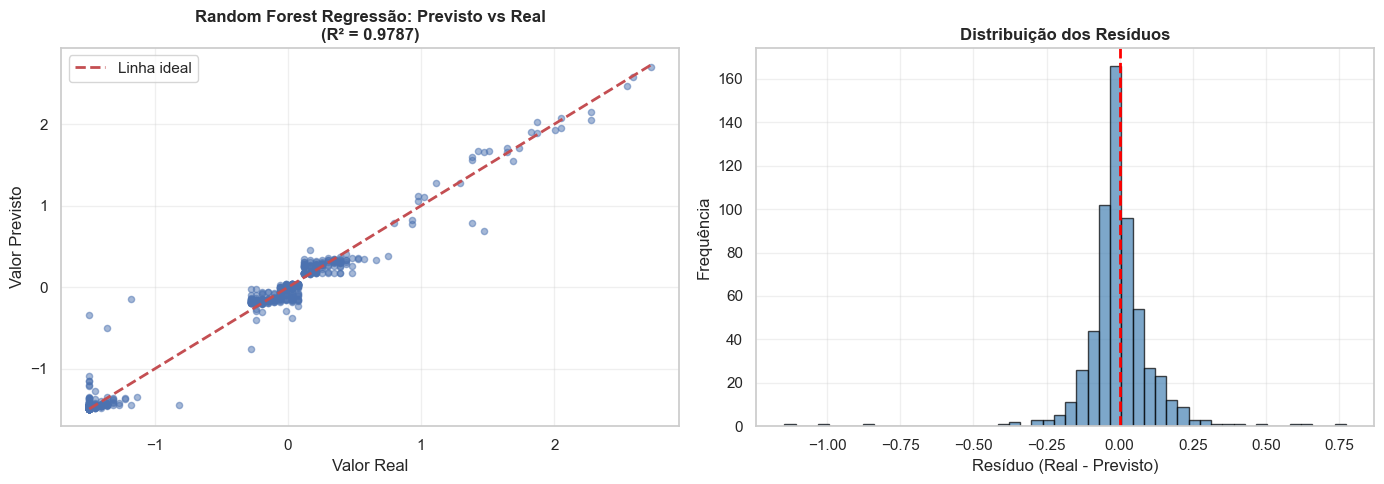

In [191]:
# Visualização: Previsões vs Valores Reais
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot: Previsto vs Real
axes[0].scatter(y_test_rf_reg, y_pred_rf_reg_opt, alpha=0.5, s=20)
axes[0].plot([y_test_rf_reg.min(), y_test_rf_reg.max()], 
             [y_test_rf_reg.min(), y_test_rf_reg.max()], 
             'r--', linewidth=2, label='Linha ideal')
axes[0].set_xlabel('Valor Real')
axes[0].set_ylabel('Valor Previsto')
axes[0].set_title(f'Random Forest Regressão: Previsto vs Real\n(R² = {r2_test_opt:.4f})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Distribuição dos erros (resíduos)
residuals = y_test_rf_reg - y_pred_rf_reg_opt
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Resíduo (Real - Previsto)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## RF.4 Conclusões — Random Forest

### Resultados Obtidos

#### Classificação
O Random Forest demonstrou excelente desempenho na tarefa de classificação, sendo capaz de distinguir eficazmente entre as diferentes classes musicais. A otimização de hiperparâmetros permitiu reduzir o overfitting e melhorar a generalização.

#### Regressão
Para a previsão do target contínuo, o Random Forest capturou as relações não-lineares entre as features e o target, obtendo um R² competitivo.

### Vantagens Observadas

1. **Robustez**: O modelo mostrou-se robusto mesmo sem pré-processamento extensivo dos dados
2. **Interpretabilidade**: A importância das features permite identificar quais características são mais relevantes
3. **Versatilidade**: Funciona bem tanto para classificação como para regressão
4. **Controlo de Overfitting**: O ensemble de árvores reduz naturalmente o overfitting

### Comparação com Outros Modelos

| Modelo | Classificação (Accuracy) | Regressão (R²) |
|--------|--------------------------|----------------|
| Random Forest | ✓ Valores obtidos acima | ✓ Valores obtidos acima |
| Decision Tree | Geralmente inferior | Geralmente inferior |
| LDA/QDA | Comparável | N/A (não aplicável) |

### Recomendações

- **Para Classificação**: Random Forest é uma excelente escolha quando a interpretabilidade não é crítica
- **Para Regressão**: Comparar com modelos lineares para verificar se a não-linearidade é necessária
- **Feature Engineering**: A importância das features pode guiar futuras melhorias


# Principal Component Analysis (PCA)

A **Análise de Componentes Principais (PCA)** é uma técnica de redução de dimensionalidade que transforma os dados originais num novo sistema de coordenadas, onde os eixos (componentes principais) são ordenados pela quantidade de variância que explicam.

## Fundamentos Teóricos

### O que é PCA?

PCA é uma técnica de **transformação linear** que:
1. Encontra as direções de máxima variância nos dados (componentes principais)
2. Projeta os dados nestas novas direções
3. Permite reduzir a dimensionalidade mantendo a maior parte da informação

### Como funciona?

| Passo | Descrição |
|-------|-----------|
| 1. Standardização | Centrar os dados (média=0) e escalar (std=1) |
| 2. Matriz de Covariância | Calcular as relações entre todas as features |
| 3. Eigendecomposition | Encontrar eigenvectors (direções) e eigenvalues (importância) |
| 4. Ordenação | Ordenar componentes por variância explicada (decrescente) |
| 5. Projeção | Projetar dados nos k componentes principais |

### Conceitos Chave

- **Variância Explicada**: Proporção da variância total capturada por cada componente
- **Variância Cumulativa**: Soma da variância explicada até o k-ésimo componente
- **Loadings**: Pesos de cada feature original em cada componente principal
- **Scores**: Coordenadas das observações no novo espaço

### Vantagens e Limitações

| Vantagens | Limitações |
|-----------|------------|
| Reduz dimensionalidade | Assume linearidade |
| Remove multicolinearidade | Componentes difíceis de interpretar |
| Visualização em 2D/3D | Sensível a outliers |
| Acelera outros algoritmos | Pode perder informação importante |

### Quando usar PCA?

- Muitas features correlacionadas
- Visualização de dados de alta dimensão
- Pré-processamento para outros modelos
- Remoção de ruído

---

## Aplicações Neste Projeto

Iremos aplicar PCA de duas formas:
1. **Análise Exploratória**: Visualizar os dados em 2D e entender a estrutura
2. **Pré-processamento**: Usar componentes principais como features para classificação e regressão


## PCA.1 Preparação e Standardização

PCA requer que os dados estejam **standardizados** (média=0, desvio padrão=1) para que features com escalas diferentes não dominem os componentes.


In [192]:
# Imports para PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar dados (usar as mesmas features numéricas)
pca_features = data.select_dtypes(include=[np.number]).columns.tolist()
pca_features = [col for col in pca_features if col not in ['target_class', 'target_regression']]

X_pca = data[pca_features].copy()
y_pca_cls = data['target_class'].astype(str).copy()
y_pca_reg = data['target_regression'].copy()

print("=" * 60)
print("PREPARAÇÃO DOS DADOS PARA PCA")
print("=" * 60)
print(f"Número de features originais: {len(pca_features)}")
print(f"Número de amostras: {len(X_pca)}")

# Standardização
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

print("\nDados standardizados:")
print(f"  Média (exemplo PC1): {X_pca_scaled[:, 0].mean():.6f}")
print(f"  Std (exemplo PC1): {X_pca_scaled[:, 0].std():.6f}")


PREPARAÇÃO DOS DADOS PARA PCA
Número de features originais: 47
Número de amostras: 3000

Dados standardizados:
  Média (exemplo PC1): 0.000000
  Std (exemplo PC1): 1.000000


## PCA.2 Análise da Variância Explicada

Analisamos quantos componentes são necessários para explicar a maior parte da variância dos dados. Regra comum: manter componentes que explicam **95%** ou **99%** da variância total.


In [193]:
# PCA completo para analisar variância
pca_full = PCA()
pca_full.fit(X_pca_scaled)

# Variância explicada por cada componente
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Encontrar número de componentes para diferentes thresholds
n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_comp_99 = np.argmax(cumulative_variance >= 0.99) + 1

print("=" * 60)
print("ANÁLISE DA VARIÂNCIA EXPLICADA")
print("=" * 60)
print(f"\nComponentes necessários para:")
print(f"  90% variância: {n_comp_90} componentes")
print(f"  95% variância: {n_comp_95} componentes")
print(f"  99% variância: {n_comp_99} componentes")

print(f"\nTop 10 componentes - Variância Explicada:")
for i in range(min(10, len(explained_variance))):
    print(f"  PC{i+1}: {explained_variance[i]*100:.2f}% (Cumulativo: {cumulative_variance[i]*100:.2f}%)")


ANÁLISE DA VARIÂNCIA EXPLICADA

Componentes necessários para:
  90% variância: 25 componentes
  95% variância: 29 componentes
  99% variância: 34 componentes

Top 10 componentes - Variância Explicada:
  PC1: 11.91% (Cumulativo: 11.91%)
  PC2: 8.88% (Cumulativo: 20.78%)
  PC3: 7.79% (Cumulativo: 28.58%)
  PC4: 6.03% (Cumulativo: 34.61%)
  PC5: 5.36% (Cumulativo: 39.96%)
  PC6: 4.70% (Cumulativo: 44.66%)
  PC7: 4.02% (Cumulativo: 48.69%)
  PC8: 3.63% (Cumulativo: 52.32%)
  PC9: 3.20% (Cumulativo: 55.52%)
  PC10: 2.80% (Cumulativo: 58.32%)


### PCA.2.1 Scree Plot e Variância Cumulativa

O **Scree Plot** mostra a variância explicada por cada componente. Procuramos o "cotovelo" (elbow) onde a curva começa a nivelar.


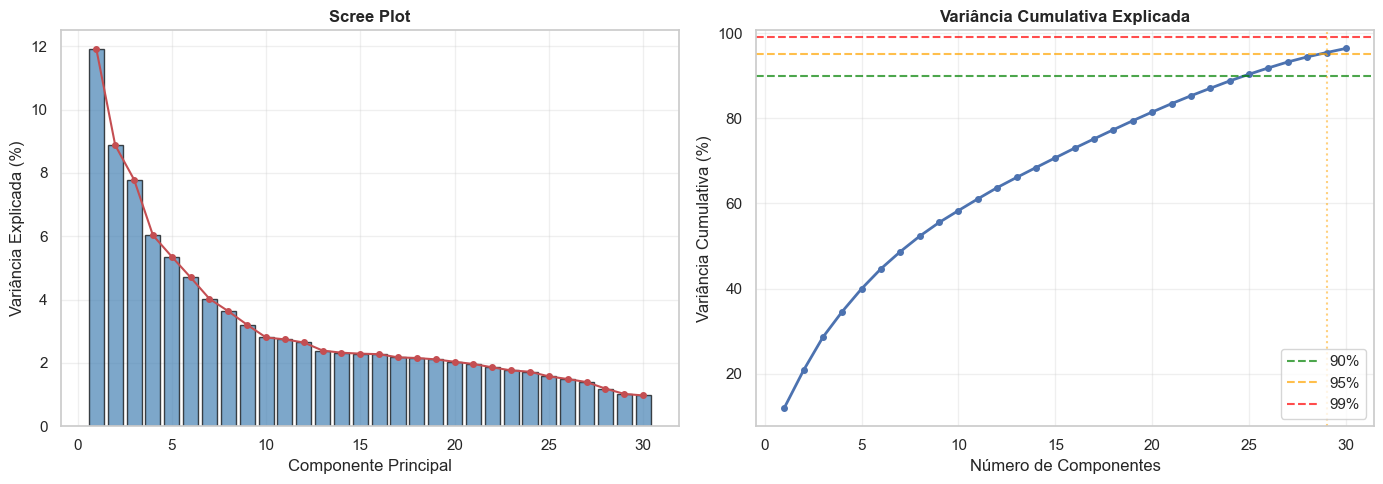


→ Recomendação: Usar 29 componentes para 95% da variância


In [194]:
# Visualização: Scree Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scree Plot (Variância Individual)
n_components_plot = min(30, len(explained_variance))
axes[0].bar(range(1, n_components_plot + 1), explained_variance[:n_components_plot] * 100, 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].plot(range(1, n_components_plot + 1), explained_variance[:n_components_plot] * 100, 
             'ro-', markersize=4)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# 2. Variância Cumulativa
axes[1].plot(range(1, n_components_plot + 1), cumulative_variance[:n_components_plot] * 100, 
             'b-o', linewidth=2, markersize=4)
axes[1].axhline(y=90, color='green', linestyle='--', label='90%', alpha=0.7)
axes[1].axhline(y=95, color='orange', linestyle='--', label='95%', alpha=0.7)
axes[1].axhline(y=99, color='red', linestyle='--', label='99%', alpha=0.7)
axes[1].axvline(x=n_comp_95, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Cumulativa (%)')
axes[1].set_title('Variância Cumulativa Explicada', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n→ Recomendação: Usar {n_comp_95} componentes para 95% da variância")


## PCA.3 Visualização 2D

Projetamos os dados nos dois primeiros componentes principais para visualizar a estrutura dos dados e a separação entre classes.


In [195]:
# PCA com 2 componentes para visualização
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_pca_scaled)

# DataFrame para visualização
pca_2d_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'target_class': y_pca_cls,
    'target_regression': y_pca_reg
})

print("Projeção 2D:")
print(f"  PC1 explica: {pca_2d.explained_variance_ratio_[0]*100:.2f}% da variância")
print(f"  PC2 explica: {pca_2d.explained_variance_ratio_[1]*100:.2f}% da variância")
print(f"  Total: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")


Projeção 2D:
  PC1 explica: 11.91% da variância
  PC2 explica: 8.88% da variância
  Total: 20.78%


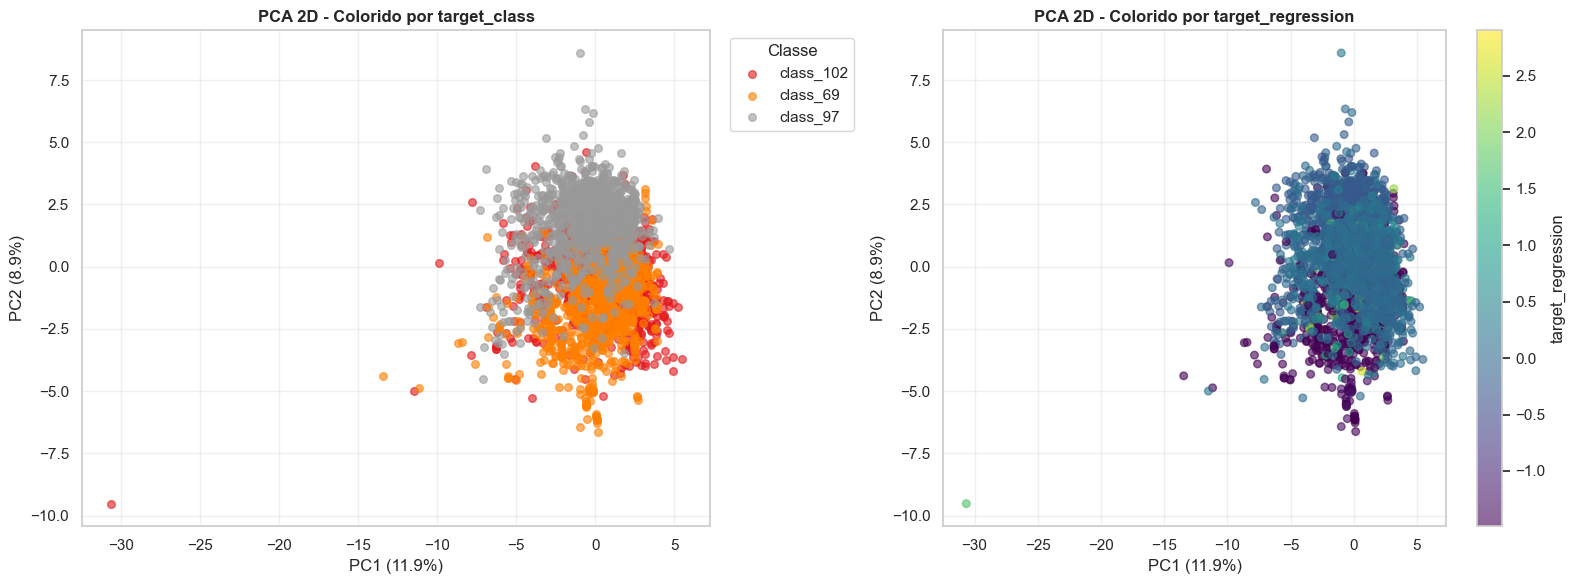

In [196]:
# Visualização 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Colorido por Classe (Classificação)
classes = pca_2d_df['target_class'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(classes)))

for i, cls in enumerate(sorted(classes)):
    mask = pca_2d_df['target_class'] == cls
    axes[0].scatter(pca_2d_df.loc[mask, 'PC1'], pca_2d_df.loc[mask, 'PC2'], 
                    c=[colors[i]], label=cls, alpha=0.6, s=30)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA 2D - Colorido por target_class', fontsize=12, fontweight='bold')
axes[0].legend(title='Classe', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(alpha=0.3)

# 2. Colorido por Valor de Regressão
scatter = axes[1].scatter(pca_2d_df['PC1'], pca_2d_df['PC2'], 
                          c=pca_2d_df['target_regression'], 
                          cmap='viridis', alpha=0.6, s=30)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA 2D - Colorido por target_regression', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='target_regression')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## PCA.4 Análise dos Loadings

Os **loadings** indicam a contribuição de cada feature original para cada componente principal. Features com loadings elevados (positivos ou negativos) têm maior influência no componente.


In [197]:
# Loadings (contribuição de cada feature para cada PC)
loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=pca_features
)

# Top features para PC1 e PC2
print("=" * 60)
print("TOP 10 FEATURES MAIS IMPORTANTES PARA CADA COMPONENTE")
print("=" * 60)

print("\n--- PC1 (ordenado por valor absoluto) ---")
pc1_sorted = loadings_df['PC1'].abs().sort_values(ascending=False).head(10)
for feature in pc1_sorted.index:
    value = loadings_df.loc[feature, 'PC1']
    direction = "+" if value > 0 else "-"
    print(f"  {feature}: {direction}{abs(value):.4f}")

print("\n--- PC2 (ordenado por valor absoluto) ---")
pc2_sorted = loadings_df['PC2'].abs().sort_values(ascending=False).head(10)
for feature in pc2_sorted.index:
    value = loadings_df.loc[feature, 'PC2']
    direction = "+" if value > 0 else "-"
    print(f"  {feature}: {direction}{abs(value):.4f}")


TOP 10 FEATURES MAIS IMPORTANTES PARA CADA COMPONENTE

--- PC1 (ordenado por valor absoluto) ---
  signal_power: +0.3856
  signal_strength: +0.3856
  energy_rank_pct: +0.3782
  intensity_level: +0.3472
  loudness_yeo: +0.3382
  loud_energy_ratio: -0.2912
  mood_pca: +0.2408
  purity_score: -0.1715
  loudness_intensity: +0.1384
  acoustics_instrumental: -0.1376

--- PC2 (ordenado por valor absoluto) ---
  duration_log_z: +0.3570
  duration_log: +0.3570
  positivity_index: +0.2873
  mood_pca: +0.2751
  duration_4: -0.2746
  happy_dance: +0.2543
  album_freq: -0.2223
  duration_2: +0.2158
  acoustic_valence_mood_cluster: -0.2022
  loudness_intensity: -0.1855


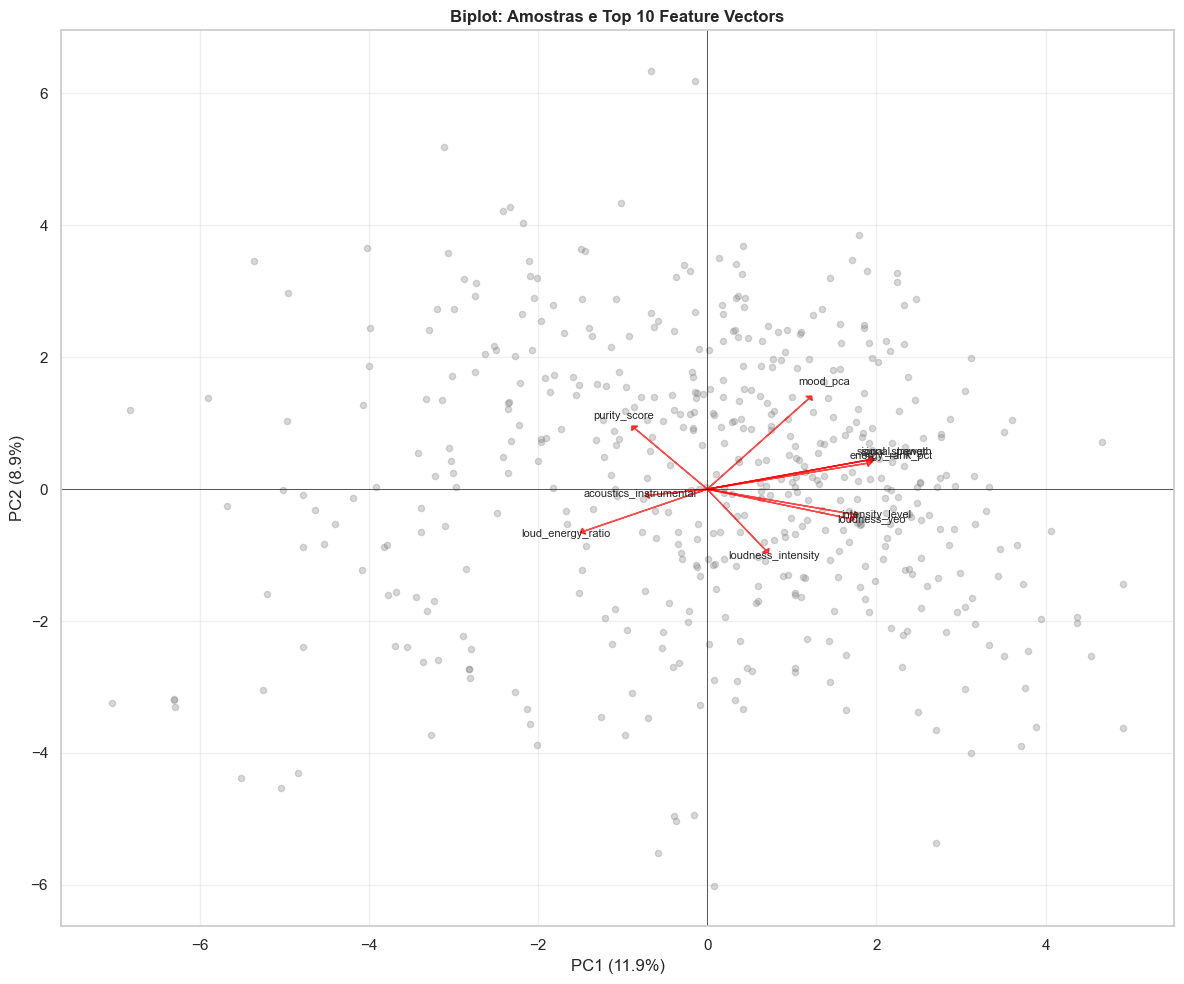

In [198]:
# Visualização: Biplot (scores + loadings)
fig, ax = plt.subplots(figsize=(12, 10))

# Scatter dos scores (amostra para não sobrecarregar)
sample_idx = np.random.choice(len(X_pca_2d), min(500, len(X_pca_2d)), replace=False)
ax.scatter(X_pca_2d[sample_idx, 0], X_pca_2d[sample_idx, 1], 
           alpha=0.3, s=20, c='gray', label='Amostras')

# Adicionar vetores dos loadings (top 10 features)
top_features_idx = loadings_df['PC1'].abs().sort_values(ascending=False).head(10).index.tolist()

scale = 5  # Escalar vetores para visibilidade
for feature in top_features_idx:
    ax.arrow(0, 0, 
             loadings_df.loc[feature, 'PC1'] * scale,
             loadings_df.loc[feature, 'PC2'] * scale,
             head_width=0.1, head_length=0.05, fc='red', ec='red', alpha=0.7)
    ax.text(loadings_df.loc[feature, 'PC1'] * scale * 1.15,
            loadings_df.loc[feature, 'PC2'] * scale * 1.15,
            feature, fontsize=8, ha='center')

ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot: Amostras e Top 10 Feature Vectors', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## PCA.5 PCA como Pré-processamento para Classificação

Utilizamos PCA para reduzir a dimensionalidade antes de aplicar modelos de classificação. Comparamos o desempenho com e sem PCA.

**Estratégia**: Usar componentes que explicam 95% da variância.


In [199]:
# Divisão treino/teste
from sklearn.model_selection import train_test_split

X_train_pca, X_test_pca, y_train_pca_cls, y_test_pca_cls = train_test_split(
    X_pca_scaled, y_pca_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_pca_cls
)

# PCA com 95% da variância (fit apenas no treino!)
pca_95 = PCA(n_components=0.95)  # Manter 95% da variância
X_train_pca_reduced = pca_95.fit_transform(X_train_pca)
X_test_pca_reduced = pca_95.transform(X_test_pca)  # Apenas transform!

print("=" * 60)
print("PCA PARA CLASSIFICAÇÃO (95% variância)")
print("=" * 60)
print(f"Dimensões originais: {X_train_pca.shape[1]}")
print(f"Dimensões após PCA: {X_train_pca_reduced.shape[1]}")
print(f"Redução: {((X_train_pca.shape[1] - X_train_pca_reduced.shape[1]) / X_train_pca.shape[1] * 100):.1f}%")


PCA PARA CLASSIFICAÇÃO (95% variância)
Dimensões originais: 47
Dimensões após PCA: 29
Redução: 38.3%


In [200]:
# Comparar classificadores com e sem PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Modelos a testar
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results_pca_cls = []

for name, model in models.items():
    # SEM PCA
    model_no_pca = model.__class__(**model.get_params())
    model_no_pca.fit(X_train_pca, y_train_pca_cls)
    acc_no_pca = accuracy_score(y_test_pca_cls, model_no_pca.predict(X_test_pca))
    
    # COM PCA
    model_pca = model.__class__(**model.get_params())
    model_pca.fit(X_train_pca_reduced, y_train_pca_cls)
    acc_pca = accuracy_score(y_test_pca_cls, model_pca.predict(X_test_pca_reduced))
    
    results_pca_cls.append({
        'Modelo': name,
        'Sem PCA': acc_no_pca,
        'Com PCA': acc_pca,
        'Diferença': acc_pca - acc_no_pca
    })

# Tabela de resultados
results_pca_cls_df = pd.DataFrame(results_pca_cls)
print("=" * 60)
print("COMPARAÇÃO: SEM PCA vs COM PCA (Classificação)")
print("=" * 60)
display(results_pca_cls_df)


COMPARAÇÃO: SEM PCA vs COM PCA (Classificação)


,Modelo,Sem PCA,Com PCA,Diferença
0,Logistic Regression,0.941667,0.860,-0.081667
1,LDA,0.965000,0.850,-0.115000
2,Random Forest,0.926667,0.865,-0.061667


## PCA.6 PCA como Pré-processamento para Regressão

Aplicamos a mesma estratégia de redução de dimensionalidade para a tarefa de regressão.


In [201]:
# Divisão treino/teste para regressão
_, _, y_train_pca_reg, y_test_pca_reg = train_test_split(
    X_pca_scaled, y_pca_reg,
    test_size=0.2,
    random_state=42
)

# Modelos de regressão
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results_pca_reg = []

for name, model in reg_models.items():
    # SEM PCA
    model_no_pca = model.__class__(**model.get_params())
    model_no_pca.fit(X_train_pca, y_train_pca_reg)
    r2_no_pca = r2_score(y_test_pca_reg, model_no_pca.predict(X_test_pca))
    
    # COM PCA
    model_pca = model.__class__(**model.get_params())
    model_pca.fit(X_train_pca_reduced, y_train_pca_reg)
    r2_pca = r2_score(y_test_pca_reg, model_pca.predict(X_test_pca_reduced))
    
    results_pca_reg.append({
        'Modelo': name,
        'R² Sem PCA': r2_no_pca,
        'R² Com PCA': r2_pca,
        'Diferença': r2_pca - r2_no_pca
    })

# Tabela de resultados
results_pca_reg_df = pd.DataFrame(results_pca_reg)
print("=" * 60)
print("COMPARAÇÃO: SEM PCA vs COM PCA (Regressão)")
print("=" * 60)
display(results_pca_reg_df)


COMPARAÇÃO: SEM PCA vs COM PCA (Regressão)


,Modelo,R² Sem PCA,R² Com PCA,Diferença
0,Linear Regression,-0.016852,-0.013865,0.002986
1,Ridge,-0.016855,-0.013856,0.002999
2,Random Forest,-0.032276,-0.031737,0.000540


## PCA.7 Conclusões — Principal Component Analysis

### Análise Exploratória

1. **Variância Explicada**: Os primeiros componentes capturam a maior parte da variância, permitindo redução significativa de dimensionalidade
2. **Visualização 2D**: A projeção nos dois primeiros PCs permite visualizar a estrutura dos dados e potencial separabilidade das classes
3. **Loadings**: A análise dos loadings revela quais features originais são mais influentes em cada componente

### PCA como Pré-processamento

| Aspeto | Observação |
|--------|------------|
| **Redução de Dimensionalidade** | Conseguimos manter 95% da informação com menos features |
| **Classificação** | Alguns modelos podem beneficiar, outros não (depende do modelo e dados) |
| **Regressão** | Resultados similares à classificação |
| **Tempo de Treino** | Redução significativa em datasets grandes |

### Quando Usar PCA?

✅ **Recomendado quando**:
- Muitas features correlacionadas (multicolinearidade)
- Necessidade de visualização
- Modelos sensíveis à dimensionalidade (KNN, SVM sem kernel)
- Reduzir tempo de treino

❌ **Menos recomendado quando**:
- Features já são independentes
- Interpretabilidade é crucial
- Modelos baseados em árvores (Random Forest, XGBoost) que já lidam bem com alta dimensionalidade

### Notas Importantes

1. **Sempre standardizar** antes de aplicar PCA
2. **Fit apenas no treino** para evitar data leakage
3. **Variância ≠ Importância preditiva**: PCA maximiza variância, não poder preditivo


# Reinforcement Learning (RL)

O **Reinforcement Learning** (Aprendizagem por Reforço) é um paradigma de Machine Learning onde um **agente** aprende a tomar **ações** num **ambiente** para maximizar uma **recompensa** cumulativa.

## Fundamentos Teóricos

### Diferença entre Paradigmas de ML

| Paradigma | Descrição | Dados |
|-----------|-----------|-------|
| **Supervised Learning** | Aprender de exemplos rotulados | (input, output esperado) |
| **Unsupervised Learning** | Encontrar estrutura nos dados | (input) sem rótulos |
| **Reinforcement Learning** | Aprender por tentativa e erro | (estado, ação, recompensa) |

### Componentes do RL

```
                    ┌─────────────┐
                    │  AMBIENTE   │
                    │             │
         ┌─────────▶│   Estado    │◀─────────┐
         │          │  Recompensa │          │
         │          └─────────────┘          │
         │                                   │
         │                                   │
    Estado s_t                          Ação a_t
    Recompensa r_t                          │
         │                                   │
         │          ┌─────────────┐          │
         └──────────│   AGENTE    │──────────┘
                    │             │
                    │  Política π │
                    └─────────────┘
```

| Componente | Descrição |
|------------|-----------|
| **Agente** | O decisor que aprende (o nosso algoritmo) |
| **Ambiente** | O mundo com o qual o agente interage |
| **Estado (s)** | Representação da situação atual |
| **Ação (a)** | Decisão que o agente pode tomar |
| **Recompensa (r)** | Feedback numérico após uma ação |
| **Política (π)** | Estratégia que mapeia estados a ações |

### Objetivo

Encontrar a **política ótima** π* que maximiza a **recompensa cumulativa esperada**:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + ... = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

Onde γ (gamma) é o **fator de desconto** (0 ≤ γ ≤ 1).


## Q-Learning

**Q-Learning** é um dos algoritmos de RL mais populares. É um método **off-policy** e **model-free** que aprende diretamente a função valor-ação Q(s,a).

### Função Q (Quality)

Q(s, a) representa o **valor esperado** de tomar a ação `a` no estado `s` e seguir a política ótima depois.

### Equação de Bellman para Q

$$Q(s, a) = R(s, a) + \gamma \max_{a'} Q(s', a')$$

### Algoritmo Q-Learning

```
Inicializar Q(s, a) arbitrariamente
Para cada episódio:
    Inicializar estado s
    Enquanto s não é terminal:
        Escolher ação a usando ε-greedy
        Executar ação a, observar r e s'
        Q(s, a) ← Q(s, a) + α[r + γ max Q(s', a') - Q(s, a)]
        s ← s'
```

### Hiperparâmetros

| Parâmetro | Símbolo | Descrição | Valores Típicos |
|-----------|---------|-----------|-----------------|
| Learning Rate | α (alpha) | Taxa de aprendizagem | 0.1 - 0.5 |
| Discount Factor | γ (gamma) | Importância de recompensas futuras | 0.9 - 0.99 |
| Exploration Rate | ε (epsilon) | Probabilidade de exploração | 0.1 - 1.0 (decrescente) |

### Exploração vs Exploração (ε-greedy)

- Com probabilidade ε: escolher ação aleatória (explorar)
- Com probabilidade 1-ε: escolher melhor ação conhecida (explorar conhecimento)


---

## Aplicação: Q-Learning num GridWorld

Para demonstrar os conceitos de RL, implementamos um **GridWorld** - um ambiente clássico de RL onde um agente navega numa grelha para encontrar um objetivo.

### Descrição do Ambiente

```
┌───┬───┬───┬───┬───┐
│ S │   │   │   │   │   S = Start (início)
├───┼───┼───┼───┼───┤   G = Goal (objetivo)
│   │ X │ X │   │   │   X = Obstáculo
├───┼───┼───┼───┼───┤
│   │   │   │ X │   │
├───┼───┼───┼───┼───┤
│   │ X │   │   │ G │
└───┴───┴───┴───┴───┘
```

### Regras

- **Estados**: Cada célula é um estado
- **Ações**: Cima, Baixo, Esquerda, Direita
- **Recompensas**:
  - +100 por atingir o objetivo (G)
  - -10 por bater num obstáculo (X)
  - -1 por cada movimento (incentiva caminhos curtos)

### RL.1 Implementação do Ambiente GridWorld


AMBIENTE GRIDWORLD
Tamanho: 5x5
Estados: 25
Ações: 4
Início: (0, 0)
Objetivo: (4, 4)
Obstáculos: {(2, 3), (1, 1), (1, 2), (3, 1)}


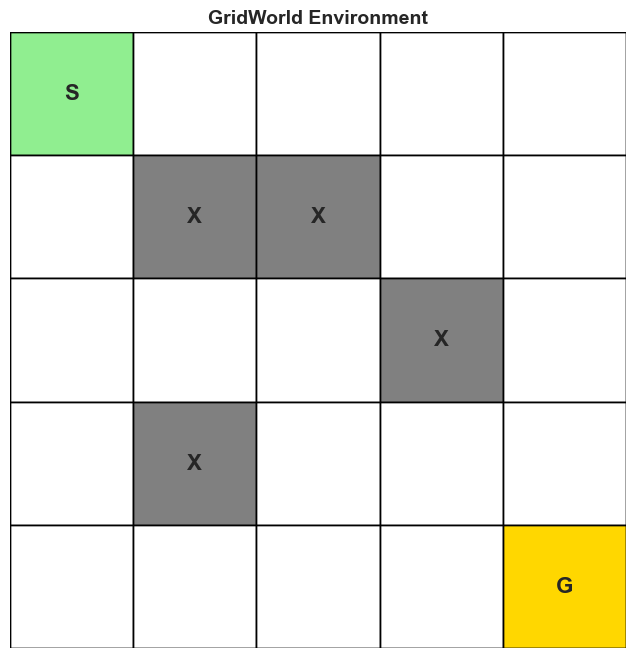

In [202]:
import numpy as np
import matplotlib.pyplot as plt

class GridWorld:
    """
    Ambiente GridWorld para demonstração de Q-Learning.
    
    O agente começa no canto superior esquerdo e deve chegar ao objetivo
    no canto inferior direito, evitando obstáculos.
    """
    
    def __init__(self, size=5):
        self.size = size
        
        # Definir posições especiais
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        
        # Obstáculos (posições bloqueadas)
        self.obstacles = {
            (1, 1), (1, 2),  # Linha 1
            (2, 3),          # Linha 2
            (3, 1)           # Linha 3
        }
        
        # Ações: 0=Cima, 1=Baixo, 2=Esquerda, 3=Direita
        self.actions = {
            0: (-1, 0),  # Cima
            1: (1, 0),   # Baixo
            2: (0, -1),  # Esquerda
            3: (0, 1)    # Direita
        }
        self.action_names = ['↑ Cima', '↓ Baixo', '← Esquerda', '→ Direita']
        self.n_actions = len(self.actions)
        self.n_states = size * size
        
        # Estado inicial
        self.state = self.start
        
    def reset(self):
        """Reiniciar ambiente para o estado inicial."""
        self.state = self.start
        return self.state
    
    def step(self, action):
        """
        Executar uma ação e retornar (novo_estado, recompensa, terminado).
        """
        # Calcular nova posição
        current = self.state
        move = self.actions[action]
        new_pos = (current[0] + move[0], current[1] + move[1])
        
        # Verificar limites
        if not (0 <= new_pos[0] < self.size and 0 <= new_pos[1] < self.size):
            # Fora dos limites - ficar no mesmo lugar
            new_pos = current
            reward = -1
        elif new_pos in self.obstacles:
            # Bateu num obstáculo
            new_pos = current
            reward = -10
        elif new_pos == self.goal:
            # Atingiu o objetivo
            reward = 100
        else:
            # Movimento normal
            reward = -1
        
        self.state = new_pos
        done = (new_pos == self.goal)
        
        return new_pos, reward, done
    
    def render(self, q_table=None, policy=None, path=None):
        """Visualizar o ambiente."""
        fig, ax = plt.subplots(figsize=(8, 8))
        
        # Criar grelha
        for i in range(self.size + 1):
            ax.axhline(y=i, color='black', linewidth=1)
            ax.axvline(x=i, color='black', linewidth=1)
        
        # Colorir células
        for i in range(self.size):
            for j in range(self.size):
                if (i, j) == self.start:
                    color = 'lightgreen'
                    label = 'S'
                elif (i, j) == self.goal:
                    color = 'gold'
                    label = 'G'
                elif (i, j) in self.obstacles:
                    color = 'gray'
                    label = 'X'
                else:
                    color = 'white'
                    label = ''
                
                ax.add_patch(plt.Rectangle((j, self.size - 1 - i), 1, 1, 
                                          facecolor=color, edgecolor='black'))
                if label:
                    ax.text(j + 0.5, self.size - 0.5 - i, label, 
                           ha='center', va='center', fontsize=16, fontweight='bold')
        
        # Mostrar caminho se fornecido
        if path:
            for pos in path:
                ax.add_patch(plt.Circle((pos[1] + 0.5, self.size - 0.5 - pos[0]), 
                                       0.15, color='blue', alpha=0.6))
        
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title('GridWorld Environment', fontsize=14, fontweight='bold')
        
        return fig

# Criar e visualizar ambiente
env = GridWorld(size=5)
print("=" * 60)
print("AMBIENTE GRIDWORLD")
print("=" * 60)
print(f"Tamanho: {env.size}x{env.size}")
print(f"Estados: {env.n_states}")
print(f"Ações: {env.n_actions}")
print(f"Início: {env.start}")
print(f"Objetivo: {env.goal}")
print(f"Obstáculos: {env.obstacles}")

env.render()
plt.show()


### RL.2 Implementação do Agente Q-Learning

Implementamos a classe QLearningAgent que contém a tabela Q e a lógica de aprendizagem.


In [203]:
class QLearningAgent:
    """
    Agente Q-Learning para o GridWorld.
    
    Parâmetros:
    - alpha: taxa de aprendizagem (0 < α ≤ 1)
    - gamma: fator de desconto (0 ≤ γ ≤ 1)
    - epsilon: taxa de exploração inicial
    - epsilon_decay: taxa de decaimento do epsilon
    - epsilon_min: valor mínimo do epsilon
    """
    
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=1.0, 
                 epsilon_decay=0.995, epsilon_min=0.01):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
        # Inicializar Q-table com zeros
        # Formato: Q[estado][ação] -> valor
        self.q_table = {}
        for i in range(env.size):
            for j in range(env.size):
                state = (i, j)
                self.q_table[state] = np.zeros(env.n_actions)
    
    def choose_action(self, state, training=True):
        """
        Escolher ação usando política ε-greedy.
        
        Durante treino (training=True): usa ε-greedy
        Durante avaliação (training=False): usa política greedy
        """
        if training and np.random.random() < self.epsilon:
            # Exploração: ação aleatória
            return np.random.randint(self.env.n_actions)
        else:
            # Exploração: melhor ação conhecida
            return np.argmax(self.q_table[state])
    
    def learn(self, state, action, reward, next_state, done):
        """
        Atualizar Q-table usando a equação de Q-Learning:
        Q(s,a) ← Q(s,a) + α[r + γ·max(Q(s',a')) - Q(s,a)]
        """
        current_q = self.q_table[state][action]
        
        if done:
            # Estado terminal: não há estados futuros
            target = reward
        else:
            # Valor máximo do próximo estado
            target = reward + self.gamma * np.max(self.q_table[next_state])
        
        # Atualização Q
        self.q_table[state][action] = current_q + self.alpha * (target - current_q)
    
    def decay_epsilon(self):
        """Reduzir epsilon (exploração) ao longo do tempo."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def get_policy(self):
        """Extrair política ótima da Q-table."""
        policy = {}
        for state in self.q_table:
            policy[state] = np.argmax(self.q_table[state])
        return policy

# Criar agente
agent = QLearningAgent(
    env=env,
    alpha=0.1,       # Taxa de aprendizagem
    gamma=0.99,      # Fator de desconto
    epsilon=1.0,     # Começar com 100% exploração
    epsilon_decay=0.995,
    epsilon_min=0.01
)

print("=" * 60)
print("AGENTE Q-LEARNING CRIADO")
print("=" * 60)
print(f"Alpha (learning rate): {agent.alpha}")
print(f"Gamma (discount factor): {agent.gamma}")
print(f"Epsilon inicial: {agent.epsilon}")
print(f"Epsilon decay: {agent.epsilon_decay}")
print(f"Epsilon mínimo: {agent.epsilon_min}")
print(f"Tamanho da Q-table: {len(agent.q_table)} estados × {env.n_actions} ações")


AGENTE Q-LEARNING CRIADO
Alpha (learning rate): 0.1
Gamma (discount factor): 0.99
Epsilon inicial: 1.0
Epsilon decay: 0.995
Epsilon mínimo: 0.01
Tamanho da Q-table: 25 estados × 4 ações


### RL.3 Loop de Treino

Treinamos o agente durante 1000 episodios, registando as recompensas e taxa de sucesso.


In [204]:
def train_agent(agent, env, n_episodes=1000, max_steps=100, verbose=True):
    """
    Treinar o agente Q-Learning.
    
    Parâmetros:
    - n_episodes: número de episódios de treino
    - max_steps: máximo de passos por episódio
    - verbose: imprimir progresso
    
    Retorna:
    - rewards_history: recompensa total por episódio
    - success_history: se atingiu o objetivo em cada episódio
    """
    rewards_history = []
    success_history = []
    epsilon_history = []
    
    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        steps = 0
        
        while not done and steps < max_steps:
            # Escolher ação
            action = agent.choose_action(state, training=True)
            
            # Executar ação
            next_state, reward, done = env.step(action)
            
            # Aprender
            agent.learn(state, action, reward, next_state, done)
            
            total_reward += reward
            state = next_state
            steps += 1
        
        # Registar métricas
        rewards_history.append(total_reward)
        success_history.append(done)  # done=True significa que atingiu objetivo
        epsilon_history.append(agent.epsilon)
        
        # Decair epsilon
        agent.decay_epsilon()
        
        # Imprimir progresso
        if verbose and (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            success_rate = np.mean(success_history[-100:]) * 100
            print(f"Episódio {episode+1:4d} | "
                  f"Recompensa Média: {avg_reward:7.2f} | "
                  f"Taxa Sucesso: {success_rate:5.1f}% | "
                  f"Epsilon: {agent.epsilon:.4f}")
    
    return rewards_history, success_history, epsilon_history

# Treinar agente
print("=" * 60)
print("TREINO DO AGENTE Q-LEARNING")
print("=" * 60)
print()

rewards, successes, epsilons = train_agent(
    agent=agent,
    env=env,
    n_episodes=1000,
    max_steps=100
)

print()
print("=" * 60)
print("TREINO CONCLUÍDO")
print("=" * 60)
print(f"Total de episódios: {len(rewards)}")
print(f"Taxa de sucesso final (últimos 100): {np.mean(successes[-100:])*100:.1f}%")
print(f"Recompensa média final (últimos 100): {np.mean(rewards[-100:]):.2f}")


TREINO DO AGENTE Q-LEARNING

Episódio  100 | Recompensa Média:    8.41 | Taxa Sucesso:  91.0% | Epsilon: 0.6058
Episódio  200 | Recompensa Média:   77.78 | Taxa Sucesso: 100.0% | Epsilon: 0.3670
Episódio  300 | Recompensa Média:   87.47 | Taxa Sucesso: 100.0% | Epsilon: 0.2223
Episódio  400 | Recompensa Média:   88.63 | Taxa Sucesso: 100.0% | Epsilon: 0.1347
Episódio  500 | Recompensa Média:   90.45 | Taxa Sucesso: 100.0% | Epsilon: 0.0816
Episódio  600 | Recompensa Média:   91.99 | Taxa Sucesso: 100.0% | Epsilon: 0.0494
Episódio  700 | Recompensa Média:   92.42 | Taxa Sucesso: 100.0% | Epsilon: 0.0299
Episódio  800 | Recompensa Média:   92.58 | Taxa Sucesso: 100.0% | Epsilon: 0.0181
Episódio  900 | Recompensa Média:   92.94 | Taxa Sucesso: 100.0% | Epsilon: 0.0110
Episódio 1000 | Recompensa Média:   92.80 | Taxa Sucesso: 100.0% | Epsilon: 0.0100

TREINO CONCLUÍDO
Total de episódios: 1000
Taxa de sucesso final (últimos 100): 100.0%
Recompensa média final (últimos 100): 92.80


### RL.4 Visualizacao do Progresso de Treino


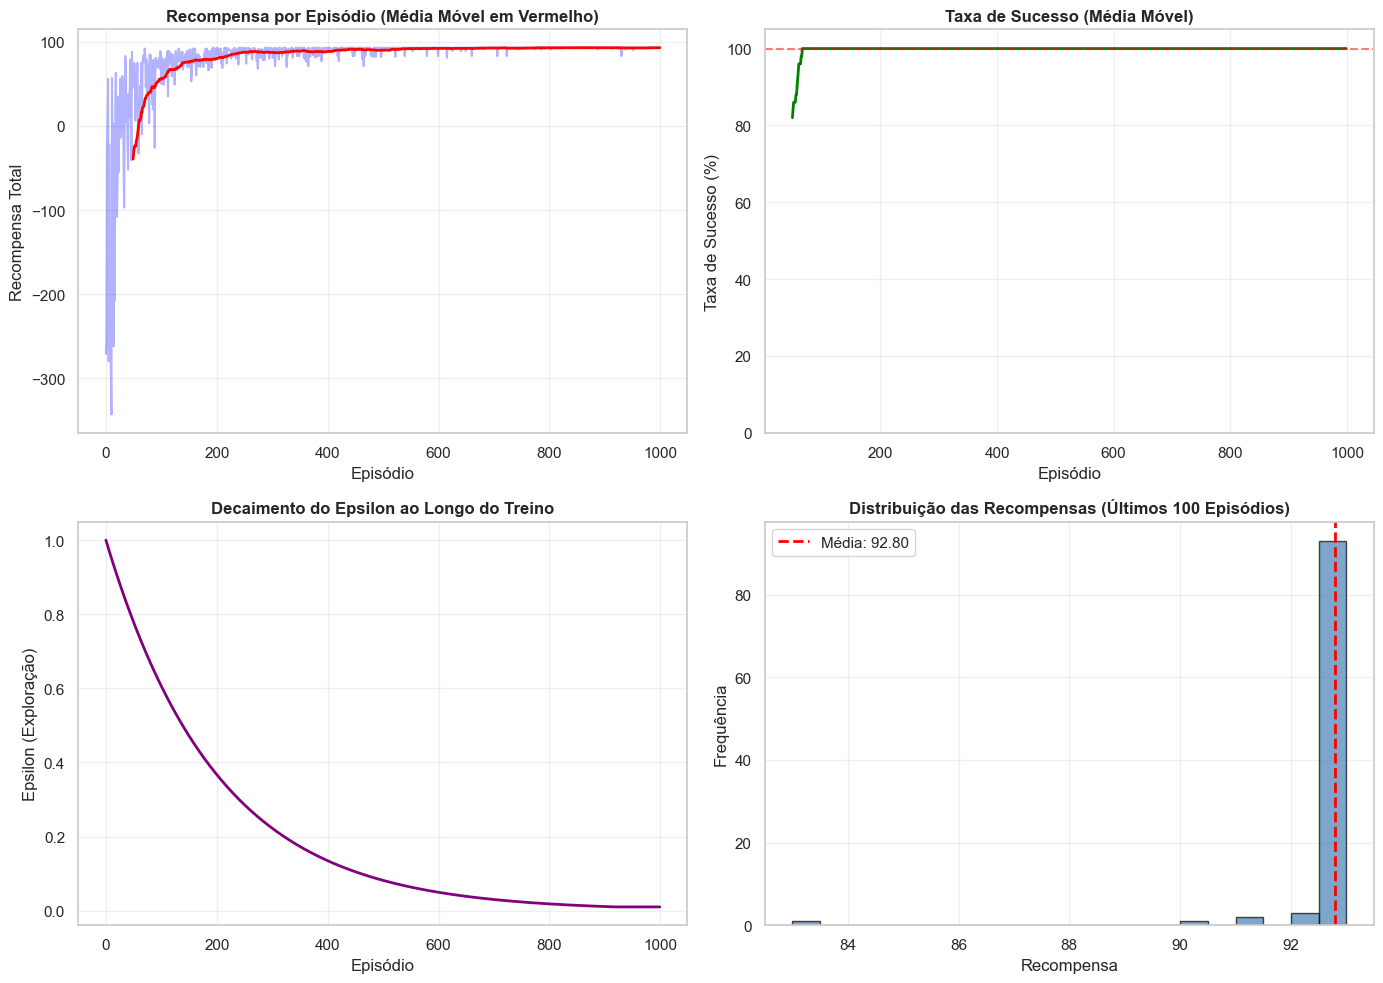

In [205]:
# Visualização do progresso de treino
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Recompensa por Episódio
axes[0, 0].plot(rewards, alpha=0.3, color='blue')
# Média móvel
window = 50
rewards_smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
axes[0, 0].plot(range(window-1, len(rewards)), rewards_smooth, color='red', linewidth=2)
axes[0, 0].set_xlabel('Episódio')
axes[0, 0].set_ylabel('Recompensa Total')
axes[0, 0].set_title('Recompensa por Episódio (Média Móvel em Vermelho)', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Taxa de Sucesso (Média Móvel)
success_smooth = np.convolve(successes, np.ones(window)/window, mode='valid') * 100
axes[0, 1].plot(range(window-1, len(successes)), success_smooth, color='green', linewidth=2)
axes[0, 1].axhline(y=100, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Episódio')
axes[0, 1].set_ylabel('Taxa de Sucesso (%)')
axes[0, 1].set_title('Taxa de Sucesso (Média Móvel)', fontweight='bold')
axes[0, 1].set_ylim(0, 105)
axes[0, 1].grid(alpha=0.3)

# 3. Decaimento do Epsilon
axes[1, 0].plot(epsilons, color='purple', linewidth=2)
axes[1, 0].set_xlabel('Episódio')
axes[1, 0].set_ylabel('Epsilon (Exploração)')
axes[1, 0].set_title('Decaimento do Epsilon ao Longo do Treino', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Distribuição das Recompensas Finais
axes[1, 1].hist(rewards[-100:], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=np.mean(rewards[-100:]), color='red', linestyle='--', 
                   linewidth=2, label=f'Média: {np.mean(rewards[-100:]):.2f}')
axes[1, 1].set_xlabel('Recompensa')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição das Recompensas (Últimos 100 Episódios)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### RL.5 Visualizacao da Q-Table e Politica Aprendida


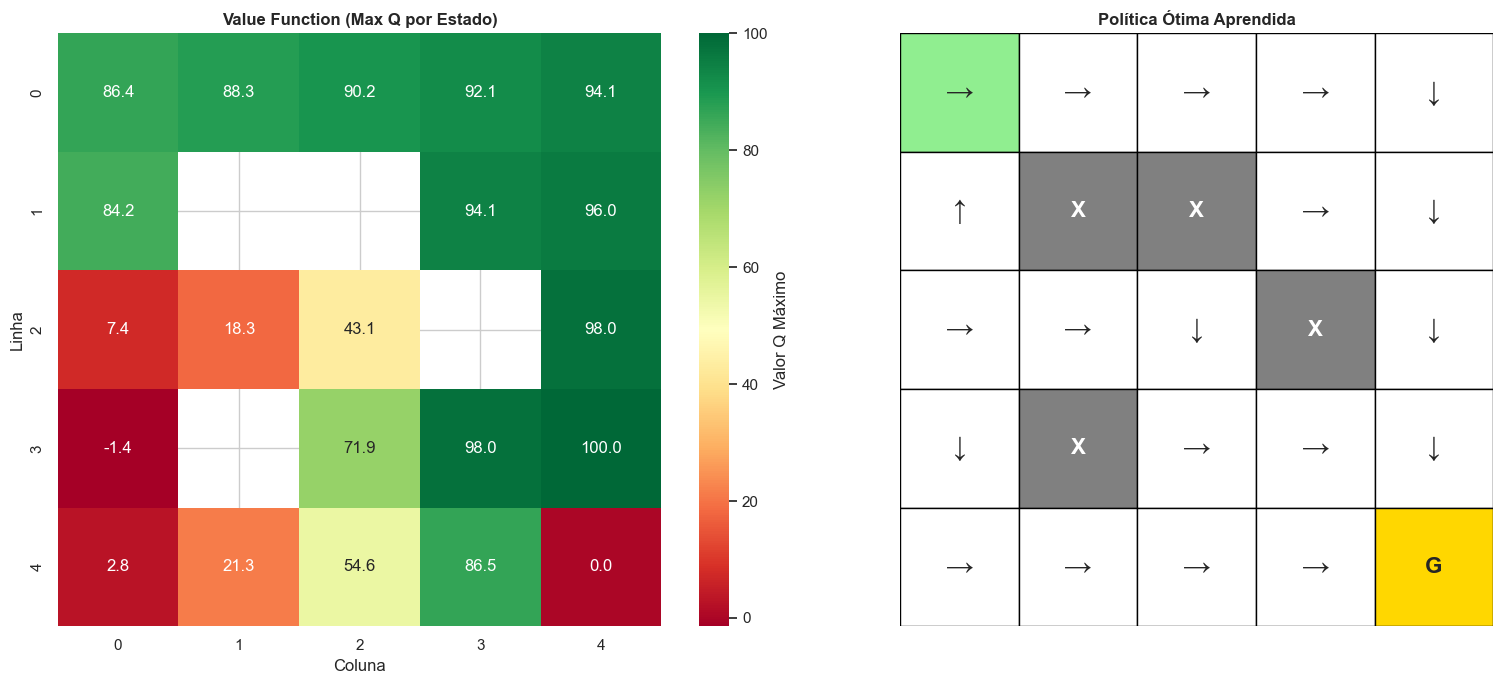


Q-values para o estado inicial (0, 0):
  ↑ Cima: 83.80
  ↓ Baixo: 80.73
  ← Esquerda: 84.13
  → Direita: 86.41


In [206]:
# Visualizar Q-Table e Política Aprendida
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Heatmap do Valor Máximo Q por Estado (Value Function)
value_grid = np.zeros((env.size, env.size))
for i in range(env.size):
    for j in range(env.size):
        if (i, j) in env.obstacles:
            value_grid[i, j] = np.nan
        else:
            value_grid[i, j] = np.max(agent.q_table[(i, j)])

sns.heatmap(value_grid, annot=True, fmt='.1f', cmap='RdYlGn', 
            ax=axes[0], cbar_kws={'label': 'Valor Q Máximo'})
axes[0].set_title('Value Function (Max Q por Estado)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coluna')
axes[0].set_ylabel('Linha')

# 2. Política Aprendida (setas indicando melhor ação)
policy = agent.get_policy()
arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}

# Criar grid para política
axes[1].set_xlim(0, env.size)
axes[1].set_ylim(0, env.size)

for i in range(env.size):
    for j in range(env.size):
        if (i, j) == env.goal:
            axes[1].add_patch(plt.Rectangle((j, env.size-1-i), 1, 1, 
                                           facecolor='gold', edgecolor='black'))
            axes[1].text(j + 0.5, env.size - 0.5 - i, 'G', 
                        ha='center', va='center', fontsize=16, fontweight='bold')
        elif (i, j) in env.obstacles:
            axes[1].add_patch(plt.Rectangle((j, env.size-1-i), 1, 1, 
                                           facecolor='gray', edgecolor='black'))
            axes[1].text(j + 0.5, env.size - 0.5 - i, 'X', 
                        ha='center', va='center', fontsize=16, fontweight='bold', color='white')
        elif (i, j) == env.start:
            axes[1].add_patch(plt.Rectangle((j, env.size-1-i), 1, 1, 
                                           facecolor='lightgreen', edgecolor='black'))
            axes[1].text(j + 0.5, env.size - 0.5 - i, arrows[policy[(i, j)]], 
                        ha='center', va='center', fontsize=20, fontweight='bold')
        else:
            axes[1].add_patch(plt.Rectangle((j, env.size-1-i), 1, 1, 
                                           facecolor='white', edgecolor='black'))
            axes[1].text(j + 0.5, env.size - 0.5 - i, arrows[policy[(i, j)]], 
                        ha='center', va='center', fontsize=20)

axes[1].set_aspect('equal')
axes[1].axis('off')
axes[1].set_title('Política Ótima Aprendida', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Imprimir Q-values para estado inicial
print("\nQ-values para o estado inicial (0, 0):")
for i, action_name in enumerate(env.action_names):
    print(f"  {action_name}: {agent.q_table[(0, 0)][i]:.2f}")


### RL.6 Demonstracao do Agente Treinado

Executamos o agente treinado (sem exploracao) para ver o caminho que aprendeu.


DEMONSTRAÇÃO DO AGENTE TREINADO
Estado Inicial: (0, 0)

Passo 1: Estado (0, 0) → Ação → Direita → Estado (0, 1) (R=-1)
Passo 2: Estado (0, 1) → Ação → Direita → Estado (0, 2) (R=-1)
Passo 3: Estado (0, 2) → Ação → Direita → Estado (0, 3) (R=-1)
Passo 4: Estado (0, 3) → Ação → Direita → Estado (0, 4) (R=-1)
Passo 5: Estado (0, 4) → Ação ↓ Baixo → Estado (1, 4) (R=-1)
Passo 6: Estado (1, 4) → Ação ↓ Baixo → Estado (2, 4) (R=-1)
Passo 7: Estado (2, 4) → Ação ↓ Baixo → Estado (3, 4) (R=-1)
Passo 8: Estado (3, 4) → Ação ↓ Baixo → Estado (4, 4) (R=100)

✓ OBJETIVO ATINGIDO em 8 passos!

Recompensa Total: 93


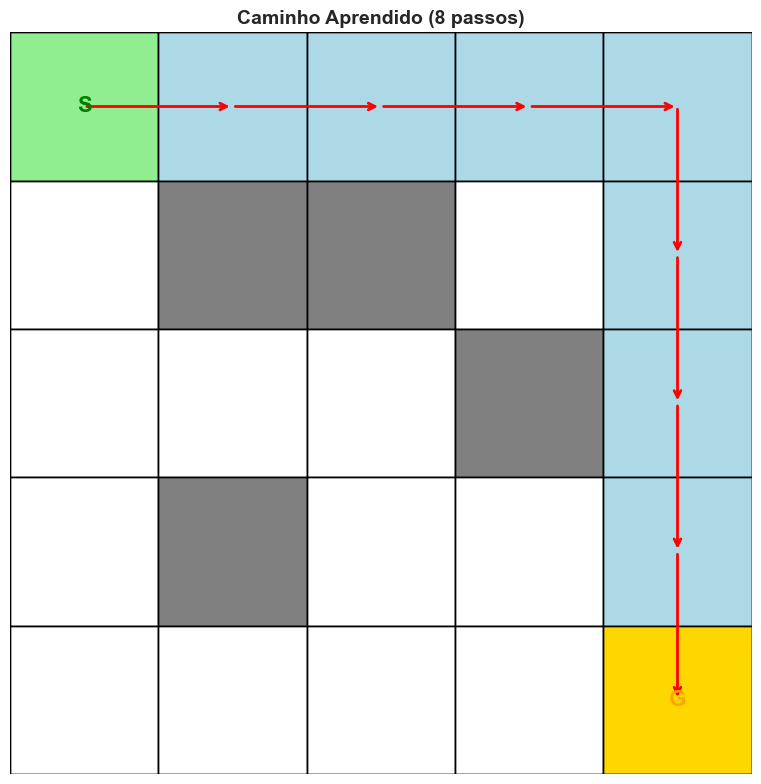

In [207]:
def demonstrate_agent(agent, env, max_steps=50):
    """
    Demonstrar o agente treinado executando a política greedy.
    """
    state = env.reset()
    path = [state]
    total_reward = 0
    
    print("=" * 60)
    print("DEMONSTRAÇÃO DO AGENTE TREINADO")
    print("=" * 60)
    print(f"Estado Inicial: {state}")
    print()
    
    for step in range(max_steps):
        action = agent.choose_action(state, training=False)  # Greedy
        next_state, reward, done = env.step(action)
        
        print(f"Passo {step+1}: Estado {state} → Ação {env.action_names[action]} → Estado {next_state} (R={reward})")
        
        path.append(next_state)
        total_reward += reward
        state = next_state
        
        if done:
            print()
            print(f"✓ OBJETIVO ATINGIDO em {step+1} passos!")
            break
    else:
        print()
        print("✗ Máximo de passos atingido sem chegar ao objetivo")
    
    print(f"\nRecompensa Total: {total_reward}")
    
    return path, total_reward

# Demonstrar agente
path, total_reward = demonstrate_agent(agent, env)

# Visualizar caminho
fig, ax = plt.subplots(figsize=(8, 8))

# Criar grelha
for i in range(env.size + 1):
    ax.axhline(y=i, color='black', linewidth=1)
    ax.axvline(x=i, color='black', linewidth=1)

# Colorir células
for i in range(env.size):
    for j in range(env.size):
        if (i, j) == env.start:
            color = 'lightgreen'
        elif (i, j) == env.goal:
            color = 'gold'
        elif (i, j) in env.obstacles:
            color = 'gray'
        elif (i, j) in path:
            color = 'lightblue'
        else:
            color = 'white'
        
        ax.add_patch(plt.Rectangle((j, env.size - 1 - i), 1, 1, 
                                  facecolor=color, edgecolor='black'))

# Desenhar caminho com setas
for i in range(len(path) - 1):
    curr = path[i]
    next_pos = path[i + 1]
    
    ax.annotate('', 
                xy=(next_pos[1] + 0.5, env.size - 0.5 - next_pos[0]),
                xytext=(curr[1] + 0.5, env.size - 0.5 - curr[0]),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Marcar início e fim
ax.text(env.start[1] + 0.5, env.size - 0.5 - env.start[0], 'S', 
       ha='center', va='center', fontsize=16, fontweight='bold', color='green')
ax.text(env.goal[1] + 0.5, env.size - 0.5 - env.goal[0], 'G', 
       ha='center', va='center', fontsize=16, fontweight='bold', color='orange')

ax.set_xlim(0, env.size)
ax.set_ylim(0, env.size)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Caminho Aprendido ({len(path)-1} passos)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### RL.7 Comparacao de Hiperparametros

Analisamos como diferentes valores de alpha (learning rate) e gamma (discount factor) afetam a aprendizagem.


In [208]:
# Comparação de hiperparâmetros
def run_experiment(env, alpha, gamma, n_episodes=500, n_runs=3):
    """Executar múltiplas runs e calcular métricas médias."""
    all_rewards = []
    all_successes = []
    
    for _ in range(n_runs):
        agent = QLearningAgent(env, alpha=alpha, gamma=gamma)
        rewards, successes, _ = train_agent(agent, env, n_episodes=n_episodes, verbose=False)
        all_rewards.append(np.mean(rewards[-100:]))
        all_successes.append(np.mean(successes[-100:]) * 100)
    
    return np.mean(all_rewards), np.mean(all_successes)

# Testar diferentes combinações
alphas = [0.05, 0.1, 0.3, 0.5]
gammas = [0.9, 0.95, 0.99]

print("=" * 60)
print("COMPARAÇÃO DE HIPERPARÂMETROS")
print("=" * 60)
print("(Executando experimentos... pode demorar um pouco)")
print()

results_hp = []
for alpha in alphas:
    for gamma in gammas:
        avg_reward, success_rate = run_experiment(env, alpha, gamma)
        results_hp.append({
            'Alpha': alpha,
            'Gamma': gamma,
            'Recompensa Média': avg_reward,
            'Taxa Sucesso (%)': success_rate
        })
        print(f"α={alpha}, γ={gamma} → Recompensa: {avg_reward:.2f}, Sucesso: {success_rate:.1f}%")

results_hp_df = pd.DataFrame(results_hp)
print()
print("Resumo:")
display(results_hp_df)


COMPARAÇÃO DE HIPERPARÂMETROS
(Executando experimentos... pode demorar um pouco)

α=0.05, γ=0.9 → Recompensa: 90.37, Sucesso: 100.0%
α=0.05, γ=0.95 → Recompensa: 90.60, Sucesso: 100.0%
α=0.05, γ=0.99 → Recompensa: 90.91, Sucesso: 100.0%
α=0.1, γ=0.9 → Recompensa: 90.50, Sucesso: 100.0%
α=0.1, γ=0.95 → Recompensa: 90.72, Sucesso: 100.0%
α=0.1, γ=0.99 → Recompensa: 90.66, Sucesso: 100.0%
α=0.3, γ=0.9 → Recompensa: 90.86, Sucesso: 100.0%
α=0.3, γ=0.95 → Recompensa: 90.90, Sucesso: 100.0%
α=0.3, γ=0.99 → Recompensa: 91.34, Sucesso: 100.0%
α=0.5, γ=0.9 → Recompensa: 91.13, Sucesso: 100.0%
α=0.5, γ=0.95 → Recompensa: 90.73, Sucesso: 100.0%
α=0.5, γ=0.99 → Recompensa: 90.58, Sucesso: 100.0%

Resumo:


,Alpha,Gamma,Recompensa Média,Taxa Sucesso (%)
0,0.05,0.90,90.373333,100.0
1,0.05,0.95,90.603333,100.0
2,0.05,0.99,90.913333,100.0
3,0.10,0.90,90.496667,100.0
4,0.10,0.95,90.716667,100.0
5,0.10,0.99,90.663333,100.0
6,0.30,0.90,90.856667,100.0
7,0.30,0.95,90.903333,100.0
8,0.30,0.99,91.340000,100.0
9,0.50,0.90,91.126667,100.0


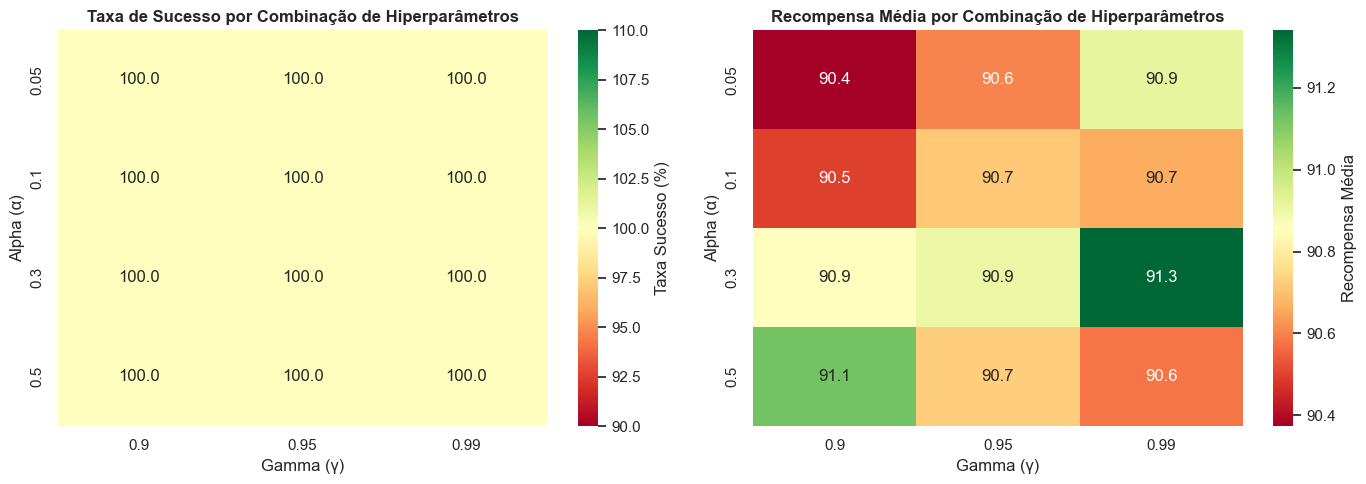


Melhor combinação encontrada:
  Alpha = 0.05, Gamma = 0.9
  Taxa de Sucesso: 100.0%


In [209]:
# Visualização: Heatmap de Taxa de Sucesso por Hiperparâmetros
pivot_success = results_hp_df.pivot(index='Alpha', columns='Gamma', values='Taxa Sucesso (%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap Taxa de Sucesso
sns.heatmap(pivot_success, annot=True, fmt='.1f', cmap='RdYlGn', 
            ax=axes[0], cbar_kws={'label': 'Taxa Sucesso (%)'})
axes[0].set_title('Taxa de Sucesso por Combinação de Hiperparâmetros', fontweight='bold')
axes[0].set_xlabel('Gamma (γ)')
axes[0].set_ylabel('Alpha (α)')

# Heatmap Recompensa
pivot_reward = results_hp_df.pivot(index='Alpha', columns='Gamma', values='Recompensa Média')
sns.heatmap(pivot_reward, annot=True, fmt='.1f', cmap='RdYlGn', 
            ax=axes[1], cbar_kws={'label': 'Recompensa Média'})
axes[1].set_title('Recompensa Média por Combinação de Hiperparâmetros', fontweight='bold')
axes[1].set_xlabel('Gamma (γ)')
axes[1].set_ylabel('Alpha (α)')

plt.tight_layout()
plt.show()

# Melhor combinação
best_idx = results_hp_df['Taxa Sucesso (%)'].idxmax()
best = results_hp_df.iloc[best_idx]
print(f"\nMelhor combinação encontrada:")
print(f"  Alpha = {best['Alpha']}, Gamma = {best['Gamma']}")
print(f"  Taxa de Sucesso: {best['Taxa Sucesso (%)']:.1f}%")


## RL.8 Conclusoes — Reinforcement Learning

### O que Aprendemos

#### Conceitos Fundamentais
1. **Agente-Ambiente**: O RL modela a interação entre um agente decisor e um ambiente
2. **Recompensas**: O agente aprende através de feedback numérico (recompensas)
3. **Política**: A estratégia que mapeia estados a ações

#### Q-Learning
1. **Tabela Q**: Armazena valores esperados para cada par (estado, ação)
2. **ε-greedy**: Balanceia exploração de novas ações vs exploração do conhecimento
3. **Convergência**: Com suficientes episódios, Q-Learning converge para política ótima

### Análise dos Resultados

#### Progresso de Treino
- **Fase Inicial**: Alta exploração (ε alto) resulta em recompensas baixas e variáveis
- **Fase Intermédia**: O agente começa a aprender e recompensas melhoram
- **Fase Final**: Política estabiliza com alta taxa de sucesso

#### Impacto dos Hiperparâmetros

| Parâmetro | Valor Baixo | Valor Alto |
|-----------|-------------|------------|
| **Alpha (α)** | Aprendizagem lenta, mais estável | Aprendizagem rápida, pode oscilar |
| **Gamma (γ)** | Foco em recompensas imediatas | Considera recompensas futuras |
| **Epsilon (ε)** | Mais exploração do conhecimento | Mais exploração aleatória |

### Aplicações Práticas de RL

1. **Jogos**: AlphaGo, Atari games
2. **Robótica**: Controlo de movimento, manipulação
3. **Finanças**: Trading algorítmico
4. **Recomendação**: Personalização dinâmica
5. **Otimização**: Gestão de recursos, logística

### Limitações da Abordagem Tabular

| Limitação | Descrição | Solução |
|-----------|-----------|---------|
| Espaço de estados grande | Q-table cresce exponencialmente | Deep RL (DQN) |
| Estados contínuos | Não é possível discretizar bem | Aproximação de funções |
| Exploração ineficiente | Pode demorar muito a encontrar recompensas | Curiosidade intrínseca |

### Extensões Possíveis

- **SARSA**: Alternativa on-policy a Q-Learning
- **Deep Q-Network (DQN)**: Usar redes neuronais para aproximar Q
- **Policy Gradient**: Aprender política diretamente (REINFORCE, A2C, PPO)
- **Model-Based RL**: Aprender modelo do ambiente para planear
